In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# --------------------------------------------------
# 1. Load processed PM data
# --------------------------------------------------
events_data = pd.read_csv("stocks_events_close_only_filtered.csv")
markets_data = pd.read_csv("stocks_markets_close_only_filtered.csv")

print("Loaded PM data:")
print(" events_data :", events_data.shape)
print(" markets_data:", markets_data.shape)

Loaded PM data:
 events_data : (497, 20)
 markets_data: (4409, 18)


In [3]:
# --------------------------------------------------
# 2. Parse PM datetime columns
# --------------------------------------------------
ET_TZ = "America/New_York"

event_utc_cols = ["startDate", "creationDate", "endDate"]
event_et_cols = ["startDate_et", "creationDate_et", "endDate_et"]

market_utc_cols = ["endDate"]
market_et_cols = ["endDate_et"]

def parse_utc_columns(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(
                df[c].astype("string").str.strip(),
                format="mixed",
                errors="coerce",
                utc=True
            )
    return df

def parse_saved_et_columns(df, cols, tz_name=ET_TZ):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(
                df[c].astype("string").str.strip(),
                format="mixed",
                errors="coerce",
                utc=True
            ).dt.tz_convert(tz_name)
    return df

events_data = parse_utc_columns(events_data, event_utc_cols)
events_data = parse_saved_et_columns(events_data, event_et_cols)

markets_data = parse_utc_columns(markets_data, market_utc_cols)
markets_data = parse_saved_et_columns(markets_data, market_et_cols)

In [4]:
# --------------------------------------------------
# 3. Quick PM structure checks
# --------------------------------------------------
print("events_data columns:")
print(events_data.columns.tolist())
print("\nmarkets_data columns:")
print(markets_data.columns.tolist())

events_data columns:
['id', 'ticker', 'slug', 'title', 'description', 'category', 'startDate', 'creationDate', 'endDate', 'resolutionSource', 'closed', 'archived', 'volume', 'volume_num', 'resolved_flag', 'Is_Hit_Market', 'startDate_et', 'creationDate_et', 'endDate_et', 'stock_ticker']

markets_data columns:
['id', 'question', 'category', 'event_id', 'event_slug', 'event_title', 'endDate', 'clobTokenIds', 'clob_token_ids', 'matched_token', 'history_len', 'has_price_history', 'n_tokens', 'ticker', 'lower_bound', 'upper_bound', 'endDate_et', 'interval_type']


In [5]:
events_data.head(3)

,id,ticker,slug,title,description,category,startDate,creationDate,endDate,resolutionSource,closed,archived,volume,volume_num,resolved_flag,Is_Hit_Market,startDate_et,creationDate_et,endDate_et,stock_ticker
0,86643,what-will-amzn-close-at-in-2025,what-will-amzn-close-at-in-2025,What will Amazon (AMZN) close at in 2025?,This market will resolve according to the offi...,Stocks,2025-11-24 22:12:30.742221+00:00,2025-11-24 22:12:30.742214+00:00,2025-12-31 23:59:59+00:00,NaN,True,False,130072.538872,130072.538872,True,False,2025-11-24 17:12:30.742221-05:00,2025-11-24 17:12:30.742214-05:00,2025-12-31 18:59:59-05:00,AMZN
1,86644,what-will-nflx-close-at-in-2025,what-will-nflx-close-at-in-2025,What will Netflix (NFLX) close at in 2025?,This market will resolve according to the offi...,Stocks,2025-11-24 22:00:42.034201+00:00,2025-11-24 22:00:42.034195+00:00,2025-12-31 23:59:59+00:00,NaN,True,False,252989.498871,252989.498871,True,False,2025-11-24 17:00:42.034201-05:00,2025-11-24 17:00:42.034195-05:00,2025-12-31 18:59:59-05:00,NFLX
2,89531,what-will-tesla-tsla-close-at-in-2025,what-will-tesla-tsla-close-at-in-2025,What will Tesla (TSLA) close at in 2025?,This market will resolve according to the offi...,Stocks,2025-11-24 22:12:30.736651+00:00,2025-11-24 22:12:30.736642+00:00,2025-12-31 00:00:00+00:00,NaN,True,False,264942.177680,264942.177680,True,False,2025-11-24 17:12:30.736651-05:00,2025-11-24 17:12:30.736642-05:00,2025-12-30 19:00:00-05:00,TSLA


In [6]:
markets_data.head(3)

,id,question,category,event_id,event_slug,event_title,endDate,clobTokenIds,clob_token_ids,matched_token,history_len,has_price_history,n_tokens,ticker,lower_bound,upper_bound,endDate_et,interval_type
0,694609,Will Amazon (AMZN) close at $210-$215 in 2025?,Stocks,86643,what-will-amzn-close-at-in-2025,What will Amazon (AMZN) close at in 2025?,2025-12-31 23:59:59+00:00,"[""13897074307443593582113795663054415311900728...",['13897074307443593582113795663054415311900728...,1389707430744359358211379566305441531190072831...,39,True,2,AMZN,210.0,215.0,2025-12-31 18:59:59-05:00,"[x, y]"
1,694613,Will Amazon (AMZN) close at $230-$235 in 2025?,Stocks,86643,what-will-amzn-close-at-in-2025,What will Amazon (AMZN) close at in 2025?,2025-12-31 23:59:59+00:00,"[""86018820363216161193523278904638496983411049...",['86018820363216161193523278904638496983411049...,8601882036321616119352327890463849698341104908...,39,True,2,AMZN,230.0,235.0,2025-12-31 18:59:59-05:00,"[x, y]"
2,694615,Will Amazon (AMZN) close at $240-$245 in 2025?,Stocks,86643,what-will-amzn-close-at-in-2025,What will Amazon (AMZN) close at in 2025?,2025-12-31 23:59:59+00:00,"[""41544776201164741532434795627347951575686196...",['41544776201164741532434795627347951575686196...,4154477620116474153243479562734795157568619623...,39,True,2,AMZN,240.0,245.0,2025-12-31 18:59:59-05:00,"[x, y]"


In [7]:
# A few useful PM summaries
print("Number of events :", len(events_data))
print("Number of markets:", len(markets_data))
print("Unique stocks in events :", events_data["stock_ticker"].nunique() if "stock_ticker" in events_data.columns else "N/A")
print("Unique stocks in markets:", markets_data["ticker"].nunique() if "ticker" in markets_data.columns else "N/A")

if "interval_type" in markets_data.columns:
    print("\nInterval type summary:")
    display(
        markets_data["interval_type"]
        .value_counts(dropna=False)
        .rename_axis("interval_type")
        .reset_index(name="n_markets")
    )

Number of events : 497
Number of markets: 4409
Unique stocks in events : 10
Unique stocks in markets: 10

Interval type summary:


,interval_type,n_markets
0,"[x, inf)",3132
1,"[x, y]",1149
2,"[0, x]",128


In [8]:
# --------------------------------------------------
# 4. Load processed options data
# --------------------------------------------------
# Prefer parquet if available; fall back to CSV
try:
    options_data = pd.read_parquet("options_long_all_batches.parquet")
    print("Loaded options from parquet.")
except Exception:
    options_data = pd.read_csv("options_long_all_batches.csv")
    print("Loaded options from csv.")

print("options_data shape:", options_data.shape)

Loaded options from parquet.
options_data shape: (81028, 14)


In [9]:
# --------------------------------------------------
# 5. Parse options datetime columns
# --------------------------------------------------
if "date" in options_data.columns:
    options_data["date"] = pd.to_datetime(options_data["date"], errors="coerce")

if "option_expiry" in options_data.columns:
    options_data["option_expiry"] = pd.to_datetime(options_data["option_expiry"], errors="coerce")

In [10]:
# --------------------------------------------------
# 6. Ensure numeric option fields are numeric
# --------------------------------------------------
numeric_option_cols = [
    "strike", "PX_LAST", "PX_BID", "PX_ASK",
    "PX_MID", "IVOL_MID", "PX_VOLUME", "OPEN_INT"
]

for c in numeric_option_cols:
    if c in options_data.columns:
        options_data[c] = pd.to_numeric(options_data[c], errors="coerce")

# recompute PX_MID if needed
if {"PX_BID", "PX_ASK"}.issubset(options_data.columns):
    options_data["PX_MID"] = (options_data["PX_BID"] + options_data["PX_ASK"]) / 2

In [11]:
# --------------------------------------------------
# 7. Reorder option columns for readability
# --------------------------------------------------
front_cols = [
    "date",
    "option_ticker",
    "stock_ticker",
    "option_expiry",
    "cp",
    "strike",
    "batch_file",
]

data_cols = [
    "PX_LAST",
    "PX_BID",
    "PX_ASK",
    "PX_MID",
    "IVOL_MID",
    "PX_VOLUME",
    "OPEN_INT",
]

front_cols = [c for c in front_cols if c in options_data.columns]
data_cols = [c for c in data_cols if c in options_data.columns]
other_cols = [c for c in options_data.columns if c not in front_cols + data_cols]

options_data = options_data[front_cols + other_cols + data_cols].copy()

In [12]:
# --------------------------------------------------
# 8. Sort options more naturally
# --------------------------------------------------
sort_cols = [c for c in ["stock_ticker", "option_expiry", "strike", "date"] if c in options_data.columns]
options_data = options_data.sort_values(sort_cols).reset_index(drop=True)

print("options_data shape:", options_data.shape)
options_data.head(10)

options_data shape: (81028, 14)


,date,option_ticker,stock_ticker,option_expiry,cp,strike,batch_file,PX_LAST,PX_BID,PX_ASK,PX_MID,IVOL_MID,PX_VOLUME,OPEN_INT
0,2025-12-22,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,26.90,30.15,28.525,52.945,10.0,10.0
1,2025-12-23,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,28.25,31.35,29.800,64.365,10.0,10.0
2,2025-12-24,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
3,2025-12-25,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
4,2025-12-26,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
5,2025-12-29,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
6,2025-12-30,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
7,2025-12-31,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
8,2026-01-01,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
9,2026-01-02,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0


In [13]:
# --------------------------------------------------
# 9. Basic options structure checks
# --------------------------------------------------
print("options_data columns:")
print(options_data.columns.tolist())

print("\nUnique option tickers:", options_data["option_ticker"].nunique() if "option_ticker" in options_data.columns else "N/A")
print("Date range:", options_data["date"].min(), "to", options_data["date"].max() if "date" in options_data.columns else "N/A")

display(options_data.head(5))

options_data columns:
['date', 'option_ticker', 'stock_ticker', 'option_expiry', 'cp', 'strike', 'batch_file', 'PX_LAST', 'PX_BID', 'PX_ASK', 'PX_MID', 'IVOL_MID', 'PX_VOLUME', 'OPEN_INT']

Unique option tickers: 1970
Date range: 2025-12-22 00:00:00 to 2026-04-06 00:00:00


,date,option_ticker,stock_ticker,option_expiry,cp,strike,batch_file,PX_LAST,PX_BID,PX_ASK,PX_MID,IVOL_MID,PX_VOLUME,OPEN_INT
0,2025-12-22,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,26.90,30.15,28.525,52.945,10.0,10.0
1,2025-12-23,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,28.25,31.35,29.800,64.365,10.0,10.0
2,2025-12-24,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
3,2025-12-25,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
4,2025-12-26,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0


In [14]:
# Missingness check on daily option fields
option_value_cols = [c for c in ["PX_LAST", "PX_BID", "PX_ASK", "PX_MID", "IVOL_MID", "PX_VOLUME", "OPEN_INT"] if c in options_data.columns]

if option_value_cols:
    missing_summary = (
        options_data[option_value_cols]
        .isna()
        .mean()
        .rename("missing_share")
        .sort_values()
        .reset_index()
        .rename(columns={"index": "field"})
    )
    display(missing_summary)

,field,missing_share
0,PX_ASK,0.547687
1,IVOL_MID,0.549798
2,PX_BID,0.552044
3,PX_MID,0.552044
4,PX_LAST,0.565595
5,PX_VOLUME,0.565595
6,OPEN_INT,0.567174


In [15]:
stock_data = pd.read_csv("Stock_NOCP.csv")
stock_data["date"] = pd.to_datetime(stock_data["date"], errors="coerce")
stock_data.head()

,date,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,OPEN,PLTR,TSLA
0,2026-04-17,270.23,250.56,341.68,688.55,422.79,97.31,201.68,5.29,146.39,400.62
1,2026-04-16,263.40,249.70,336.02,676.87,420.26,107.79,198.35,5.27,142.76,388.90
2,2026-04-15,266.43,248.50,337.12,671.58,411.22,107.71,198.87,4.82,142.15,391.95
3,2026-04-14,258.83,249.02,332.91,662.49,393.11,106.28,196.51,4.51,135.70,364.20
4,2026-04-13,259.20,239.89,321.31,634.53,384.37,103.16,189.31,4.36,132.37,352.42


## Preliminary cleaning and basic processing

At this stage, we only do light cleaning.

For options:
- drop rows after each option's own expiry date,
- keep rows with non-missing mid price (`PX_MID`),
- keep all other rows for now without imposing liquidity or spread filters.

For stock data:
- reshape the NOCP data from wide to long format,
- convert prices to numeric,
- check date coverage and missingness.

We do not yet apply stricter pricing-sample filters such as:
- zero / low volume,
- low open interest,
- wide bid-ask spread.

Those will be handled later when constructing the baseline pricing sample and robustness samples.

## Build a daily stock-close panel by forward-filling non-trading days

`Stock_NOCP.csv` only contains trading-day official close prices.

However, the merged PM-option panel may contain calendar dates on which the stock market is closed
(for example weekends or holidays). On those dates, there is no new official close, so we use the
most recent previous official close as the stock price input.

We therefore keep:
- `stock_data_long`: the original trading-day NOCP panel,
- `stock_data_daily_ffill`: a daily calendar panel with forward-filled stock close prices.

The merge in the pricing panel will use `stock_data_daily_ffill`.

In [16]:
# --------------------------------------------------
# 1. Basic stock-data cleaning: wide -> long
# --------------------------------------------------
stock_data = stock_data.copy()

stock_data_long = stock_data.melt(
    id_vars="date",
    var_name="stock_ticker",
    value_name="stock_close_nocp"
).copy()

stock_data_long["stock_close_nocp"] = pd.to_numeric(
    stock_data_long["stock_close_nocp"],
    errors="coerce"
)

stock_data_long = stock_data_long.sort_values(
    ["stock_ticker", "date"]
).reset_index(drop=True)

print("stock_data_long shape:", stock_data_long.shape)
display(stock_data_long.head(10))

# --------------------------------------------------
# 1b. Expand to daily calendar and forward-fill within stock
# --------------------------------------------------
calendar_start = stock_data_long["date"].min()
calendar_end = stock_data_long["date"].max()
daily_calendar = pd.date_range(calendar_start, calendar_end, freq="D")

stock_data_daily_ffill = (
    stock_data_long
    .set_index(["stock_ticker", "date"])
    .sort_index()
    .groupby(level=0)
    .apply(
        lambda g: g.droplevel(0).reindex(daily_calendar)
    )
    .reset_index()
    .rename(columns={"level_1": "date"})
)

# restore stock ticker after groupby-apply
stock_data_daily_ffill = stock_data_daily_ffill.rename(columns={"stock_ticker": "stock_ticker"})

# mark whether the date was an original stock-trading-day observation
orig_keys = stock_data_long[["stock_ticker", "date"]].copy()
orig_keys["is_stock_trading_day"] = True

stock_data_daily_ffill = stock_data_daily_ffill.merge(
    orig_keys,
    on=["stock_ticker", "date"],
    how="left"
)

stock_data_daily_ffill["is_stock_trading_day"] = (
    stock_data_daily_ffill["is_stock_trading_day"]
    .fillna(False)
    .astype(bool)
)

# forward-fill NOCP within each stock
stock_data_daily_ffill["stock_close_nocp"] = (
    stock_data_daily_ffill
    .sort_values(["stock_ticker", "date"])
    .groupby("stock_ticker")["stock_close_nocp"]
    .ffill()
)

# flag rows whose stock close is carried forward from a prior trading day
stock_data_daily_ffill["stock_close_ffilled"] = (
    ~stock_data_daily_ffill["is_stock_trading_day"]
) & stock_data_daily_ffill["stock_close_nocp"].notna()

stock_data_daily_ffill = stock_data_daily_ffill.sort_values(
    ["stock_ticker", "date"]
).reset_index(drop=True)

print("stock_data_daily_ffill shape:", stock_data_daily_ffill.shape)
display(stock_data_daily_ffill.head(15))

stock_data_long shape: (1000, 3)


,date,stock_ticker,stock_close_nocp
0,2025-11-21,AAPL,271.49
1,2025-11-24,AAPL,275.92
2,2025-11-25,AAPL,276.97
3,2025-11-26,AAPL,277.55
4,2025-11-28,AAPL,278.85
5,2025-12-01,AAPL,283.10
6,2025-12-02,AAPL,286.19
7,2025-12-03,AAPL,284.15
8,2025-12-04,AAPL,280.70
9,2025-12-05,AAPL,278.78


stock_data_daily_ffill shape: (1480, 5)


/var/folders/6d/4cbpc7vx1f5d6762pmx36swm0000gn/T/ipykernel_35625/2719312668.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,stock_ticker,date,stock_close_nocp,is_stock_trading_day,stock_close_ffilled
0,AAPL,2025-11-21,271.49,True,False
1,AAPL,2025-11-22,271.49,False,True
2,AAPL,2025-11-23,271.49,False,True
3,AAPL,2025-11-24,275.92,True,False
4,AAPL,2025-11-25,276.97,True,False
5,AAPL,2025-11-26,277.55,True,False
6,AAPL,2025-11-27,277.55,False,True
7,AAPL,2025-11-28,278.85,True,False
8,AAPL,2025-11-29,278.85,False,True
9,AAPL,2025-11-30,278.85,False,True


In [17]:
# --------------------------------------------------
# 2. Preliminary option-data cleaning
# --------------------------------------------------
options_data = options_data.copy()

# Drop rows after the option's own expiry
options_data = options_data.loc[
    options_data["date"] <= options_data["option_expiry"]
].copy()

# Keep only rows with usable mid price for now
options_data = options_data.loc[
    options_data["PX_MID"].notna()
].copy()

# Sort again after filtering
options_data = options_data.sort_values(
    ["stock_ticker", "option_expiry", "strike", "date"]
).reset_index(drop=True)

print("options_data shape after preliminary cleaning:", options_data.shape)
options_data.head(10)

options_data shape after preliminary cleaning: (25662, 14)


,date,option_ticker,stock_ticker,option_expiry,cp,strike,batch_file,PX_LAST,PX_BID,PX_ASK,PX_MID,IVOL_MID,PX_VOLUME,OPEN_INT
0,2025-12-22,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,26.90,30.15,28.525,52.945,10.0,10.0
1,2025-12-23,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,28.25,31.35,29.800,64.365,10.0,10.0
2,2025-12-24,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
3,2025-12-25,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
4,2025-12-26,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0
5,2025-12-22,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.00,22.15,23.95,23.050,45.889,16.0,15.0
6,2025-12-23,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.00,23.25,26.40,24.825,61.558,16.0,15.0
7,2025-12-24,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.00,25.15,27.60,26.375,61.558,16.0,15.0
8,2025-12-25,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.00,25.15,27.60,26.375,61.558,16.0,15.0
9,2025-12-26,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,25.75,24.45,27.15,25.800,61.558,14.0,15.0


In [18]:
# --------------------------------------------------
# 3. Quick summaries: PM data
# --------------------------------------------------
print("PM data summary")
print(" events_data shape :", events_data.shape)
print(" markets_data shape:", markets_data.shape)
print(" unique stocks in events :", events_data["stock_ticker"].nunique())
print(" unique stocks in markets:", markets_data["ticker"].nunique())

if "interval_type" in markets_data.columns:
    interval_summary = (
        markets_data["interval_type"]
        .value_counts(dropna=False)
        .rename_axis("interval_type")
        .reset_index(name="n_markets")
    )
    display(interval_summary)

PM data summary
 events_data shape : (497, 20)
 markets_data shape: (4409, 18)
 unique stocks in events : 10
 unique stocks in markets: 10


,interval_type,n_markets
0,"[x, inf)",3132
1,"[x, y]",1149
2,"[0, x]",128


In [19]:
# --------------------------------------------------
# 4. Quick summaries: cleaned options data
# --------------------------------------------------
print("Options data summary after preliminary cleaning")
print(" rows                :", len(options_data))
print(" unique option_ticker:", options_data["option_ticker"].nunique())
print(" unique stocks       :", options_data["stock_ticker"].nunique())
print(" date range          :", options_data["date"].min(), "to", options_data["date"].max())
print(" expiry range        :", options_data["option_expiry"].min(), "to", options_data["option_expiry"].max())

display(options_data.head(5))

Options data summary after preliminary cleaning
 rows                : 25662
 unique option_ticker: 1956
 unique stocks       : 10
 date range          : 2025-12-22 00:00:00 to 2026-04-06 00:00:00
 expiry range        : 2025-12-26 00:00:00 to 2026-04-06 00:00:00


,date,option_ticker,stock_ticker,option_expiry,cp,strike,batch_file,PX_LAST,PX_BID,PX_ASK,PX_MID,IVOL_MID,PX_VOLUME,OPEN_INT
0,2025-12-22,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,26.90,30.15,28.525,52.945,10.0,10.0
1,2025-12-23,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,28.25,31.35,29.800,64.365,10.0,10.0
2,2025-12-24,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
3,2025-12-25,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,26.66,30.00,32.60,31.300,64.365,10.0,10.0
4,2025-12-26,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,selected_options_batch_1a_to_2026_01_16(1).xlsx,33.40,29.45,32.60,31.025,1481.910,12.0,10.0


In [20]:
# --------------------------------------------------
# 5. Quick summaries: stock data
# --------------------------------------------------
print("Stock NOCP summary")
print(" stock_data_long shape        :", stock_data_long.shape)
print(" stock_data_daily_ffill shape :", stock_data_daily_ffill.shape)
print(" unique stocks               :", stock_data_long["stock_ticker"].nunique())
print(" trading-day date range      :", stock_data_long["date"].min(), "to", stock_data_long["date"].max())
print(" daily-calendar date range   :", stock_data_daily_ffill["date"].min(), "to", stock_data_daily_ffill["date"].max())

display(stock_data_long.head(10))
display(stock_data_daily_ffill.head(10))

Stock NOCP summary
 stock_data_long shape        : (1000, 3)
 stock_data_daily_ffill shape : (1480, 5)
 unique stocks               : 10
 trading-day date range      : 2025-11-21 00:00:00 to 2026-04-17 00:00:00
 daily-calendar date range   : 2025-11-21 00:00:00 to 2026-04-17 00:00:00


,date,stock_ticker,stock_close_nocp
0,2025-11-21,AAPL,271.49
1,2025-11-24,AAPL,275.92
2,2025-11-25,AAPL,276.97
3,2025-11-26,AAPL,277.55
4,2025-11-28,AAPL,278.85
5,2025-12-01,AAPL,283.10
6,2025-12-02,AAPL,286.19
7,2025-12-03,AAPL,284.15
8,2025-12-04,AAPL,280.70
9,2025-12-05,AAPL,278.78


,stock_ticker,date,stock_close_nocp,is_stock_trading_day,stock_close_ffilled
0,AAPL,2025-11-21,271.49,True,False
1,AAPL,2025-11-22,271.49,False,True
2,AAPL,2025-11-23,271.49,False,True
3,AAPL,2025-11-24,275.92,True,False
4,AAPL,2025-11-25,276.97,True,False
5,AAPL,2025-11-26,277.55,True,False
6,AAPL,2025-11-27,277.55,False,True
7,AAPL,2025-11-28,278.85,True,False
8,AAPL,2025-11-29,278.85,False,True
9,AAPL,2025-11-30,278.85,False,True


In [21]:
# --------------------------------------------------
# 6. Coverage summary by option ticker
# --------------------------------------------------
option_coverage = (
    options_data.groupby("option_ticker")
    .agg(
        stock_ticker=("stock_ticker", "first"),
        option_expiry=("option_expiry", "first"),
        cp=("cp", "first"),
        strike=("strike", "first"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_rows=("date", "size"),
        n_mid=("PX_MID", lambda s: s.notna().sum()),
        n_bid=("PX_BID", lambda s: s.notna().sum()),
        n_ask=("PX_ASK", lambda s: s.notna().sum()),
        n_last=("PX_LAST", lambda s: s.notna().sum()),
        n_volume=("PX_VOLUME", lambda s: s.notna().sum()),
        n_open_int=("OPEN_INT", lambda s: s.notna().sum()),
    )
    .reset_index()
    .sort_values(["stock_ticker", "option_expiry", "strike"])
    .reset_index(drop=True)
)

print("option_coverage shape:", option_coverage.shape)
option_coverage.head(10)

option_coverage shape: (1956, 14)


,option_ticker,stock_ticker,option_expiry,cp,strike,first_date,last_date,n_rows,n_mid,n_bid,n_ask,n_last,n_volume,n_open_int
0,AAPL US 12/26/25 C242.5 Equity,AAPL,2025-12-26,C,242.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
1,AAPL US 12/26/25 C247.5 Equity,AAPL,2025-12-26,C,247.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
2,AAPL US 12/26/25 C252.5 Equity,AAPL,2025-12-26,C,252.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
3,AAPL US 12/26/25 C257.5 Equity,AAPL,2025-12-26,C,257.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
4,AAPL US 12/26/25 C262.5 Equity,AAPL,2025-12-26,C,262.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
5,AAPL US 12/26/25 C267.5 Equity,AAPL,2025-12-26,C,267.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
6,AAPL US 12/26/25 C272.5 Equity,AAPL,2025-12-26,C,272.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
7,AAPL US 12/26/25 C277.5 Equity,AAPL,2025-12-26,C,277.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
8,AAPL US 12/26/25 C282.5 Equity,AAPL,2025-12-26,C,282.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5
9,AAPL US 12/26/25 C287.5 Equity,AAPL,2025-12-26,C,287.5,2025-12-22,2025-12-26,5,5,5,5,5,5,5


In [22]:
# --------------------------------------------------
# 8. Stock-data coverage summary
# --------------------------------------------------
stock_summary = (
    stock_data_long.groupby("stock_ticker")
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_rows=("date", "size"),
        n_nonmissing_close=("stock_close_nocp", lambda s: s.notna().sum()),
    )
    .reset_index()
    .sort_values("stock_ticker")
    .reset_index(drop=True)
)

stock_summary

,stock_ticker,first_date,last_date,n_rows,n_nonmissing_close
0,AAPL,2025-11-21,2026-04-17,100,100
1,AMZN,2025-11-21,2026-04-17,100,100
2,GOOGL,2025-11-21,2026-04-17,100,100
3,META,2025-11-21,2026-04-17,100,100
4,MSFT,2025-11-21,2026-04-17,100,100
5,NFLX,2025-11-21,2026-04-17,100,100
6,NVDA,2025-11-21,2026-04-17,100,100
7,OPEN,2025-11-21,2026-04-17,100,100
8,PLTR,2025-11-21,2026-04-17,100,100
9,TSLA,2025-11-21,2026-04-17,100,100


## Notes on the preliminary-cleaned data

At this point:

- `options_data` is the option panel after only very light cleaning,
- `stock_data_long` is the daily stock NOCP panel in long format,
- no liquidity or bid-ask-spread filters have been applied yet.

Later, when constructing the baseline pricing sample, we will likely impose stricter filters such as:
- requiring both bracketing options to be available,
- requiring positive or sufficiently large volume / open interest,
- requiring bid-ask spreads to be reasonably small.

We may also build multiple pricing methods:
1. strict baseline using mid price,
2. bid-ask range pricing using a looser sample,
3. IV-based robustness pricing.

## Construct pricing-ready daily PM market panel

Goal:
build a daily panel at the PM market level.

For each PM market, we:
1. keep only events with exact option-expiry match,
2. identify the relevant PM boundary or boundaries,
3. match each boundary to the nearest lower and upper option strikes,
4. require both lower and upper option strikes to exist and satisfy the same gap rule used earlier,
5. merge daily PM market observations, daily option observations, and daily stock NOCP.

At this stage, we only require:
- exact expiry match,
- valid lower and upper bracketing options,
- non-missing option mid prices,
- overlapping daily observations.

We do not yet impose stricter liquidity or spread filters.

In [23]:
# --------------------------------------------------
# 1. Exact-expiry event sample
# --------------------------------------------------
# We reconstruct the event-expiry match using the same logic as before,
# but now only keep exact matches for the baseline pricing panel.

available_expiries = (
    options_data[["stock_ticker", "option_expiry"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["stock_ticker", "option_expiry"])
    .reset_index(drop=True)
)

event_expiry_match = events_data[[
    "id", "slug", "title", "stock_ticker", "endDate_et"
]].copy()

event_expiry_match = event_expiry_match.rename(columns={"id": "event_id"})
event_expiry_match["pm_enddate"] = pd.to_datetime(event_expiry_match["endDate_et"]).dt.date

def find_closest_expiry(stock, pm_enddate, available_df):
    stock_exp = available_df.loc[
        available_df["stock_ticker"] == stock, "option_expiry"
    ].dropna().tolist()

    if len(stock_exp) == 0:
        return pd.Series({
            "matched_option_expiry": pd.NaT,
            "mismatch_days": np.nan,
            "abs_mismatch_days": np.nan
        })

    pm_ts = pd.Timestamp(pm_enddate)
    exp_ts = pd.to_datetime(stock_exp)

    diff_days = (exp_ts - pm_ts).days
    abs_diff_days = np.abs(diff_days)

    # same tie-break as before:
    # first minimize absolute mismatch
    # if tied, prefer earlier expiry
    best_idx = np.lexsort((diff_days, abs_diff_days))[0]

    best_expiry = exp_ts[best_idx].date()
    best_mismatch = int(diff_days[best_idx])

    return pd.Series({
        "matched_option_expiry": best_expiry,
        "mismatch_days": best_mismatch,
        "abs_mismatch_days": abs(best_mismatch)
    })

event_expiry_match[[
    "matched_option_expiry",
    "mismatch_days",
    "abs_mismatch_days"
]] = event_expiry_match.apply(
    lambda row: find_closest_expiry(
        row["stock_ticker"],
        row["pm_enddate"],
        available_expiries
    ),
    axis=1
)

events_exact = event_expiry_match.loc[
    event_expiry_match["mismatch_days"] == 0
].copy()

exact_event_ids = set(events_exact["event_id"])

print("Exact-match events:", len(events_exact))
events_exact.head()

Exact-match events: 348


,event_id,slug,title,stock_ticker,endDate_et,pm_enddate,matched_option_expiry,mismatch_days,abs_mismatch_days
17,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,2025-12-26 16:00:00-05:00,2025-12-26,2025-12-26,0,0
18,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,AAPL,2025-12-26 16:00:00-05:00,2025-12-26,2025-12-26,0,0
19,112373,msft-week-december-26-2025,Microsoft (MSFT) closes week of Dec 22 at ___?,MSFT,2025-12-26 16:00:00-05:00,2025-12-26,2025-12-26,0,0
20,112374,msft-above-on-december-26-2025,Will Microsoft (MSFT) finish week of December ...,MSFT,2025-12-26 16:00:00-05:00,2025-12-26,2025-12-26,0,0
21,112378,amzn-above-on-december-26-2025,Will Amazon (AMZN) finish week of December 22 ...,AMZN,2025-12-26 16:00:00-05:00,2025-12-26,2025-12-26,0,0


In [24]:
# --------------------------------------------------
# 2. Exact-match PM markets
# --------------------------------------------------
markets_exact = markets_data.loc[
    markets_data["event_id"].isin(exact_event_ids)
].copy()

# keep relevant columns and standardize names
pm_markets_static = markets_exact[[
    "id", "event_id", "event_slug", "event_title",
    "ticker", "interval_type", "lower_bound", "upper_bound"
]].copy()

pm_markets_static = pm_markets_static.rename(columns={
    "id": "pm_market_id",
    "ticker": "stock_ticker"
})

# attach event-level timing / expiry info
pm_markets_static = pm_markets_static.merge(
    events_exact[[
        "event_id", "slug", "title", "stock_ticker",
        "pm_enddate", "matched_option_expiry"
    ]],
    on=["event_id", "stock_ticker"],
    how="left",
    suffixes=("", "_event")
)

pm_markets_static["lower_bound"] = pd.to_numeric(pm_markets_static["lower_bound"], errors="coerce")
pm_markets_static["upper_bound"] = pd.to_numeric(pm_markets_static["upper_bound"], errors="coerce")

print("Exact-match PM markets:", len(pm_markets_static))
pm_markets_static.head()

Exact-match PM markets: 3311


,pm_market_id,event_id,event_slug,event_title,stock_ticker,interval_type,lower_bound,upper_bound,slug,title,pm_enddate,matched_option_expiry
0,974363,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",240.0,inf,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,2025-12-26
1,974364,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",245.0,inf,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,2025-12-26
2,974365,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",250.0,inf,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,2025-12-26
3,974366,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",255.0,inf,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,2025-12-26
4,974367,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",260.0,inf,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,2025-12-26


## Build PM-boundary-to-option bracket map

For each PM market:
- `[x, inf)` and `[0, x]` require one PM boundary,
- `[x, y]` requires two PM boundaries.

Each boundary must have:
- one lower option strike,
- one upper option strike,
- and each side gap must satisfy:

`gap < 2 * strike_step`

If any required boundary fails, the PM market is dropped from the baseline pricing sample.

In [25]:
# --------------------------------------------------
# 3. Stock-specific strike steps
# --------------------------------------------------
stock_strike_steps = {
    "AAPL": 2.5,
    "AMZN": 2.5,
    "GOOGL": 2.5,
    "META": 2.5,
    "MSFT": 2.5,
    "NFLX": 1.0,
    "NVDA": 2.5,
    "OPEN": 0.5,
    "PLTR": 0.5,
    "TSLA": 2.5,
}

In [26]:
# --------------------------------------------------
# 4. Expand each PM market into required boundary rows
# --------------------------------------------------
def market_boundaries(row):
    lb = row["lower_bound"]
    ub = row["upper_bound"]
    itype = row["interval_type"]

    if itype in ["[x, inf)", "[0, x]"]:
        # one relevant boundary
        b = lb if itype == "[x, inf)" else ub
        return [b]

    if itype == "[x, y]":
        return [lb, ub]

    return []

rows = []
for _, r in pm_markets_static.iterrows():
    b_list = market_boundaries(r)
    for j, b in enumerate(b_list, start=1):
        rows.append({
            "pm_market_id": r["pm_market_id"],
            "event_id": r["event_id"],
            "event_slug": r["event_slug"],
            "event_title": r["event_title"],
            "stock_ticker": r["stock_ticker"],
            "interval_type": r["interval_type"],
            "pm_enddate": r["pm_enddate"],
            "option_expiry": r["matched_option_expiry"],
            "lower_bound": r["lower_bound"],
            "upper_bound": r["upper_bound"],
            "boundary_no": j,
            "pm_boundary_strike": float(b) if pd.notna(b) else np.nan,
        })

pm_market_boundaries = pd.DataFrame(rows)

print("PM market-boundary rows:", len(pm_market_boundaries))
pm_market_boundaries.head(10)

PM market-boundary rows: 4289


,pm_market_id,event_id,event_slug,event_title,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike
0,974363,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,240.0,inf,1,240.0
1,974364,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0
2,974365,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,250.0,inf,1,250.0
3,974366,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,255.0,inf,1,255.0
4,974367,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,260.0,inf,1,260.0
5,974368,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,265.0,inf,1,265.0
6,974370,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,270.0,inf,1,270.0
7,974372,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,275.0,inf,1,275.0
8,974375,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,280.0,inf,1,280.0
9,974377,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,285.0,inf,1,285.0


In [27]:
# --------------------------------------------------
# 5. Static option universe available by stock-expiry-strike
# --------------------------------------------------
available_option_strikes = (
    options_data[["stock_ticker", "option_expiry", "strike", "option_ticker"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["stock_ticker", "option_expiry", "strike"])
    .reset_index(drop=True)
)

available_option_strikes.head()

,stock_ticker,option_expiry,strike,option_ticker
0,AAPL,2025-12-26,242.5,AAPL US 12/26/25 C242.5 Equity
1,AAPL,2025-12-26,247.5,AAPL US 12/26/25 C247.5 Equity
2,AAPL,2025-12-26,252.5,AAPL US 12/26/25 C252.5 Equity
3,AAPL,2025-12-26,257.5,AAPL US 12/26/25 C257.5 Equity
4,AAPL,2025-12-26,262.5,AAPL US 12/26/25 C262.5 Equity


In [28]:
# --------------------------------------------------
# 6. Find lower and upper bracketing option strikes
#    using the same rule as before: gap < 2 * strike_step
# --------------------------------------------------
def find_bracketing_options(stock, expiry, boundary, option_df, step):
    sub = option_df.loc[
        (option_df["stock_ticker"] == stock) &
        (option_df["option_expiry"] == pd.Timestamp(expiry))
    ].sort_values("strike")

    if sub.empty or pd.isna(boundary):
        return pd.Series({
            "lower_option_strike": np.nan,
            "upper_option_strike": np.nan,
            "lower_option_ticker": np.nan,
            "upper_option_ticker": np.nan,
            "lower_gap": np.nan,
            "upper_gap": np.nan,
            "has_valid_lower": False,
            "has_valid_upper": False,
            "has_valid_pair": False,
        })

    lower_sub = sub.loc[sub["strike"] < boundary]
    upper_sub = sub.loc[sub["strike"] > boundary]

    # nearest lower
    if len(lower_sub) > 0:
        lower_row = lower_sub.iloc[-1]
        lower_strike = float(lower_row["strike"])
        lower_ticker = lower_row["option_ticker"]
        lower_gap = boundary - lower_strike
        has_valid_lower = lower_gap < 2 * step
    else:
        lower_strike = np.nan
        lower_ticker = np.nan
        lower_gap = np.nan
        has_valid_lower = False

    # nearest upper
    if len(upper_sub) > 0:
        upper_row = upper_sub.iloc[0]
        upper_strike = float(upper_row["strike"])
        upper_ticker = upper_row["option_ticker"]
        upper_gap = upper_strike - boundary
        has_valid_upper = upper_gap < 2 * step
    else:
        upper_strike = np.nan
        upper_ticker = np.nan
        upper_gap = np.nan
        has_valid_upper = False

    return pd.Series({
        "lower_option_strike": lower_strike,
        "upper_option_strike": upper_strike,
        "lower_option_ticker": lower_ticker,
        "upper_option_ticker": upper_ticker,
        "lower_gap": lower_gap,
        "upper_gap": upper_gap,
        "has_valid_lower": has_valid_lower,
        "has_valid_upper": has_valid_upper,
        "has_valid_pair": bool(has_valid_lower and has_valid_upper),
    })

## 7. Apply bracketing to each required PM boundary

For each PM market boundary:
- find the nearest lower and upper option strikes,
- require both to satisfy the same rule used before:
  `gap < 2 * strike_step`.

A PM market is kept in the baseline static sample only if:
- every required boundary has a valid lower-upper option pair.

This matters especially for `[x, y]` markets, which require valid option bracketing around **both** `x` and `y`.

In [29]:
# --------------------------------------------------
# 7. Apply bracketing to each required PM boundary
# --------------------------------------------------
pm_market_boundaries["option_expiry"] = pd.to_datetime(
    pm_market_boundaries["option_expiry"], errors="coerce"
)

bracket_info = pm_market_boundaries.apply(
    lambda row: find_bracketing_options(
        stock=row["stock_ticker"],
        expiry=row["option_expiry"],
        boundary=row["pm_boundary_strike"],
        option_df=available_option_strikes,
        step=stock_strike_steps[row["stock_ticker"]],
    ),
    axis=1
)

pm_market_boundaries = pd.concat([pm_market_boundaries, bracket_info], axis=1)

print("pm_market_boundaries shape:", pm_market_boundaries.shape)
pm_market_boundaries.head(10)

pm_market_boundaries shape: (4289, 21)


,pm_market_id,event_id,event_slug,event_title,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_option_ticker,upper_option_ticker,lower_gap,upper_gap,has_valid_lower,has_valid_upper,has_valid_pair
0,974363,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,240.0,inf,1,240.0,NaN,242.5,NaN,AAPL US 12/26/25 C242.5 Equity,NaN,2.5,False,True,False
1,974364,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,True,True,True
2,974365,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,250.0,inf,1,250.0,247.5,252.5,AAPL US 12/26/25 C247.5 Equity,AAPL US 12/26/25 C252.5 Equity,2.5,2.5,True,True,True
3,974366,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,255.0,inf,1,255.0,252.5,257.5,AAPL US 12/26/25 C252.5 Equity,AAPL US 12/26/25 C257.5 Equity,2.5,2.5,True,True,True
4,974367,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,260.0,inf,1,260.0,257.5,262.5,AAPL US 12/26/25 C257.5 Equity,AAPL US 12/26/25 C262.5 Equity,2.5,2.5,True,True,True
5,974368,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,265.0,inf,1,265.0,262.5,267.5,AAPL US 12/26/25 C262.5 Equity,AAPL US 12/26/25 C267.5 Equity,2.5,2.5,True,True,True
6,974370,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,270.0,inf,1,270.0,267.5,272.5,AAPL US 12/26/25 C267.5 Equity,AAPL US 12/26/25 C272.5 Equity,2.5,2.5,True,True,True
7,974372,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,275.0,inf,1,275.0,272.5,277.5,AAPL US 12/26/25 C272.5 Equity,AAPL US 12/26/25 C277.5 Equity,2.5,2.5,True,True,True
8,974375,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,280.0,inf,1,280.0,277.5,282.5,AAPL US 12/26/25 C277.5 Equity,AAPL US 12/26/25 C282.5 Equity,2.5,2.5,True,True,True
9,974377,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,285.0,inf,1,285.0,282.5,287.5,AAPL US 12/26/25 C282.5 Equity,AAPL US 12/26/25 C287.5 Equity,2.5,2.5,True,True,True


## 8. Keep only PM markets for which all required boundaries are valid

For `[x, inf)` and `[0, x]` markets:
- one required boundary must be valid.

For `[x, y]` markets:
- both required boundaries must be valid.

If a market fails on any required boundary, it is dropped from the baseline static pricing sample.

In [30]:
# --------------------------------------------------
# 8. Keep only PM markets for which ALL required boundaries are valid
# --------------------------------------------------
market_boundary_validity = (
    pm_market_boundaries.groupby("pm_market_id")
    .agg(
        n_required_boundaries=("boundary_no", "size"),
        n_valid_boundaries=("has_valid_pair", "sum"),
        stock_ticker=("stock_ticker", "first"),
        interval_type=("interval_type", "first"),
        event_id=("event_id", "first"),
    )
    .reset_index()
)

market_boundary_validity["market_is_priceable_static"] = (
    market_boundary_validity["n_required_boundaries"] ==
    market_boundary_validity["n_valid_boundaries"]
)

print("Static validity summary:")
display(
    market_boundary_validity["market_is_priceable_static"]
    .value_counts(dropna=False)
    .rename_axis("market_is_priceable_static")
    .reset_index(name="n_markets")
)

display(
    market_boundary_validity.groupby("interval_type")
    .agg(
        n_markets=("pm_market_id", "size"),
        n_priceable_static=("market_is_priceable_static", "sum")
    )
    .reset_index()
)

Static validity summary:


,market_is_priceable_static,n_markets
0,True,2414
1,False,897


,interval_type,n_markets,n_priceable_static
0,"[0, x]",109,69
1,"[x, inf)",2224,1568
2,"[x, y]",978,777


In [31]:
# --------------------------------------------------
# 9. Keep only valid markets and valid boundary rows
# --------------------------------------------------
priceable_market_ids = set(
    market_boundary_validity.loc[
        market_boundary_validity["market_is_priceable_static"],
        "pm_market_id"
    ]
)

pm_markets_priceable_static = pm_markets_static.loc[
    pm_markets_static["pm_market_id"].isin(priceable_market_ids)
].copy()

pm_market_boundaries_valid = pm_market_boundaries.loc[
    pm_market_boundaries["pm_market_id"].isin(priceable_market_ids)
].copy()

print("Static priceable PM markets:", len(pm_markets_priceable_static))
print("Valid market-boundary rows  :", len(pm_market_boundaries_valid))

Static priceable PM markets: 2414
Valid market-boundary rows  : 3191


## 11. Summary tables for the static pricing universe

These summaries describe the PM markets that survive the static option-bracketing requirements, before requiring overlapping daily PM and option observations.

In [32]:
# --------------------------------------------------
# 11. Summary: static priceable universe
# --------------------------------------------------
summary_static_by_interval = (
    pm_markets_priceable_static.groupby("interval_type")
    .agg(
        n_markets=("pm_market_id", "nunique"),
        n_events=("event_id", "nunique")
    )
    .reset_index()
    .sort_values("n_markets", ascending=False)
)

summary_static_by_stock = (
    pm_markets_priceable_static.groupby("stock_ticker")
    .agg(
        n_markets=("pm_market_id", "nunique"),
        n_events=("event_id", "nunique")
    )
    .reset_index()
    .sort_values(["n_markets", "n_events"], ascending=False)
)

summary_static_by_interval

,interval_type,n_markets,n_events
1,"[x, inf)",1568,296
2,"[x, y]",777,100
0,"[0, x]",69,69


In [33]:
summary_static_by_stock

,stock_ticker,n_markets,n_events
0,AAPL,317,42
8,TSLA,311,39
6,NVDA,309,41
1,AMZN,302,41
2,GOOGL,295,37
3,META,280,38
4,MSFT,276,39
7,OPEN,228,25
5,NFLX,96,25


In [34]:
# --------------------------------------------------
# 12. Save static outputs
# --------------------------------------------------
pm_market_boundaries.to_csv("pm_market_boundaries_all.csv", index=False)
market_boundary_validity.to_csv("market_boundary_validity.csv", index=False)
pm_markets_priceable_static.to_csv("pm_markets_priceable_static.csv", index=False)
pm_market_boundaries_valid.to_csv("pm_market_boundaries_valid.csv", index=False)

print("Saved:")
print("- pm_market_boundaries_all.csv")
print("- market_boundary_validity.csv")
print("- pm_markets_priceable_static.csv")
print("- pm_market_boundaries_valid.csv")

Saved:
- pm_market_boundaries_all.csv
- market_boundary_validity.csv
- pm_markets_priceable_static.csv
- pm_market_boundaries_valid.csv


## Read and standardize daily PM market prices

We now read the processed Polymarket daily panel from the separate download notebook.

That file already contains:
- one row per `market_id × date_et`,
- the selected PM snapshot closest to 4:00 pm New York time,
- the YES-side PM price (`price_yes`),
- timing diagnostics such as `abs_diff_hours`, `fidelity_used`, and `data_regime`.

Here we:
1. read the static filtering outputs from the pricing notebook,
2. read the processed daily PM file,
3. standardize key columns for merging,
4. restrict to the statically valid PM market universe,
5. keep the columns needed for the later merge with option and stock data.

In [35]:
# --------------------------------------------------
# 2. Read processed daily PM prices
# --------------------------------------------------
pm_daily_raw = pd.read_csv("pm_daily_prices_selected.csv")

print("pm_daily_raw shape:", pm_daily_raw.shape)
print("pm_daily_raw columns:")
print(pm_daily_raw.columns.tolist())

pm_daily_raw.head(5)

pm_daily_raw shape: (19188, 22)
pm_daily_raw columns:
['market_id', 'question', 'event_id', 'event_slug', 'event_title', 'endDate', 'end_et', 'date_et', 'price_yes', 'download_source', 'token_used', 'fidelity_used', 'n_raw_rows', 'data_regime', 'snapshot_ts_utc', 'snapshot_ts_et', 'target_ts_et', 'abs_diff_hours', 'within_1h', 'within_2h', 'within_4h', 'within_6h']


,market_id,question,event_id,event_slug,event_title,endDate,end_et,date_et,price_yes,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-20,0.9700,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-21 00:00:22+00:00,2025-12-20 19:00:22-05:00,2025-12-20 16:00:00-05:00,3.006111,False,False,True,True
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-21,0.9700,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-22 00:00:21+00:00,2025-12-21 19:00:21-05:00,2025-12-21 16:00:00-05:00,3.005833,False,False,True,True
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-22,0.9745,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-23,0.9945,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True
4,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-24,0.9885,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True


In [36]:
# --------------------------------------------------
# 3. Standardize key columns and types
# --------------------------------------------------
pm_daily = pm_daily_raw.copy()

pm_daily = pm_daily.rename(columns={
    "market_id": "pm_market_id",
    "date_et": "date",
    "price_yes": "pm_price_yes",
})

pm_daily["pm_market_id"] = pd.to_numeric(pm_daily["pm_market_id"], errors="coerce").astype("Int64")
pm_daily["event_id"] = pd.to_numeric(pm_daily["event_id"], errors="coerce").astype("Int64")

pm_daily["date"] = pd.to_datetime(pm_daily["date"], errors="coerce")
pm_daily["endDate"] = pd.to_datetime(pm_daily["endDate"], utc=True, errors="coerce")

# These timestamp columns may already contain timezone offsets in the CSV
for c in ["end_et", "snapshot_ts_utc", "snapshot_ts_et", "target_ts_et"]:
    if c in pm_daily.columns:
        pm_daily[c] = pd.to_datetime(pm_daily[c], utc=True, errors="coerce")

if "end_et" in pm_daily.columns:
    pm_daily["end_et"] = pm_daily["end_et"].dt.tz_convert("America/New_York")
if "snapshot_ts_et" in pm_daily.columns:
    pm_daily["snapshot_ts_et"] = pm_daily["snapshot_ts_et"].dt.tz_convert("America/New_York")
if "target_ts_et" in pm_daily.columns:
    pm_daily["target_ts_et"] = pm_daily["target_ts_et"].dt.tz_convert("America/New_York")

num_cols = ["pm_price_yes", "abs_diff_hours", "fidelity_used", "n_raw_rows"]
for c in num_cols:
    if c in pm_daily.columns:
        pm_daily[c] = pd.to_numeric(pm_daily[c], errors="coerce")

bool_cols = ["within_1h", "within_2h", "within_4h", "within_6h"]
for c in bool_cols:
    if c in pm_daily.columns:
        pm_daily[c] = pm_daily[c].astype("boolean")

pm_daily.head(5)

,pm_market_id,question,event_id,event_slug,event_title,endDate,end_et,date,pm_price_yes,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-20,0.9700,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-21 00:00:22+00:00,2025-12-20 19:00:22-05:00,2025-12-20 16:00:00-05:00,3.006111,False,False,True,True
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-21,0.9700,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-22 00:00:21+00:00,2025-12-21 19:00:21-05:00,2025-12-21 16:00:00-05:00,3.005833,False,False,True,True
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-22,0.9745,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-23,0.9945,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True
4,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,2025-12-24,0.9885,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True


In [37]:
# --------------------------------------------------
# 4. Restrict to statically priceable PM markets
# --------------------------------------------------
valid_pm_market_ids = set(pm_markets_priceable_static["pm_market_id"])

pm_daily = pm_daily.loc[
    pm_daily["pm_market_id"].isin(valid_pm_market_ids)
].copy()

print("pm_daily shape after static-market restriction:", pm_daily.shape)
print("Unique PM markets after restriction:", pm_daily["pm_market_id"].nunique())

pm_daily shape after static-market restriction: (19188, 22)
Unique PM markets after restriction: 2414


In [38]:
# --------------------------------------------------
# 5. Apply timing filter: keep only PM observations within 4 hours of 4pm ET
# --------------------------------------------------
# Use abs_diff_hours directly as the authoritative filter.
pm_daily = pm_daily.loc[
    pm_daily["abs_diff_hours"].notna() &
    (pm_daily["abs_diff_hours"] <= 4)
].copy()

print("pm_daily shape after <=4h timing filter:", pm_daily.shape)
print("Unique PM markets after <=4h timing filter:", pm_daily["pm_market_id"].nunique())

display(
    pm_daily["abs_diff_hours"].describe()
)

pm_daily shape after <=4h timing filter: (18345, 22)
Unique PM markets after <=4h timing filter: 2409


count    18345.000000
mean         2.770205
std          0.808152
min          0.005278
25%          3.004444
50%          3.006389
75%          3.009444
max          3.016389
Name: abs_diff_hours, dtype: float64

In [39]:
# --------------------------------------------------
# 6. Keep only columns needed for later merge / diagnostics
# --------------------------------------------------
pm_daily = pm_daily[
    [
        "pm_market_id",
        "question",
        "event_id",
        "event_slug",
        "event_title",
        "date",
        "pm_price_yes",
        "endDate",
        "end_et",
        "download_source",
        "token_used",
        "fidelity_used",
        "n_raw_rows",
        "data_regime",
        "snapshot_ts_utc",
        "snapshot_ts_et",
        "target_ts_et",
        "abs_diff_hours",
        "within_1h",
        "within_2h",
        "within_4h",
        "within_6h",
    ]
].copy()

pm_daily = pm_daily.sort_values(["pm_market_id", "date"]).reset_index(drop=True)

print("pm_daily final shape:", pm_daily.shape)
pm_daily.head(10)

pm_daily final shape: (18345, 22)


,pm_market_id,question,event_id,event_slug,event_title,date,pm_price_yes,endDate,end_et,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-20,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-21 00:00:22+00:00,2025-12-20 19:00:22-05:00,2025-12-20 16:00:00-05:00,3.006111,False,False,True,True
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-21,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-22 00:00:21+00:00,2025-12-21 19:00:21-05:00,2025-12-21 16:00:00-05:00,3.005833,False,False,True,True
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9745,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-23,0.9945,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True
4,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-24,0.9885,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True
5,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-25,0.9955,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-26 00:00:17+00:00,2025-12-25 19:00:17-05:00,2025-12-25 16:00:00-05:00,3.004722,False,False,True,True
6,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-20,0.9630,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,9829321742924525375071574186857659920260409223...,720,14,pre_2026_03_20_halfday,2025-12-21 00:00:19+00:00,2025-12-20 19:00:19-05:00,2025-12-20 16:00:00-05:00,3.005278,False,False,True,True
7,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-21,0.9630,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,9829321742924525375071574186857659920260409223...,720,14,pre_2026_03_20_halfday,2025-12-22 00:00:19+00:00,2025-12-21 19:00:19-05:00,2025-12-21 16:00:00-05:00,3.005278,False,False,True,True
8,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,9829321742924525375071574186857659920260409223...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:21+00:00,2025-12-22 19:00:21-05:00,2025-12-22 16:00:00-05:00,3.005833,False,False,True,T

In [40]:
# --------------------------------------------------
# 7. Check uniqueness of market-date observations
# --------------------------------------------------
dups = pm_daily.duplicated(subset=["pm_market_id", "date"]).sum()
print("Duplicated (pm_market_id, date) rows:", dups)

if dups > 0:
    display(
        pm_daily.loc[pm_daily.duplicated(subset=["pm_market_id", "date"], keep=False)]
        .sort_values(["pm_market_id", "date"])
        .head(20)
    )

Duplicated (pm_market_id, date) rows: 0


In [41]:
# --------------------------------------------------
# 8. Quick timing-filter summary
# --------------------------------------------------
print("Date range:", pm_daily["date"].min(), "to", pm_daily["date"].max())
print("Unique PM markets:", pm_daily["pm_market_id"].nunique())
print("Unique events    :", pm_daily["event_id"].nunique())

display(
    pm_daily.groupby("fidelity_used")
    .agg(
        n_rows=("pm_market_id", "size"),
        n_markets=("pm_market_id", "nunique"),
        avg_abs_diff_hours=("abs_diff_hours", "mean"),
        med_abs_diff_hours=("abs_diff_hours", "median"),
    )
    .reset_index()
    .sort_values("fidelity_used")
)

display(
    pm_daily.groupby("data_regime")
    .agg(
        n_rows=("pm_market_id", "size"),
        n_markets=("pm_market_id", "nunique"),
        avg_abs_diff_hours=("abs_diff_hours", "mean"),
        med_abs_diff_hours=("abs_diff_hours", "median"),
    )
    .reset_index()
)

Date range: 2025-12-20 00:00:00 to 2026-04-06 00:00:00
Unique PM markets: 2409
Unique events    : 326


,fidelity_used,n_rows,n_markets,avg_abs_diff_hours,med_abs_diff_hours
0,60,1647,246,0.364911,0.010000
1,720,16698,2163,3.007451,3.006667


,data_regime,n_rows,n_markets,avg_abs_diff_hours,med_abs_diff_hours
0,post_2026_03_20_finer,1647,246,0.364911,0.010000
1,pre_2026_03_20_halfday,16698,2163,3.007451,3.006667


In [42]:
# --------------------------------------------------
# 9. Optional save of merge-ready PM daily file
# --------------------------------------------------
pm_daily.to_csv("pm_daily_prices_selected_within_4h_for_merge.csv", index=False)
print("Saved: pm_daily_prices_selected_within_4h_for_merge.csv")

Saved: pm_daily_prices_selected_within_4h_for_merge.csv


## Result

`pm_daily` now contains only PM market-date observations whose selected Polymarket timestamp is within 4 hours of 4:00 pm ET.

This filtered PM panel is the one to merge next with:
- `pm_market_boundaries_valid` on `pm_market_id`,
- lower and upper option daily observations on `date` and option ticker,
- stock NOCP on `date × stock_ticker`.

## Merge daily PM, option, and stock data

We now build the daily pricing panel.

Inputs already available in memory:
- `pm_daily`: processed PM market-date panel, already filtered to observations within 4 hours of 4pm ET,
- `pm_market_boundaries_valid`: statically valid PM market-boundary map,
- `options_data`: preliminarily cleaned option daily panel,
- `stock_data_long`: daily stock NOCP panel.

At this stage:
- we require overlap of PM daily observation and both lower/upper option daily observations,
- we then merge stock NOCP by `date × stock_ticker`,
- we keep only full market-days:
  - one boundary present for `[x, inf)` and `[0, x]`,
  - two boundaries present for `[x, y]`.

We still do **not** impose stricter liquidity or bid-ask-spread filters yet.

In [43]:
# --------------------------------------------------
# 1. Standardize boundary-map types
# --------------------------------------------------
pm_boundaries = pm_market_boundaries_valid.copy()

date_cols = ["pm_enddate", "option_expiry"]
for c in date_cols:
    if c in pm_boundaries.columns:
        pm_boundaries[c] = pd.to_datetime(pm_boundaries[c], errors="coerce")

num_cols = [
    "lower_bound", "upper_bound", "boundary_no", "pm_boundary_strike",
    "lower_option_strike", "upper_option_strike",
    "lower_gap", "upper_gap"
]
for c in num_cols:
    if c in pm_boundaries.columns:
        pm_boundaries[c] = pd.to_numeric(pm_boundaries[c], errors="coerce")

bool_cols = ["has_valid_lower", "has_valid_upper", "has_valid_pair"]
for c in bool_cols:
    if c in pm_boundaries.columns:
        pm_boundaries[c] = pm_boundaries[c].astype("boolean")

print("pm_boundaries shape:", pm_boundaries.shape)
pm_boundaries.head(5)

pm_boundaries shape: (3191, 21)


,pm_market_id,event_id,event_slug,event_title,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_option_ticker,upper_option_ticker,lower_gap,upper_gap,has_valid_lower,has_valid_upper,has_valid_pair
1,974364,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,True,True,True
2,974365,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,250.0,inf,1,250.0,247.5,252.5,AAPL US 12/26/25 C247.5 Equity,AAPL US 12/26/25 C252.5 Equity,2.5,2.5,True,True,True
3,974366,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,255.0,inf,1,255.0,252.5,257.5,AAPL US 12/26/25 C252.5 Equity,AAPL US 12/26/25 C257.5 Equity,2.5,2.5,True,True,True
4,974367,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,260.0,inf,1,260.0,257.5,262.5,AAPL US 12/26/25 C257.5 Equity,AAPL US 12/26/25 C262.5 Equity,2.5,2.5,True,True,True
5,974368,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,AAPL,"[x, inf)",2025-12-26,2025-12-26,265.0,inf,1,265.0,262.5,267.5,AAPL US 12/26/25 C262.5 Equity,AAPL US 12/26/25 C267.5 Equity,2.5,2.5,True,True,True


In [44]:
# --------------------------------------------------
# 2. Keep only columns needed from the boundary map
# --------------------------------------------------
boundary_map = pm_boundaries[
    [
        "pm_market_id",
        "stock_ticker",
        "interval_type",
        "pm_enddate",
        "option_expiry",
        "lower_bound",
        "upper_bound",
        "boundary_no",
        "pm_boundary_strike",
        "lower_option_strike",
        "upper_option_strike",
        "lower_option_ticker",
        "upper_option_ticker",
        "lower_gap",
        "upper_gap",
    ]
].copy()

# sanity check: one row per pm_market_id x boundary_no
dups_boundary = boundary_map.duplicated(subset=["pm_market_id", "boundary_no"]).sum()
print("Duplicated (pm_market_id, boundary_no) rows in boundary_map:", dups_boundary)

Duplicated (pm_market_id, boundary_no) rows in boundary_map: 0


In [45]:
# --------------------------------------------------
# 3. Prepare lower / upper option daily tables
# --------------------------------------------------
option_daily_cols = [
    "date", "option_ticker", "stock_ticker", "option_expiry", "cp", "strike",
    "PX_LAST", "PX_BID", "PX_ASK", "PX_MID", "IVOL_MID", "PX_VOLUME", "OPEN_INT"
]

opt_daily = options_data[option_daily_cols].copy()

lower_opt_daily = opt_daily.rename(columns={
    "option_ticker": "lower_option_ticker",
    "cp": "lower_cp",
    "strike": "lower_option_strike_obs",
    "PX_LAST": "lower_PX_LAST",
    "PX_BID": "lower_PX_BID",
    "PX_ASK": "lower_PX_ASK",
    "PX_MID": "lower_PX_MID",
    "IVOL_MID": "lower_IVOL_MID",
    "PX_VOLUME": "lower_PX_VOLUME",
    "OPEN_INT": "lower_OPEN_INT",
})

upper_opt_daily = opt_daily.rename(columns={
    "option_ticker": "upper_option_ticker",
    "cp": "upper_cp",
    "strike": "upper_option_strike_obs",
    "PX_LAST": "upper_PX_LAST",
    "PX_BID": "upper_PX_BID",
    "PX_ASK": "upper_PX_ASK",
    "PX_MID": "upper_PX_MID",
    "IVOL_MID": "upper_IVOL_MID",
    "PX_VOLUME": "upper_PX_VOLUME",
    "OPEN_INT": "upper_OPEN_INT",
})

## Build the boundary-day panel

Each row below is initially:

- one PM market-day observation,
- crossed with each required PM boundary for that market.

We then keep only rows where both:
- the lower bracketing option exists on that date,
- the upper bracketing option exists on that date.

In [46]:
# --------------------------------------------------
# 4. Merge PM daily with boundary map
# --------------------------------------------------
pm_boundary_daily = pm_daily.merge(
    boundary_map,
    on="pm_market_id",
    how="inner"
)

print("After merging PM daily with boundary map:", pm_boundary_daily.shape)
pm_boundary_daily.head(5)

After merging PM daily with boundary map: (24127, 36)


,pm_market_id,question,event_id,event_slug,event_title,date,pm_price_yes,endDate,end_et,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_option_ticker,upper_option_ticker,lower_gap,upper_gap
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-20,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-21 00:00:22+00:00,2025-12-20 19:00:22-05:00,2025-12-20 16:00:00-05:00,3.006111,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-21,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-22 00:00:21+00:00,2025-12-21 19:00:21-05:00,2025-12-21 16:00:00-05:00,3.005833,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9745,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-23,0.9945,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5
4,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-24,0.9885,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5


In [47]:
# --------------------------------------------------
# 5. Merge lower option daily observations
# --------------------------------------------------
pm_boundary_daily = pm_boundary_daily.merge(
    lower_opt_daily,
    on=["date", "lower_option_ticker", "stock_ticker", "option_expiry"],
    how="inner"
)

print("After merging lower option daily:", pm_boundary_daily.shape)

After merging lower option daily: (16802, 45)


In [48]:
# --------------------------------------------------
# 6. Merge upper option daily observations
# --------------------------------------------------
pm_boundary_daily = pm_boundary_daily.merge(
    upper_opt_daily,
    on=["date", "upper_option_ticker", "stock_ticker", "option_expiry"],
    how="inner"
)

print("After merging upper option daily:", pm_boundary_daily.shape)
pm_boundary_daily.head(5)

After merging upper option daily: (16773, 54)


,pm_market_id,question,event_id,event_slug,event_title,date,pm_price_yes,endDate,end_et,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_option_ticker,upper_option_ticker,lower_gap,upper_gap,lower_cp,lower_option_strike_obs,lower_PX_LAST,lower_PX_BID,lower_PX_ASK,lower_PX_MID,lower_IVOL_MID,lower_PX_VOLUME,lower_OPEN_INT,upper_cp,upper_option_strike_obs,upper_PX_LAST,upper_PX_BID,upper_PX_ASK,upper_PX_MID,upper_IVOL_MID,upper_PX_VOLUME,upper_OPEN_INT
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9745,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,26.90,30.15,28.525,52.945,10.0,10.0,C,247.5,26.00,22.15,23.95,23.050,45.889,16.0,15.0
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-23,0.9945,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,28.25,31.35,29.800,64.365,10.0,10.0,C,247.5,26.00,23.25,26.40,24.825,61.558,16.0,15.0
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-24,0.9885,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,30.00,32.60,31.300,64.365,10.0,10.0,C,247.5,26.00,25.15,27.60,26.375,61.558,16.0,15.0
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-25,0.9955,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-26 00:00:17+00:00,2025-12-25 19:00:17-05:00,2025-12-25 16:00:00-05:00,3.004722,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,30.00,32.60,31.300,64.365,10.0,10.0,C,247.5,26.00,25.15,27.60,26.375,61.558,16.0,15.0
4,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,9829321742924525375071574186857659920260409223...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:21+00:00,2025-12-22 19:00:21-05:00,2025-12-22 16:00:00-05:00,3.005833,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,250.0,inf,1,250.0,247.5,252.5,AAPL US 12/26/25 C247.5 Equity,AAPL US 12/26/25 C252.5 Equity,2.5,2.5,C,247.5,26.00,22.15,23.95,23.050,45.889,16.0,15.0,C,252.5,18.43,16.95,19.20,18.075,38.087,2.0,8.0


In [49]:
# --------------------------------------------------
# 7. Merge stock NOCP (daily forward-filled panel)
# --------------------------------------------------

# If this cell is rerun, remove any old stock-merge columns first
stock_merge_cols_base = ["stock_close_nocp", "is_stock_trading_day", "stock_close_ffilled"]
stock_merge_cols_to_drop = [
    c for c in pm_boundary_daily.columns
    if c in stock_merge_cols_base
    or c.startswith("stock_close_nocp_")
    or c.startswith("is_stock_trading_day_")
    or c.startswith("stock_close_ffilled_")
]

if stock_merge_cols_to_drop:
    pm_boundary_daily = pm_boundary_daily.drop(columns=stock_merge_cols_to_drop)

pm_boundary_daily = pm_boundary_daily.merge(
    stock_data_daily_ffill[
        ["date", "stock_ticker", "stock_close_nocp", "is_stock_trading_day", "stock_close_ffilled"]
    ],
    on=["date", "stock_ticker"],
    how="left",
    validate="m:1"
)

print("After merging stock NOCP:", pm_boundary_daily.shape)
print("Missing stock_close_nocp rows:", pm_boundary_daily["stock_close_nocp"].isna().sum())

display(
    pd.DataFrame({
        "metric": [
            "n_rows",
            "n_missing_stock_close",
            "share_missing_stock_close",
            "n_ffilled_rows",
            "share_ffilled_rows",
        ],
        "value": [
            len(pm_boundary_daily),
            pm_boundary_daily["stock_close_nocp"].isna().sum(),
            pm_boundary_daily["stock_close_nocp"].isna().mean(),
            pm_boundary_daily["stock_close_ffilled"].sum(),
            pm_boundary_daily["stock_close_ffilled"].mean(),
        ]
    })
)

pm_boundary_daily.head(5)

After merging stock NOCP: (16773, 57)
Missing stock_close_nocp rows: 0


,metric,value
0,n_rows,16773.000000
1,n_missing_stock_close,0.000000
2,share_missing_stock_close,0.000000
3,n_ffilled_rows,1047.000000
4,share_ffilled_rows,0.062422


,pm_market_id,question,event_id,event_slug,event_title,date,pm_price_yes,endDate,end_et,download_source,token_used,fidelity_used,n_raw_rows,data_regime,snapshot_ts_utc,snapshot_ts_et,target_ts_et,abs_diff_hours,within_1h,within_2h,within_4h,within_6h,stock_ticker,interval_type,pm_enddate,option_expiry,lower_bound,upper_bound,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_option_ticker,upper_option_ticker,lower_gap,upper_gap,lower_cp,lower_option_strike_obs,lower_PX_LAST,lower_PX_BID,lower_PX_ASK,lower_PX_MID,lower_IVOL_MID,lower_PX_VOLUME,lower_OPEN_INT,upper_cp,upper_option_strike_obs,upper_PX_LAST,upper_PX_BID,upper_PX_ASK,upper_PX_MID,upper_IVOL_MID,upper_PX_VOLUME,upper_OPEN_INT,stock_close_nocp,is_stock_trading_day,stock_close_ffilled
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9745,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:24+00:00,2025-12-22 19:00:24-05:00,2025-12-22 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,26.90,30.15,28.525,52.945,10.0,10.0,C,247.5,26.00,22.15,23.95,23.050,45.889,16.0,15.0,270.97,True,False
1,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-23,0.9945,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-24 00:00:24+00:00,2025-12-23 19:00:24-05:00,2025-12-23 16:00:00-05:00,3.006667,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,28.25,31.35,29.800,64.365,10.0,10.0,C,247.5,26.00,23.25,26.40,24.825,61.558,16.0,15.0,272.36,True,False
2,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-24,0.9885,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-25 00:00:33+00:00,2025-12-24 19:00:33-05:00,2025-12-24 16:00:00-05:00,3.009167,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,30.00,32.60,31.300,64.365,10.0,10.0,C,247.5,26.00,25.15,27.60,26.375,61.558,16.0,15.0,273.81,True,False
3,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-25,0.9955,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,4163286073717222290383245717812483946700241375...,720,14,pre_2026_03_20_halfday,2025-12-26 00:00:17+00:00,2025-12-25 19:00:17-05:00,2025-12-25 16:00:00-05:00,3.004722,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,245.0,inf,1,245.0,242.5,247.5,AAPL US 12/26/25 C242.5 Equity,AAPL US 12/26/25 C247.5 Equity,2.5,2.5,C,242.5,26.66,30.00,32.60,31.300,64.365,10.0,10.0,C,247.5,26.00,25.15,27.60,26.375,61.558,16.0,15.0,273.81,False,True
4,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-22,0.9700,2025-12-26 21:00:00+00:00,2025-12-26 16:00:00-05:00,YES_direct,9829321742924525375071574186857659920260409223...,720,14,pre_2026_03_20_halfday,2025-12-23 00:00:21+00:00,2025-12-22 19:00:21-05:00,2025-12-22 16:00:00-05:00,3.005833,False,False,True,True,AAPL,"[x, inf)",2025-12-26,2025-12-26,250.0,inf,1,250.0,247.5,252.5,AAPL US 12/26/25 C247.5 Equity,AAPL US 12/2

## Diagnostics for the boundary-day panel

At this point:
- `[x, inf)` and `[0, x]` should contribute one boundary row per market-day,
- `[x, y]` may contribute two boundary rows per market-day.

We now summarize the merged boundary-day panel before collapsing it to market-day level.

In [50]:
# --------------------------------------------------
# 8. Basic summaries of the boundary-day panel
# --------------------------------------------------
print("Boundary-day panel shape:", pm_boundary_daily.shape)
print("Unique PM markets:", pm_boundary_daily["pm_market_id"].nunique())
print("Unique events:", pm_boundary_daily["event_id"].nunique())
print("Date range:", pm_boundary_daily["date"].min(), "to", pm_boundary_daily["date"].max())

display(
    pm_boundary_daily.groupby("interval_type")
    .agg(
        n_boundary_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique")
    )
    .reset_index()
    .sort_values("n_boundary_day_obs", ascending=False)
)

display(
    pm_boundary_daily.groupby("stock_ticker")
    .agg(
        n_boundary_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique")
    )
    .reset_index()
    .sort_values("n_boundary_day_obs", ascending=False)
)

Boundary-day panel shape: (16773, 57)
Unique PM markets: 2409
Unique events: 326
Date range: 2025-12-22 00:00:00 to 2026-04-06 00:00:00


,interval_type,n_boundary_day_obs,n_unique_markets,n_unique_events
2,"[x, y]",8800,777,100
1,"[x, inf)",7592,1563,295
0,"[0, x]",381,69,69


,stock_ticker,n_boundary_day_obs,n_unique_markets,n_unique_events
8,TSLA,2149,311,39
0,AAPL,2107,317,42
6,NVDA,2065,309,41
2,GOOGL,2049,294,37
1,AMZN,2013,302,41
7,OPEN,1982,228,25
4,MSFT,1798,273,38
3,META,1783,279,38
5,NFLX,827,96,25


## Collapse to market-day level

We now count how many required boundaries are present for each `pm_market_id × date`.

A market-day is considered fully usable only if:
- it has one boundary present for `[x, inf)` and `[0, x]`,
- it has two boundaries present for `[x, y]`.

In [51]:
# --------------------------------------------------
# 9. Required boundary count per market
# --------------------------------------------------
required_boundary_count = (
    boundary_map.groupby("pm_market_id")
    .agg(required_n_boundaries=("boundary_no", "nunique"))
    .reset_index()
)

In [52]:
# --------------------------------------------------
# 10. Market-day summary
# --------------------------------------------------
pm_market_daily_summary = (
    pm_boundary_daily.groupby(["pm_market_id", "date"])
    .agg(
        stock_ticker=("stock_ticker", "first"),
        interval_type=("interval_type", "first"),
        event_id=("event_id", "first"),
        event_slug=("event_slug", "first"),
        event_title=("event_title", "first"),
        option_expiry=("option_expiry", "first"),
        pm_price_yes=("pm_price_yes", "first"),
        stock_close_nocp=("stock_close_nocp", "first"),
        abs_diff_hours=("abs_diff_hours", "first"),
        fidelity_used=("fidelity_used", "first"),
        data_regime=("data_regime", "first"),
        n_boundaries_present=("boundary_no", "nunique"),
    )
    .reset_index()
)

pm_market_daily_summary = pm_market_daily_summary.merge(
    required_boundary_count,
    on="pm_market_id",
    how="left"
)

pm_market_daily_summary["has_all_required_boundaries_today"] = (
    pm_market_daily_summary["n_boundaries_present"] ==
    pm_market_daily_summary["required_n_boundaries"]
)

print("pm_market_daily_summary shape:", pm_market_daily_summary.shape)
pm_market_daily_summary.head(10)

pm_market_daily_summary shape: (12383, 16)


,pm_market_id,date,stock_ticker,interval_type,event_id,event_slug,event_title,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,n_boundaries_present,required_n_boundaries,has_all_required_boundaries_today
0,974364,2025-12-22,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1,1,True
1,974364,2025-12-23,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9945,272.36,3.006667,720,pre_2026_03_20_halfday,1,1,True
2,974364,2025-12-24,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9885,273.81,3.009167,720,pre_2026_03_20_halfday,1,1,True
3,974364,2025-12-25,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9955,273.81,3.004722,720,pre_2026_03_20_halfday,1,1,True
4,974365,2025-12-22,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,1,1,True
5,974365,2025-12-23,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9710,272.36,3.005833,720,pre_2026_03_20_halfday,1,1,True
6,974365,2025-12-24,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9870,273.81,3.008333,720,pre_2026_03_20_halfday,1,1,True
7,974365,2025-12-25,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9905,273.81,3.004167,720,pre_2026_03_20_halfday,1,1,True
8,974366,2025-12-22,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,1,1,True
9,974366,2025-12-23,AAPL,"[x, inf)",112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26,0.9725,272.36,3.002222,720,pre_2026_03_20_halfday,1,1,True


In [53]:
# --------------------------------------------------
# 11. Check how many market-days are fully usable
# --------------------------------------------------
display(
    pm_market_daily_summary["has_all_required_boundaries_today"]
    .value_counts(dropna=False)
    .rename_axis("has_all_required_boundaries_today")
    .reset_index(name="n_market_day_obs")
)

display(
    pm_market_daily_summary.groupby("interval_type")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_full_market_day_obs=("has_all_required_boundaries_today", "sum"),
        n_unique_markets=("pm_market_id", "nunique")
    )
    .reset_index()
)

,has_all_required_boundaries_today,n_market_day_obs
0,True,12363
1,False,20


,interval_type,n_market_day_obs,n_full_market_day_obs,n_unique_markets
0,"[0, x]",381,381,69
1,"[x, inf)",7592,7592,1563
2,"[x, y]",4410,4390,777


## Keep only full market-days

We now restrict to market-days where all required PM boundaries are present.

These are the daily observations that are ready for later pricing and stricter baseline filtering.

In [54]:
# --------------------------------------------------
# 12. Keep only full market-days
# --------------------------------------------------
full_market_day_keys = pm_market_daily_summary.loc[
    pm_market_daily_summary["has_all_required_boundaries_today"],
    ["pm_market_id", "date"]
].copy()

pm_boundary_daily_full = pm_boundary_daily.merge(
    full_market_day_keys,
    on=["pm_market_id", "date"],
    how="inner"
)

pm_market_daily_full = pm_market_daily_summary.loc[
    pm_market_daily_summary["has_all_required_boundaries_today"]
].copy()

print("pm_boundary_daily_full shape:", pm_boundary_daily_full.shape)
print("pm_market_daily_full shape  :", pm_market_daily_full.shape)

pm_boundary_daily_full shape: (16753, 57)
pm_market_daily_full shape  : (12363, 16)


In [55]:
# --------------------------------------------------
# 13. Final sample summaries
# --------------------------------------------------
print("Full market-day sample")
print(" Unique PM markets:", pm_market_daily_full["pm_market_id"].nunique())
print(" Unique events    :", pm_market_daily_full["event_id"].nunique())
print(" Date range       :", pm_market_daily_full["date"].min(), "to", pm_market_daily_full["date"].max())

display(
    pm_market_daily_full.groupby("interval_type")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

display(
    pm_market_daily_full.groupby("stock_ticker")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

Full market-day sample
 Unique PM markets: 2409
 Unique events    : 326
 Date range       : 2025-12-22 00:00:00 to 2026-04-06 00:00:00


,interval_type,n_market_day_obs,n_unique_markets,n_unique_events
1,"[x, inf)",7592,1563,295
2,"[x, y]",4390,777,100
0,"[0, x]",381,69,69


,stock_ticker,n_market_day_obs,n_unique_markets,n_unique_events
8,TSLA,1578,311,39
7,OPEN,1554,228,25
0,AAPL,1540,317,42
6,NVDA,1514,309,41
2,GOOGL,1492,294,37
1,AMZN,1465,302,41
3,META,1318,279,38
4,MSFT,1302,273,38
5,NFLX,600,96,25


In [56]:
# --------------------------------------------------
# 14. Average number of retained days per PM market
# --------------------------------------------------
days_per_market = (
    pm_market_daily_full.groupby("pm_market_id")
    .agg(
        stock_ticker=("stock_ticker", "first"),
        interval_type=("interval_type", "first"),
        n_days=("date", "nunique")
    )
    .reset_index()
)

display(days_per_market["n_days"].describe())

display(
    days_per_market.groupby("interval_type")
    .agg(
        avg_days=("n_days", "mean"),
        median_days=("n_days", "median"),
        n_markets=("pm_market_id", "size")
    )
    .reset_index()
)

count    2409.000000
mean        5.132005
std         2.825050
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        26.000000
Name: n_days, dtype: float64

,interval_type,avg_days,median_days,n_markets
0,"[0, x]",5.521739,6.0,69
1,"[x, inf)",4.857326,5.0,1563
2,"[x, y]",5.649936,6.0,777


## Split by interval type

We keep separate DataFrames because later pricing formulas differ:

- `[x, inf)` and `[0, x]` use one PM boundary,
- `[x, y]` uses two PM boundaries and will later combine them into one interval price.

In [57]:
# --------------------------------------------------
# 15. Split into interval-type subsets
# --------------------------------------------------
boundary_daily_x_inf = pm_boundary_daily_full.loc[
    pm_boundary_daily_full["interval_type"] == "[x, inf)"
].copy()

boundary_daily_0_x = pm_boundary_daily_full.loc[
    pm_boundary_daily_full["interval_type"] == "[0, x]"
].copy()

boundary_daily_x_y = pm_boundary_daily_full.loc[
    pm_boundary_daily_full["interval_type"] == "[x, y]"
].copy()

market_daily_x_inf = pm_market_daily_full.loc[
    pm_market_daily_full["interval_type"] == "[x, inf)"
].copy()

market_daily_0_x = pm_market_daily_full.loc[
    pm_market_daily_full["interval_type"] == "[0, x]"
].copy()

market_daily_x_y = pm_market_daily_full.loc[
    pm_market_daily_full["interval_type"] == "[x, y]"
].copy()

print("boundary_daily_x_inf:", boundary_daily_x_inf.shape)
print("boundary_daily_0_x  :", boundary_daily_0_x.shape)
print("boundary_daily_x_y  :", boundary_daily_x_y.shape)
print("market_daily_x_inf  :", market_daily_x_inf.shape)
print("market_daily_0_x    :", market_daily_0_x.shape)
print("market_daily_x_y    :", market_daily_x_y.shape)

boundary_daily_x_inf: (7592, 57)
boundary_daily_0_x  : (381, 57)
boundary_daily_x_y  : (8780, 57)
market_daily_x_inf  : (7592, 16)
market_daily_0_x    : (381, 16)
market_daily_x_y    : (4390, 16)


In [58]:
# --------------------------------------------------
# 16. Save merged outputs
# --------------------------------------------------
pm_boundary_daily.to_csv("pm_boundary_daily_merged.csv", index=False)
pm_market_daily_summary.to_csv("pm_market_daily_summary.csv", index=False)

pm_boundary_daily_full.to_csv("pm_boundary_daily_full.csv", index=False)
pm_market_daily_full.to_csv("pm_market_daily_full.csv", index=False)

boundary_daily_x_inf.to_csv("boundary_daily_x_inf.csv", index=False)
boundary_daily_0_x.to_csv("boundary_daily_0_x.csv", index=False)
boundary_daily_x_y.to_csv("boundary_daily_x_y.csv", index=False)

market_daily_x_inf.to_csv("market_daily_x_inf.csv", index=False)
market_daily_0_x.to_csv("market_daily_0_x.csv", index=False)
market_daily_x_y.to_csv("market_daily_x_y.csv", index=False)

print("Saved:")
print("- pm_boundary_daily_merged.csv")
print("- pm_market_daily_summary.csv")
print("- pm_boundary_daily_full.csv")
print("- pm_market_daily_full.csv")
print("- boundary_daily_x_inf.csv")
print("- boundary_daily_0_x.csv")
print("- boundary_daily_x_y.csv")
print("- market_daily_x_inf.csv")
print("- market_daily_0_x.csv")
print("- market_daily_x_y.csv")

Saved:
- pm_boundary_daily_merged.csv
- pm_market_daily_summary.csv
- pm_boundary_daily_full.csv
- pm_market_daily_full.csv
- boundary_daily_x_inf.csv
- boundary_daily_0_x.csv
- boundary_daily_x_y.csv
- market_daily_x_inf.csv
- market_daily_0_x.csv
- market_daily_x_y.csv


## Result

At this point, the merged daily panel is ready.

What you now have:
- `pm_boundary_daily_full`: boundary-level daily panel,
- `pm_market_daily_full`: full market-day panel,
- interval-type-specific subsets for later pricing formulas.

The next step is to define the **baseline pricing sample** by imposing stricter filters such as:
- lower / upper option volume or open interest thresholds,
- bid-ask spread thresholds,
- possibly additional moneyness diagnostics.

## Option-based pricing benchmark for Polymarket stock-close markets

We price Polymarket stock-close markets using nearby listed call options.

The core idea is that many Polymarket contracts are binary claims on the stock's official closing price at the resolution date. A binary payoff of this type is economically close to a cash-or-nothing digital option. Since directly traded listed digital options are generally not available, we approximate the digital price using nearby vanilla call options.

This section develops the pricing logic and the corresponding robustness checks. The goal is not to claim a strict no-arbitrage identity. Instead, the option-implied value is treated as a benchmark price derived from a closely related listed derivative structure.

Throughout, we separate three layers:

1. the **economic payoff mapping** from the Polymarket contract to a digital-style contingent claim,
2. the **option-based pricing approximation** using nearby call prices,
3. the **sources of pricing error** and the robustness checks designed to address them.

## Economic interpretation of Polymarket payoffs

Let $S_T$ denote the stock's official closing price on the Polymarket resolution date.

### 1. One-sided markets: $[x,\infty)$

For a market such as

> "Will stock close above $x$?"

the Polymarket Yes payoff is

$$
\Pi^{PM}_{[x,\infty)} = \mathbf{1}\{S_T > x\}.
$$

This is the payoff of a digital call at threshold $x$, up to the exact endpoint convention imposed by Polymarket's resolution rule.

### 2. Lower-tail markets: $[0,x]$

For a market that pays Yes when the stock closes at or below $x$, the payoff is

$$
\Pi^{PM}_{[0,x]} = \mathbf{1}\{S_T \le x\}.
$$

Equivalently,

$$
\Pi^{PM}_{[0,x]} = 1 - \mathbf{1}\{S_T > x\}.
$$

So this payoff can be priced using the same digital-call building block.

### 3. Interval markets: $[x,y]$

For an interval market, the Yes payoff is approximately

$$
\Pi^{PM}_{[x,y]} = \mathbf{1}\{x < S_T \le y\}.
$$

This can be decomposed as

$$
\Pi^{PM}_{[x,y]} = \mathbf{1}\{S_T > x\} - \mathbf{1}\{S_T > y\},
$$

again up to the exact endpoint convention of the market rule.

Therefore, all of our Polymarket payoffs can be built from the same underlying digital-call objects evaluated at one or two boundaries. This is why the pricing workflow first works at the **boundary level**, and only then aggregates back to the market level.

## Why nearby call options can price these contracts

There are two related ways to justify the option-based benchmark.

### A. Derivative-of-call-price view

Under standard European option pricing logic,

$$
C_t(K) = e^{-r(T-t)} \mathbb{E}^{Q}\left[(S_T-K)^+\right],
$$

where $C_t(K)$ is the time-$t$ call price at strike $K$, $Q$ is the risk-neutral measure, and $T$ is the expiration date.

Differentiating with respect to strike gives the digital value:

$$
-\frac{\partial C_t(K)}{\partial K}
=
e^{-r(T-t)} Q(S_T > K),
$$

up to the usual endpoint convention.

Thus, the digital price is the negative strike derivative of the call price function.

Because listed option strikes are discrete, we do not observe the derivative directly. We therefore approximate it using a finite difference constructed from nearby call prices.

### B. Payoff-replication view

A narrow vertical call spread also has a payoff shape very close to a binary contract.

Consider the scaled call spread

$$
\Pi_T^{spread}(K,\Delta)
=
\frac{(S_T-(K-\Delta))^+ - (S_T-(K+\Delta))^+}{2\Delta}.
$$

Its terminal payoff is

$$
\Pi_T^{spread}(K,\Delta)
=
\begin{cases}
0, & S_T \le K-\Delta, \$$4pt]
\dfrac{S_T-(K-\Delta)}{2\Delta}, & K-\Delta < S_T < K+\Delta, \$$8pt]
1, & S_T \ge K+\Delta.
\end{cases}
$$

So the spread exactly matches the digital payoff outside the narrow band $(K-\Delta, K+\Delta)$, and differs from it only by replacing the jump at $K$ with a short linear transition region.

This gives a direct payoff-based interpretation of the benchmark: a narrow call spread is a smoothed approximation to the Polymarket binary payoff.

## Symmetric-strike pricing formula

Our retained sample is constructed so that each PM boundary is bracketed by a symmetric pair of option strikes:

$$
K^- = K - \Delta,
\qquad
K^+ = K + \Delta.
$$

Here $K$ is the relevant Polymarket boundary strike, and $\Delta$ is exactly one listed strike step for that stock.

Under this symmetry condition, the central-difference approximation to the digital price is

$$
\widehat D_t(K)
=
\frac{C_t(K-\Delta)-C_t(K+\Delta)}{2\Delta}.
$$

We impose symmetry as part of the pricing design. Therefore, we write the benchmark in this symmetric form rather than in the more general $K^+-K^-$ form.

### Why we require symmetry

When the lower and upper strikes are symmetric around the PM boundary, the formula above is the standard central-difference approximation to

$$
-\frac{\partial C_t(K)}{\partial K}.
$$

This is the cleanest discrete approximation to the digital price at exactly $K$.

### What if symmetric strikes are not available?

If only asymmetric neighboring strikes were available, one could still compute

$$
\frac{C_t(K^-)-C_t(K^+)}{K^+-K^-},
$$

but this would no longer be a centered approximation to the derivative at $K$. Instead, it would approximate the average slope of the call-price function over the interval $[K^-,K^+]$, or equivalently the derivative at some interior point $K^* \in (K^-,K^+)$. That quantity is not necessarily the digital price at the Polymarket threshold $K$.

For this reason, we build symmetry into the pricing rule and avoid non-centered approximations in the main analysis.

## Pricing formulas for different Polymarket market types

Let

$$
\widehat D_t(K)
=
\frac{C_t(K-\Delta)-C_t(K+\Delta)}{2\Delta}
$$

denote the option-implied digital benchmark at boundary $K$, using symmetric neighboring call strikes.

### 1. Markets of type $[x,\infty)$

For a one-sided upper-tail market, the benchmark Yes price is simply

$$
\widehat V_t^{[x,\infty)} = \widehat D_t(x).
$$

### 2. Markets of type $[0,x]$

For a lower-tail market, the Yes payoff is the complement of the digital call, so the benchmark price is

$$
\widehat V_t^{[0,x]} = 1 - \widehat D_t(x).
$$

### 3. Markets of type $[x,y]$

For an interval market, the payoff is the difference between two digital boundaries. Therefore, the benchmark price is

$$
\widehat V_t^{[x,y]}
=
\widehat D_t(x) - \widehat D_t(y).
$$

This construction is natural because the interval event is equivalent to being above the lower boundary but not above the upper boundary.

### Separate treatment of interval markets

Even though interval markets are built from the same digital ingredients, their approximation errors may accumulate because two boundaries must be priced rather than one. For this reason, we report the results for $[x,y]$ markets separately from the one-boundary markets.

## Baseline model and robustness framework

We use three pricing models.

### Model 1: Mid-price benchmark

Our baseline model uses observed option mid prices:

$$
C_t^{mid}(K) = \frac{C_t^{bid}(K) + C_t^{ask}(K)}{2}.
$$

The corresponding digital approximation is

$$
\widehat D_t^{mid}(K)
=
\frac{C_t^{mid}(K-\Delta)-C_t^{mid}(K+\Delta)}{2\Delta}.
$$

This is our main benchmark because it is the most direct way to use the listed option market to infer a digital-style value, while avoiding the staleness problems often associated with last trade prices.

### Model 2: Bid-ask range benchmark

Mid prices are convenient, but they are not directly executable. To quantify quote uncertainty, we also construct a pricing interval using bid and ask prices.

For a one-boundary digital, the natural lower and upper bounds are

$$
\widehat D_t^{low}(K)
=
\frac{C_t^{bid}(K-\Delta)-C_t^{ask}(K+\Delta)}{2\Delta},
$$

and

$$
\widehat D_t^{high}(K)
=
\frac{C_t^{ask}(K-\Delta)-C_t^{bid}(K+\Delta)}{2\Delta}.
$$

This yields an option-implied **range** rather than a single point estimate. It is especially useful when bid-ask spreads are wide.

For $[0,x]$ and $[x,y]$ markets, these digital bounds are combined in the natural way to produce market-level price ranges.

### Model 3: IV-based European robustness benchmark

As a further robustness check, we also consider a model based on `IVOL_MID`.

The idea is:
1. use the option-implied volatility together with stock price, time to maturity, and carry assumptions to recover a European call price surface,
2. apply the same symmetric finite-difference formula to those model-implied call prices.

This model is not our baseline. It introduces model dependence and requires additional choices about rates, dividends, and the exact pricing convention. Nevertheless, it is useful as a robustness check because it converts the option information into a more explicitly European-style benchmark.

## Filtering and sample design across the three models

The pricing sample should balance two goals:
1. keeping enough observations for meaningful analysis,
2. ensuring that the option benchmark is based on reliable quotes.

### Core pricing sample

For the baseline model, we work with a strict core sample. At a minimum, we require:
- exact option-expiry match,
- symmetric neighboring option strikes around each PM boundary,
- both neighboring option quotes observed on that date,
- PM observation close enough in time to the option / stock close benchmark.

We then add stricter quote-quality filters, such as:
- minimum open interest,
- possibly minimum volume,
- maximum bid-ask spread,
- any additional diagnostics indicating stale or unreliable quotes.

### Why quote-quality filtering matters

The mathematical pricing formula uses option prices as inputs. If those prices are noisy, stale, or illiquid, the option-implied benchmark becomes less informative. This is particularly important in far out-of-the-money regions, where quoted spreads can be wide even when nominally non-missing.

### Model-specific filtering logic

- **Model 1 (mid price)** should use the strictest sample, because it produces a point estimate and therefore relies most heavily on quote quality.
- **Model 2 (bid-ask range)** can tolerate a somewhat broader sample, because the output is itself an interval that reflects quote uncertainty.
- **Model 3 (IV-based)** should, as much as possible, use the same strict core sample as Model 1, so that differences are attributable to the pricing model rather than to sample changes.

In the empirical results, we therefore regard Model 1 as the main benchmark, Model 2 as the most important market-microstructure robustness check, and Model 3 as a model-based robustness exercise.

## Sources of pricing error

The option-implied benchmark is informative, but it is not an exact identity. Several sources of pricing error remain.

### 1. Finite-strike approximation error

Even under European pricing, the digital is only approximated because option strikes are discrete.

With symmetric spacing, the central-difference error is of second order in the strike spacing:

$$
\widehat D_t(K) - D_t(K) = O(\Delta^2).
$$

So the approximation improves as strike spacing becomes finer.

A complementary payoff-based view is also useful. The scaled call spread differs from the ideal digital payoff only when $S_T$ falls in the narrow band $(K-\Delta, K+\Delta)$. Therefore, the pricing error is tied to the amount of probability mass concentrated near the threshold. A generic bound can be written in terms of the probability that $S_T$ lands inside this band, although that bound is usually quite loose in practice. In particular, when the option value curve is smooth in strike, the actual error is often much smaller than a worst-case bound would suggest.

We will later compute this approximation error, or at least bounds and representative magnitudes, for selected observations.

### 2. American-versus-European mismatch

Listed U.S. equity options are American, while the Polymarket contract is effectively European-style because it depends only on the final official close. This creates a structural mismatch.

In our implementation, we use **calls only**, not puts. This is important because the American-versus-European exercise premium is generally less problematic for calls than for puts, although for dividend-paying stocks it is not literally zero. In particular, early exercise of calls can matter around ex-dividend dates, especially for sufficiently in-the-money contracts.

For this reason, we interpret the option-implied benchmark as an approximation rather than an exact arbitrage identity. We expect the error from using calls to be relatively small in many observations, but it remains a genuine source of deviation. If time permits, a useful extension would be to review the empirical literature on the magnitude of American–European differences for short-dated equity calls.

### 3. Expiration mismatch

If the listed option expiration and the Polymarket resolution date differ, the benchmark inherits an additional timing-to-maturity mismatch.

In our final pricing sample, we eliminate this issue by construction through exact expiry matching. We still mention it conceptually because it would matter in a broader sample, but it is not a live source of error in the baseline dataset.

### 4. Timing mismatch

Even after filtering, the PM quote and the option / stock close benchmark are not observed at exactly the same instant. In the baseline sample, we restrict Polymarket observations to those sufficiently close to 4pm ET, but a residual timing gap remains.

This matters most near expiration and on highly volatile days, because the PM price can move materially over a short period. We therefore view timing mismatch as a residual measurement error and will later report robustness checks based on tighter timing windows if needed.

### 5. Bid-ask spread and quote-quality error

The midpoint is convenient, but it is not always a reliable executable value. Wide spreads, stale quotes, and very low-liquidity contracts can all distort the benchmark.

This is exactly why Model 2 is important: by constructing option-implied lower and upper price bounds from bid and ask quotes, we directly measure how much quote uncertainty could account for apparent PM mispricing.

### 6. Error accumulation in interval markets

For $[x,y]$ markets, the price is constructed from two digital boundaries:

$$
\widehat V_t^{[x,y]}
=
\widehat D_t(x) - \widehat D_t(y).
$$

As a result, pricing errors can accumulate across boundaries. If the lower-boundary digital has approximation error $\varepsilon_x$ and the upper-boundary digital has approximation error $\varepsilon_y$, then the interval error is

$$
\varepsilon_{[x,y]} = \varepsilon_x - \varepsilon_y,
$$

so that

$$
|\varepsilon_{[x,y]}|
\le
|\varepsilon_x| + |\varepsilon_y|.
$$

The same logic applies to bid-ask uncertainty and timing mismatch. This is the main reason we report interval-market results separately.

### 7. Endpoint convention

A final, minor issue is the treatment of exact equality at the threshold. In continuous models this is negligible, but actual stock closing prices are observed in discrete cents and Polymarket resolution rules may use strict or weak inequalities. We therefore mention endpoint convention as a minor but conceptually distinct source of discrepancy.

## Interpretation of deviations between Polymarket and option-implied prices

The gap between the observed PM Yes price and the option-implied benchmark should not automatically be interpreted as pure arbitrage profit.

A deviation may instead reflect:
- finite-strike approximation error,
- American-versus-European mismatch,
- timing mismatch,
- bid-ask / quote-quality uncertainty,
- or, for interval markets, the accumulation of errors across boundaries.

For this reason, we interpret the option-implied value as a **benchmark** rather than as a mechanically exact fair value.

Our empirical strategy is therefore comparative:
- first compute the baseline mid-price benchmark,
- then compare it with the bid-ask pricing interval,
- then compare it with the IV-based European robustness benchmark.

Deviations that remain large across all three approaches are more informative than deviations that disappear once quote uncertainty or model specification is taken into account.

## Pricing implementation

We now implement the option-implied pricing models on the merged daily sample.

We work in two stages:

1. **Boundary-level pricing**
   - price each PM boundary using the two symmetric neighboring call strikes,
   - compute the three pricing models at the boundary level.

2. **Market-level aggregation**
   - for `[x, inf)` and `[0, x]`, one boundary gives one market price,
   - for `[x, y]`, combine the two boundary prices into one interval-market price.

The three pricing models are:

### Model 1: mid-price benchmark
$$
\widehat D_t^{mid}(K)
=
\frac{C_t^{mid}(K-\Delta)-C_t^{mid}(K+\Delta)}{2\Delta}.
$$

### Model 2: bid-ask range
$$
\widehat D_t^{low}(K)
=
\frac{C_t^{bid}(K-\Delta)-C_t^{ask}(K+\Delta)}{2\Delta},
\qquad
\widehat D_t^{high}(K)
=
\frac{C_t^{ask}(K-\Delta)-C_t^{bid}(K+\Delta)}{2\Delta}.
$$

### Model 3: IV-based European robustness
We recover European call prices from `IVOL_MID` using Black-Scholes and apply the same symmetric finite-difference formula.

In the IV-based model, we use user-set assumptions for:
- risk-free rate,
- dividend yield.

These can be changed later if needed.

In [59]:
import numpy as np
import pandas as pd
from scipy.stats import norm

## 1. Boundary-level setup and symmetry verification

Before pricing, we verify that each retained PM boundary is bracketed symmetrically:
- lower strike = $K-\Delta$,
- upper strike = $K+\Delta$,
- lower and upper gaps are both exactly one strike step.

If this fails, the pricing formula should not be used in its current symmetric form.

In [60]:
# --------------------------------------------------
# 1. Prepare boundary-level pricing panel
# --------------------------------------------------
boundary_pricing = pm_boundary_daily_full.copy()

boundary_pricing["strike_step"] = boundary_pricing["stock_ticker"].map(stock_strike_steps)

boundary_pricing["lower_gap_in_steps"] = boundary_pricing["lower_gap"] / boundary_pricing["strike_step"]
boundary_pricing["upper_gap_in_steps"] = boundary_pricing["upper_gap"] / boundary_pricing["strike_step"]

boundary_pricing["symmetric_strike_check"] = (
    np.isclose(boundary_pricing["lower_gap_in_steps"], 1.0) &
    np.isclose(boundary_pricing["upper_gap_in_steps"], 1.0) &
    np.isclose(
        boundary_pricing["pm_boundary_strike"],
        (boundary_pricing["lower_option_strike"] + boundary_pricing["upper_option_strike"]) / 2
    )
)

print("Boundary pricing shape:", boundary_pricing.shape)
print("All retained rows symmetric?:", boundary_pricing["symmetric_strike_check"].all())

display(
    boundary_pricing["symmetric_strike_check"]
    .value_counts(dropna=False)
    .rename_axis("symmetric_strike_check")
    .reset_index(name="n_rows")
)

Boundary pricing shape: (16753, 61)
All retained rows symmetric?: True


,symmetric_strike_check,n_rows
0,True,16753


## 2. Boundary-level pricing formulas

We now compute the three option-implied boundary prices.

### Time-to-maturity for Model 3
For the IV-based European benchmark, we use the calendar time from the current observation date to the option expiry date.

When `date == option_expiry`, the remaining time is zero. In those cases, the IV-based European formula is not used and returns missing values.

In [61]:
# --------------------------------------------------
# 2. User-set assumptions for Model 3
# --------------------------------------------------
RISK_FREE_RATE = 0.04      # annual continuously-compounded proxy
DIVIDEND_YIELD = 0.00      # annual continuous dividend yield proxy

print("RISK_FREE_RATE =", RISK_FREE_RATE)
print("DIVIDEND_YIELD =", DIVIDEND_YIELD)

RISK_FREE_RATE = 0.04
DIVIDEND_YIELD = 0.0


In [62]:
# --------------------------------------------------
# 3. Black-Scholes European call pricer
# --------------------------------------------------
def bs_call_price_div(S, K, tau, r=0.0, q=0.0, sigma=np.nan):
    """
    European Black-Scholes call with continuous dividend yield q.
    Returns NaN if inputs are not valid or tau <= 0 or sigma <= 0.
    """
    if pd.isna(S) or pd.isna(K) or pd.isna(tau) or pd.isna(sigma):
        return np.nan
    if S <= 0 or K <= 0 or tau <= 0 or sigma <= 0:
        return np.nan

    sqrt_tau = np.sqrt(tau)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau

    return np.exp(-q * tau) * S * norm.cdf(d1) - np.exp(-r * tau) * K * norm.cdf(d2)

In [63]:
# --------------------------------------------------
# 4. Time to maturity and helper quantities
# --------------------------------------------------
boundary_pricing["tau_days"] = (boundary_pricing["option_expiry"] - boundary_pricing["date"]).dt.days
boundary_pricing["tau_years"] = boundary_pricing["tau_days"] / 365.25

# The symmetric half-width in strike space
boundary_pricing["Delta"] = boundary_pricing["strike_step"]

# quick check: denominator 2*Delta equals upper-lower strike difference / 2*?
boundary_pricing["twoDelta"] = 2 * boundary_pricing["Delta"]

display(
    boundary_pricing[["tau_days", "tau_years", "Delta", "twoDelta"]].describe()
)

,tau_days,tau_years,Delta,twoDelta
count,16753.000000,16753.000000,16753.000000,16753.000000
mean,3.449233,0.009443,2.189339,4.378678
std,3.886455,0.010641,0.698439,1.396878
min,0.000000,0.000000,0.500000,1.000000
25%,1.000000,0.002738,2.500000,5.000000
50%,3.000000,0.008214,2.500000,5.000000
75%,4.000000,0.010951,2.500000,5.000000
max,35.000000,0.095825,2.500000,5.000000


In [64]:
# --------------------------------------------------
# 5. Model 1: mid-price digital approximation
# --------------------------------------------------
boundary_pricing["digital_m1_mid"] = (
    boundary_pricing["lower_PX_MID"] - boundary_pricing["upper_PX_MID"]
) / boundary_pricing["twoDelta"]

In [65]:
# --------------------------------------------------
# 6. Model 2: bid-ask range for the digital approximation
# --------------------------------------------------
boundary_pricing["digital_m2_low"] = (
    boundary_pricing["lower_PX_BID"] - boundary_pricing["upper_PX_ASK"]
) / boundary_pricing["twoDelta"]

boundary_pricing["digital_m2_high"] = (
    boundary_pricing["lower_PX_ASK"] - boundary_pricing["upper_PX_BID"]
) / boundary_pricing["twoDelta"]

In [66]:
# --------------------------------------------------
# 7. Model 3: IV-based European call prices, then digital approximation
# --------------------------------------------------
boundary_pricing["lower_IVOL_dec"] = boundary_pricing["lower_IVOL_MID"] / 100.0
boundary_pricing["upper_IVOL_dec"] = boundary_pricing["upper_IVOL_MID"] / 100.0

boundary_pricing["lower_call_bs_iv"] = boundary_pricing.apply(
    lambda row: bs_call_price_div(
        S=row["stock_close_nocp"],
        K=row["lower_option_strike"],
        tau=row["tau_years"],
        r=RISK_FREE_RATE,
        q=DIVIDEND_YIELD,
        sigma=row["lower_IVOL_dec"],
    ),
    axis=1
)

boundary_pricing["upper_call_bs_iv"] = boundary_pricing.apply(
    lambda row: bs_call_price_div(
        S=row["stock_close_nocp"],
        K=row["upper_option_strike"],
        tau=row["tau_years"],
        r=RISK_FREE_RATE,
        q=DIVIDEND_YIELD,
        sigma=row["upper_IVOL_dec"],
    ),
    axis=1
)

boundary_pricing["digital_m3_iv"] = (
    boundary_pricing["lower_call_bs_iv"] - boundary_pricing["upper_call_bs_iv"]
) / boundary_pricing["twoDelta"]

## 3. Boundary-level diagnostics

Before aggregating to the market level, we inspect the boundary-level pricing objects.

In [67]:
# --------------------------------------------------
# 8. Boundary-level diagnostic summaries
# --------------------------------------------------
boundary_model_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "share_nonmissing_m1_mid",
        "share_nonmissing_m2_low",
        "share_nonmissing_m2_high",
        "share_nonmissing_m3_iv",
        "min_m1_mid",
        "max_m1_mid",
        "min_m2_low",
        "max_m2_high",
        "min_m3_iv",
        "max_m3_iv",
    ],
    "value": [
        len(boundary_pricing),
        boundary_pricing["digital_m1_mid"].notna().mean(),
        boundary_pricing["digital_m2_low"].notna().mean(),
        boundary_pricing["digital_m2_high"].notna().mean(),
        boundary_pricing["digital_m3_iv"].notna().mean(),
        boundary_pricing["digital_m1_mid"].min(),
        boundary_pricing["digital_m1_mid"].max(),
        boundary_pricing["digital_m2_low"].min(),
        boundary_pricing["digital_m2_high"].max(),
        boundary_pricing["digital_m3_iv"].min(),
        boundary_pricing["digital_m3_iv"].max(),
    ]
})

boundary_model_summary

,metric,value
0,n_rows,16753.000000
1,share_nonmissing_m1_mid,1.000000
2,share_nonmissing_m2_low,1.000000
3,share_nonmissing_m2_high,1.000000
4,share_nonmissing_m3_iv,0.852206
5,min_m1_mid,-1.632000
6,max_m1_mid,1.955000
7,min_m2_low,-3.300000
8,max_m2_high,5.160000
9,min_m3_iv,-1.177019


In [68]:
display(
    boundary_pricing[
        [
            "stock_ticker", "interval_type", "boundary_no", "pm_boundary_strike",
            "lower_option_strike", "upper_option_strike",
            "lower_PX_MID", "upper_PX_MID",
            "digital_m1_mid", "digital_m2_low", "digital_m2_high", "digital_m3_iv"
        ]
    ].head(10)
)

,stock_ticker,interval_type,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_PX_MID,upper_PX_MID,digital_m1_mid,digital_m2_low,digital_m2_high,digital_m3_iv
0,AAPL,"[x, inf)",1,245.0,242.5,247.5,28.525,23.050,1.095,0.59,1.60,0.995149
1,AAPL,"[x, inf)",1,245.0,242.5,247.5,29.800,24.825,0.995,0.37,1.62,0.975130
2,AAPL,"[x, inf)",1,245.0,242.5,247.5,31.300,26.375,0.985,0.48,1.49,0.993071
3,AAPL,"[x, inf)",1,245.0,242.5,247.5,31.300,26.375,0.985,0.48,1.49,0.999568
4,AAPL,"[x, inf)",1,250.0,247.5,252.5,23.050,18.075,0.995,0.59,1.40,0.996240
5,AAPL,"[x, inf)",1,250.0,247.5,252.5,24.825,19.950,0.975,0.48,1.47,0.995875
6,AAPL,"[x, inf)",1,250.0,247.5,252.5,26.375,21.375,1.000,0.51,1.49,1.003836
7,AAPL,"[x, inf)",1,250.0,247.5,252.5,26.375,21.375,1.000,0.51,1.49,1.000075
8,AAPL,"[x, inf)",1,255.0,252.5,257.5,18.075,13.600,0.895,0.61,1.18,1.030676
9,AAPL,"[x, inf)",1,255.0,252.5,257.5,19.950,15.350,0.920,0.59,1.25,0.986514


## 4. Market-level pricing for `[x, inf)` and `[0, x]`

For one-boundary markets:
- `[x, inf)` uses the boundary digital directly,
- `[0, x]` uses its complement.

In [69]:
# --------------------------------------------------
# 9. One-boundary markets: [x, inf)
# --------------------------------------------------
pricing_x_inf = boundary_pricing.loc[
    boundary_pricing["interval_type"] == "[x, inf)"
].copy()

pricing_x_inf["model1_price"] = pricing_x_inf["digital_m1_mid"]
pricing_x_inf["model2_low"] = pricing_x_inf["digital_m2_low"]
pricing_x_inf["model2_high"] = pricing_x_inf["digital_m2_high"]
pricing_x_inf["model3_price"] = pricing_x_inf["digital_m3_iv"]

pricing_x_inf_market = pricing_x_inf[
    [
        "pm_market_id", "date", "stock_ticker", "event_id", "event_slug", "event_title",
        "interval_type", "option_expiry", "pm_price_yes", "stock_close_nocp",
        "abs_diff_hours", "fidelity_used", "data_regime",
        "boundary_no", "pm_boundary_strike",
        "model1_price", "model2_low", "model2_high", "model3_price"
    ]
].copy()

In [70]:
# --------------------------------------------------
# 10. One-boundary markets: [0, x]
# --------------------------------------------------
pricing_0_x = boundary_pricing.loc[
    boundary_pricing["interval_type"] == "[0, x]"
].copy()

pricing_0_x["model1_price"] = 1.0 - pricing_0_x["digital_m1_mid"]
pricing_0_x["model2_low"] = 1.0 - pricing_0_x["digital_m2_high"]
pricing_0_x["model2_high"] = 1.0 - pricing_0_x["digital_m2_low"]
pricing_0_x["model3_price"] = 1.0 - pricing_0_x["digital_m3_iv"]

pricing_0_x_market = pricing_0_x[
    [
        "pm_market_id", "date", "stock_ticker", "event_id", "event_slug", "event_title",
        "interval_type", "option_expiry", "pm_price_yes", "stock_close_nocp",
        "abs_diff_hours", "fidelity_used", "data_regime",
        "boundary_no", "pm_boundary_strike",
        "model1_price", "model2_low", "model2_high", "model3_price"
    ]
].copy()

## 5. Market-level pricing for `[x, y]`

For interval markets, we price the two boundaries separately and then combine them:

$$
\widehat V_t^{[x,y]}
=
\widehat D_t(x)-\widehat D_t(y).
$$

The same logic is applied to all three pricing models.

In [71]:
# --------------------------------------------------
# 11. Interval markets: prepare two-boundary pricing
# --------------------------------------------------
pricing_x_y = boundary_pricing.loc[
    boundary_pricing["interval_type"] == "[x, y]"
].copy()

# Sanity check: after the full-market-day filter, [x, y] should have two boundary rows per market-date
dup_check_xy = (
    pricing_x_y.groupby(["pm_market_id", "date"])["boundary_no"]
    .nunique()
    .reset_index(name="n_boundary_no")
)

print("Any [x,y] market-date not having exactly 2 boundary rows?")
display(
    dup_check_xy["n_boundary_no"]
    .value_counts(dropna=False)
    .rename_axis("n_boundary_no")
    .reset_index(name="n_market_dates")
)

Any [x,y] market-date not having exactly 2 boundary rows?


,n_boundary_no,n_market_dates
0,2,4390


In [72]:
# --------------------------------------------------
# 12. Pivot interval boundary prices to wide format
# --------------------------------------------------
xy_keep_cols = [
    "pm_market_id", "date", "stock_ticker", "event_id", "event_slug", "event_title",
    "interval_type", "option_expiry", "pm_price_yes", "stock_close_nocp",
    "abs_diff_hours", "fidelity_used", "data_regime",
    "boundary_no", "pm_boundary_strike",
    "digital_m1_mid", "digital_m2_low", "digital_m2_high", "digital_m3_iv"
]

pricing_x_y_small = pricing_x_y[xy_keep_cols].copy()

xy_wide = pricing_x_y_small.pivot_table(
    index=[
        "pm_market_id", "date", "stock_ticker", "event_id", "event_slug", "event_title",
        "interval_type", "option_expiry", "pm_price_yes", "stock_close_nocp",
        "abs_diff_hours", "fidelity_used", "data_regime"
    ],
    columns="boundary_no",
    values=["pm_boundary_strike", "digital_m1_mid", "digital_m2_low", "digital_m2_high", "digital_m3_iv"],
    aggfunc="first"
)

xy_wide.columns = [f"{var}_b{b}" for var, b in xy_wide.columns]
xy_wide = xy_wide.reset_index()

xy_wide.head()

,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,digital_m1_mid_b1,digital_m1_mid_b2,digital_m2_high_b1,digital_m2_high_b2,digital_m2_low_b1,digital_m2_low_b2,digital_m3_iv_b1,digital_m3_iv_b2,pm_boundary_strike_b1,pm_boundary_strike_b2
0,974371,2025-12-22,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0140,270.97,3.006111,720,pre_2026_03_20_halfday,0.995,0.895,1.40,1.18,0.59,0.61,0.996240,1.030676,250.0,255.0
1,974371,2025-12-23,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0030,272.36,3.006111,720,pre_2026_03_20_halfday,0.975,0.920,1.47,1.25,0.48,0.59,0.995875,0.986514,250.0,255.0
2,974371,2025-12-24,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0050,273.81,3.008611,720,pre_2026_03_20_halfday,1.000,0.980,1.49,1.36,0.51,0.60,1.003836,0.957556,250.0,255.0
3,974371,2025-12-25,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0030,273.81,3.004167,720,pre_2026_03_20_halfday,1.000,0.980,1.49,1.36,0.51,0.60,1.000075,0.993822,250.0,255.0
4,974371,2025-12-26,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0005,273.40,3.005556,720,pre_2026_03_20_halfday,0.955,1.025,1.54,1.56,0.37,0.49,NaN,NaN,250.0,255.0


In [73]:
# --------------------------------------------------
# 13. Compute interval-market prices
# --------------------------------------------------
# boundary 1 = lower boundary x
# boundary 2 = upper boundary y

xy_wide["model1_price"] = xy_wide["digital_m1_mid_b1"] - xy_wide["digital_m1_mid_b2"]
xy_wide["model2_low"] = xy_wide["digital_m2_low_b1"] - xy_wide["digital_m2_high_b2"]
xy_wide["model2_high"] = xy_wide["digital_m2_high_b1"] - xy_wide["digital_m2_low_b2"]
xy_wide["model3_price"] = xy_wide["digital_m3_iv_b1"] - xy_wide["digital_m3_iv_b2"]

pricing_x_y_market = xy_wide.copy()

## 6. Combine all market-level pricing results

We now stack the three market-type-specific pricing tables into one unified daily pricing table.

In [74]:
# --------------------------------------------------
# 14. Combine all market-level pricing outputs
# --------------------------------------------------
pricing_all = pd.concat(
    [
        pricing_x_inf_market,
        pricing_0_x_market,
        pricing_x_y_market,
    ],
    ignore_index=True,
    sort=False
)

pricing_all = pricing_all.sort_values(
    ["stock_ticker", "date", "pm_market_id"]
).reset_index(drop=True)

print("pricing_all shape:", pricing_all.shape)
pricing_all.head(10)

pricing_all shape: (12363, 29)


,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,boundary_no,pm_boundary_strike,model1_price,model2_low,model2_high,model3_price,digital_m1_mid_b1,digital_m1_mid_b2,digital_m2_high_b1,digital_m2_high_b2,digital_m2_low_b1,digital_m2_low_b2,digital_m3_iv_b1,digital_m3_iv_b2,pm_boundary_strike_b1,pm_boundary_strike_b2
0,974364,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1.0,245.0,1.095,0.590,1.600,0.995149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,974365,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,1.0,250.0,0.995,0.590,1.400,0.996240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,974366,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,1.0,255.0,0.895,0.610,1.180,1.030676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,974367,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9500,270.97,3.003889,720,pre_2026_03_20_halfday,1.0,260.0,0.990,0.890,1.090,0.996591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,974368,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9000,270.97,3.003333,720,pre_2026_03_20_halfday,1.0,265.0,0.915,0.860,0.970,0.919439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,974369,2025-12-22,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[0, x]",2025-12-26,0.0400,270.97,3.002222,720,pre_2026_03_20_halfday,1.0,250.0,0.005,-0.400,0.410,0.003760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,974370,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.6050,270.97,3.003889,720,pre_2026_03_20_halfday,1.0,270.0,0.608,0.590,0.626,0.599348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,974371,2025-12-22,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0140,270.97,3.006111,720,pre_2026_03_20_halfday,NaN,NaN,0.100,-0.590,0.790,-0.034435,0.995,0.895,1.40,1.18,0.59,0.61,0.996240,1.030676,250.0,255.0
8,974372,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.2000,270.97,3.005833,720,pre_2026_03_20_halfday,1.0,275.0,0.178,0.174,0.182,0.173183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,974373,2025-12-22,AAPL,112367,aapl-week-december-26-2025,Apple (AAPL) closes week of Dec 22 at ___?,"[x, y]",2025-12-26,0.0350,270.97,3.006389,720,pre_2026_03_20_halfday,NaN,NaN,-0.095,-0.480,0.290,0.034084,0.895,0.990,1.18,1.09,0.61,0.89,1.030676,0.996591,255.0,260.0


In [75]:
# --------------------------------------------------
# 15. Mispricing measures
# --------------------------------------------------
pricing_all["mispricing_m1_pm_minus_model1"] = pricing_all["pm_price_yes"] - pricing_all["model1_price"]
pricing_all["mispricing_m3_pm_minus_model3"] = pricing_all["pm_price_yes"] - pricing_all["model3_price"]

pricing_all["pm_inside_model2_range"] = (
    (pricing_all["pm_price_yes"] >= pricing_all["model2_low"]) &
    (pricing_all["pm_price_yes"] <= pricing_all["model2_high"])
)

pricing_all["pm_minus_model2_low"] = pricing_all["pm_price_yes"] - pricing_all["model2_low"]
pricing_all["pm_minus_model2_high"] = pricing_all["pm_price_yes"] - pricing_all["model2_high"]
pricing_all["model2_range_width"] = pricing_all["model2_high"] - pricing_all["model2_low"]

## 7. Pricing summaries

We now summarize the pricing outputs and the PM-versus-option deviations.

In [76]:
# --------------------------------------------------
# 16. Overall pricing summary
# --------------------------------------------------
pricing_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "share_nonmissing_model1",
        "share_nonmissing_model2_low",
        "share_nonmissing_model2_high",
        "share_nonmissing_model3",
        "share_pm_inside_model2_range",
        "mean_model2_range_width",
        "median_model2_range_width",
        "mean_abs_mispricing_model1",
        "median_abs_mispricing_model1",
        "mean_abs_mispricing_model3",
        "median_abs_mispricing_model3",
    ],
    "value": [
        len(pricing_all),
        pricing_all["model1_price"].notna().mean(),
        pricing_all["model2_low"].notna().mean(),
        pricing_all["model2_high"].notna().mean(),
        pricing_all["model3_price"].notna().mean(),
        pricing_all["pm_inside_model2_range"].mean(),
        pricing_all["model2_range_width"].mean(),
        pricing_all["model2_range_width"].median(),
        pricing_all["mispricing_m1_pm_minus_model1"].abs().mean(),
        pricing_all["mispricing_m1_pm_minus_model1"].abs().median(),
        pricing_all["mispricing_m3_pm_minus_model3"].abs().mean(),
        pricing_all["mispricing_m3_pm_minus_model3"].abs().median(),
    ]
})

pricing_summary

,metric,value
0,n_rows,12363.000000
1,share_nonmissing_model1,1.000000
2,share_nonmissing_model2_low,1.000000
3,share_nonmissing_model2_high,1.000000
4,share_nonmissing_model3,0.862897
5,share_pm_inside_model2_range,0.456685
6,mean_model2_range_width,0.455580
7,median_model2_range_width,0.060000
8,mean_abs_mispricing_model1,0.118877
9,median_abs_mispricing_model1,0.044500


In [77]:
# --------------------------------------------------
# 17. Pricing summary by interval type
# --------------------------------------------------
pricing_summary_by_interval = (
    pricing_all.groupby("interval_type")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        share_nonmissing_model1=("model1_price", lambda s: s.notna().mean()),
        share_nonmissing_model3=("model3_price", lambda s: s.notna().mean()),
        share_pm_inside_model2_range=("pm_inside_model2_range", "mean"),
        mean_model2_range_width=("model2_range_width", "mean"),
        mean_abs_mispricing_model1=("mispricing_m1_pm_minus_model1", lambda s: s.abs().mean()),
        mean_abs_mispricing_model3=("mispricing_m3_pm_minus_model3", lambda s: s.abs().mean()),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

pricing_summary_by_interval

,interval_type,n_market_day_obs,n_unique_markets,share_nonmissing_model1,share_nonmissing_model3,share_pm_inside_model2_range,mean_model2_range_width,mean_abs_mispricing_model1,mean_abs_mispricing_model3
1,"[x, inf)",7592,1563,1.0,0.892650,0.410959,0.362600,0.111913,0.111549
2,"[x, y]",4390,777,1.0,0.816856,0.507517,0.585921,0.131294,0.119311
0,"[0, x]",381,69,1.0,0.800525,0.782152,0.806533,0.114570,0.127725


In [78]:
# --------------------------------------------------
# 18. Pricing summary by stock
# --------------------------------------------------
pricing_summary_by_stock = (
    pricing_all.groupby("stock_ticker")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        share_nonmissing_model1=("model1_price", lambda s: s.notna().mean()),
        share_nonmissing_model3=("model3_price", lambda s: s.notna().mean()),
        share_pm_inside_model2_range=("pm_inside_model2_range", "mean"),
        mean_model2_range_width=("model2_range_width", "mean"),
        mean_abs_mispricing_model1=("mispricing_m1_pm_minus_model1", lambda s: s.abs().mean()),
        mean_abs_mispricing_model3=("mispricing_m3_pm_minus_model3", lambda s: s.abs().mean()),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

pricing_summary_by_stock

,stock_ticker,n_market_day_obs,n_unique_markets,share_nonmissing_model1,share_nonmissing_model3,share_pm_inside_model2_range,mean_model2_range_width,mean_abs_mispricing_model1,mean_abs_mispricing_model3
8,TSLA,1578,311,1.0,0.881496,0.361217,0.101288,0.107252,0.113701
7,OPEN,1554,228,1.0,0.886100,0.527027,1.187458,0.189697,0.140565
0,AAPL,1540,317,1.0,0.872078,0.446104,0.337338,0.110100,0.107141
6,NVDA,1514,309,1.0,0.853369,0.380449,0.218935,0.103177,0.103606
2,GOOGL,1492,294,1.0,0.863941,0.497319,0.348097,0.103991,0.110210
1,AMZN,1465,302,1.0,0.863481,0.427986,0.323470,0.113012,0.113479
3,META,1318,279,1.0,0.840668,0.518968,0.562086,0.120143,0.122077
4,MSFT,1302,273,1.0,0.830261,0.463134,0.345817,0.099419,0.105879
5,NFLX,600,96,1.0,0.870000,0.563333,0.986500,0.118953,0.111072


In [79]:
# --------------------------------------------------
# 19. Inspect pricing output
# --------------------------------------------------
display(
    pricing_all[
        [
            "pm_market_id", "date", "stock_ticker", "interval_type",
            "pm_price_yes",
            "model1_price", "model2_low", "model2_high", "model3_price",
            "mispricing_m1_pm_minus_model1", "mispricing_m3_pm_minus_model3",
            "pm_inside_model2_range", "model2_range_width"
        ]
    ].head(20)
)

,pm_market_id,date,stock_ticker,interval_type,pm_price_yes,model1_price,model2_low,model2_high,model3_price,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,pm_inside_model2_range,model2_range_width
0,974364,2025-12-22,AAPL,"[x, inf)",0.9745,1.095,5.900000e-01,1.600,0.995149,-0.1205,-0.020649,True,1.010
1,974365,2025-12-22,AAPL,"[x, inf)",0.9700,0.995,5.900000e-01,1.400,0.996240,-0.0250,-0.026240,True,0.810
2,974366,2025-12-22,AAPL,"[x, inf)",0.9610,0.895,6.100000e-01,1.180,1.030676,0.0660,-0.069676,True,0.570
3,974367,2025-12-22,AAPL,"[x, inf)",0.9500,0.990,8.900000e-01,1.090,0.996591,-0.0400,-0.046591,True,0.200
4,974368,2025-12-22,AAPL,"[x, inf)",0.9000,0.915,8.600000e-01,0.970,0.919439,-0.0150,-0.019439,True,0.110
5,974369,2025-12-22,AAPL,"[0, x]",0.0400,0.005,-4.000000e-01,0.410,0.003760,0.0350,0.036240,True,0.810
6,974370,2025-12-22,AAPL,"[x, inf)",0.6050,0.608,5.900000e-01,0.626,0.599348,-0.0030,0.005652,True,0.036
7,974371,2025-12-22,AAPL,"[x, y]",0.0140,0.100,-5.900000e-01,0.790,-0.034435,-0.0860,0.048435,True,1.380
8,974372,2025-12-22,AAPL,"[x, inf)",0.2000,0.178,1.740000e-01,0.182,0.173183,0.0220,0.026817,False,0.008
9,974373,2025-12-22,AAPL,"[x, y]",0.0350,-0.095,-4.800000e-01,0.290,0.034084,0.1300,0.000916,True,0.770


## 8. Save pricing outputs

In [80]:
# --------------------------------------------------
# 20. Save pricing outputs
# --------------------------------------------------
boundary_pricing.to_csv("boundary_pricing_models.csv", index=False)
pricing_all.to_csv("market_pricing_models.csv", index=False)
pricing_summary_by_interval.to_csv("market_pricing_summary_by_interval.csv", index=False)
pricing_summary_by_stock.to_csv("market_pricing_summary_by_stock.csv", index=False)

print("Saved:")
print("- boundary_pricing_models.csv")
print("- market_pricing_models.csv")
print("- market_pricing_summary_by_interval.csv")
print("- market_pricing_summary_by_stock.csv")

Saved:
- boundary_pricing_models.csv
- market_pricing_models.csv
- market_pricing_summary_by_interval.csv
- market_pricing_summary_by_stock.csv


## Result

At this point, the pricing part is implemented.

Main outputs:
- `boundary_pricing`: boundary-level pricing objects for all three models,
- `pricing_all`: market-day pricing comparison table,
- summary tables by interval type and by stock.

The next step is to define the stricter **baseline pricing sample** by imposing additional quote-quality filters, such as:
- spread thresholds,
- open-interest / volume thresholds,
- possibly tighter timing or moneyness screens.

## Diagnose why Model 3 becomes missing

Model 3 (`digital_m3_iv`) is computed from:
- stock close (`stock_close_nocp`),
- lower and upper strikes,
- time to maturity (`tau_years`),
- lower and upper implied volatilities (`lower_IVOL_dec`, `upper_IVOL_dec`).

The Black-Scholes helper returns `NaN` if:
- any required input is missing,
- `tau <= 0`,
- `sigma <= 0`,
- or other invalid inputs such as nonpositive stock / strike occur.

We diagnose missingness at the **boundary level**, since that is where `digital_m3_iv` is created.

Important note: these reasons can overlap. For example, an expiry-day row may also have missing IV on one leg.
So we report both:
1. **individual reason counts** (overlapping),
2. **combination patterns**,
3. a **primary-reason classification** for a clean decomposition.

In [81]:
# --------------------------------------------------
# 1. Boundary-level reason flags for Model 3 missingness
# --------------------------------------------------
m3_diag = boundary_pricing.copy()

m3_diag["m3_missing"] = m3_diag["digital_m3_iv"].isna()

# Reasons implied directly by bs_call_price_div
m3_diag["reason_missing_stock"] = m3_diag["stock_close_nocp"].isna()
m3_diag["reason_nonpositive_stock"] = (
    m3_diag["stock_close_nocp"].notna() & (m3_diag["stock_close_nocp"] <= 0)
)

m3_diag["reason_missing_lower_strike"] = m3_diag["lower_option_strike"].isna()
m3_diag["reason_missing_upper_strike"] = m3_diag["upper_option_strike"].isna()
m3_diag["reason_nonpositive_lower_strike"] = (
    m3_diag["lower_option_strike"].notna() & (m3_diag["lower_option_strike"] <= 0)
)
m3_diag["reason_nonpositive_upper_strike"] = (
    m3_diag["upper_option_strike"].notna() & (m3_diag["upper_option_strike"] <= 0)
)

m3_diag["reason_missing_tau"] = m3_diag["tau_years"].isna()
m3_diag["reason_tau_nonpositive"] = (
    m3_diag["tau_years"].notna() & (m3_diag["tau_years"] <= 0)
)

m3_diag["reason_missing_lower_iv"] = m3_diag["lower_IVOL_dec"].isna()
m3_diag["reason_missing_upper_iv"] = m3_diag["upper_IVOL_dec"].isna()
m3_diag["reason_nonpositive_lower_iv"] = (
    m3_diag["lower_IVOL_dec"].notna() & (m3_diag["lower_IVOL_dec"] <= 0)
)
m3_diag["reason_nonpositive_upper_iv"] = (
    m3_diag["upper_IVOL_dec"].notna() & (m3_diag["upper_IVOL_dec"] <= 0)
)

reason_cols = [
    "reason_missing_stock",
    "reason_nonpositive_stock",
    "reason_missing_lower_strike",
    "reason_missing_upper_strike",
    "reason_nonpositive_lower_strike",
    "reason_nonpositive_upper_strike",
    "reason_missing_tau",
    "reason_tau_nonpositive",
    "reason_missing_lower_iv",
    "reason_missing_upper_iv",
    "reason_nonpositive_lower_iv",
    "reason_nonpositive_upper_iv",
]

m3_diag["n_reasons_flagged"] = m3_diag[reason_cols].sum(axis=1)

print("m3_diag shape:", m3_diag.shape)
print("Model 3 missing rows:", m3_diag["m3_missing"].sum())
print("Model 3 nonmissing rows:", (~m3_diag["m3_missing"]).sum())

m3_diag shape: (16753, 87)
Model 3 missing rows: 2476
Model 3 nonmissing rows: 14277


## Overall missingness summary

In [82]:
# --------------------------------------------------
# 2. Overall Model 3 missingness summary
# --------------------------------------------------
m3_missing_summary = pd.DataFrame({
    "metric": [
        "n_boundary_rows",
        "n_model3_missing",
        "share_model3_missing",
        "n_model3_nonmissing",
        "share_model3_nonmissing",
    ],
    "value": [
        len(m3_diag),
        m3_diag["m3_missing"].sum(),
        m3_diag["m3_missing"].mean(),
        (~m3_diag["m3_missing"]).sum(),
        (~m3_diag["m3_missing"]).mean(),
    ]
})

m3_missing_summary

,metric,value
0,n_boundary_rows,16753.000000
1,n_model3_missing,2476.000000
2,share_model3_missing,0.147794
3,n_model3_nonmissing,14277.000000
4,share_model3_nonmissing,0.852206


## Individual reason counts among Model 3 missing rows

These counts are **overlapping**.

A single missing Model 3 observation may be counted in more than one reason category.

In [83]:
# --------------------------------------------------
# 3. Individual reason counts among missing rows
# --------------------------------------------------
reason_count_table = pd.DataFrame({
    "reason": reason_cols,
    "n_missing_rows_with_reason": [
        (m3_diag["m3_missing"] & m3_diag[c]).sum()
        for c in reason_cols
    ]
})

n_missing = m3_diag["m3_missing"].sum()

reason_count_table["share_of_missing_rows"] = (
    reason_count_table["n_missing_rows_with_reason"] / n_missing
    if n_missing > 0 else np.nan
)

reason_count_table = reason_count_table.sort_values(
    ["n_missing_rows_with_reason", "reason"],
    ascending=[False, True]
).reset_index(drop=True)

reason_count_table

,reason,n_missing_rows_with_reason,share_of_missing_rows
0,reason_tau_nonpositive,2398,0.968498
1,reason_missing_lower_iv,78,0.031502
2,reason_missing_upper_iv,29,0.011712
3,reason_missing_lower_strike,0,0.000000
4,reason_missing_stock,0,0.000000
5,reason_missing_tau,0,0.000000
6,reason_missing_upper_strike,0,0.000000
7,reason_nonpositive_lower_iv,0,0.000000
8,reason_nonpositive_lower_strike,0,0.000000
9,reason_nonpositive_stock,0,0.000000


## How many reasons are triggered per missing row?

In [84]:
# --------------------------------------------------
# 4. Number of flagged reasons per missing row
# --------------------------------------------------
reason_overlap_summary = (
    m3_diag.loc[m3_diag["m3_missing"], "n_reasons_flagged"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("n_reasons_flagged")
    .reset_index(name="n_missing_rows")
)

reason_overlap_summary

,n_reasons_flagged,n_missing_rows
0,1,2447
1,2,29


## Combination patterns among missing rows

This shows the most common combinations of reasons.

In [85]:
# --------------------------------------------------
# 5. Top reason combinations among missing rows
# --------------------------------------------------
def reason_combo_label(row, cols):
    active = [c.replace("reason_", "") for c in cols if bool(row[c])]
    return " | ".join(active) if active else "no_reason_flagged"

m3_diag_missing = m3_diag.loc[m3_diag["m3_missing"]].copy()

m3_diag_missing["reason_combo"] = m3_diag_missing.apply(
    lambda row: reason_combo_label(row, reason_cols),
    axis=1
)

reason_combo_table = (
    m3_diag_missing["reason_combo"]
    .value_counts(dropna=False)
    .rename_axis("reason_combo")
    .reset_index(name="n_missing_rows")
)

reason_combo_table.head(20)

,reason_combo,n_missing_rows
0,tau_nonpositive,2394
1,missing_lower_iv,49
2,missing_lower_iv | missing_upper_iv,25
3,missing_upper_iv,4
4,tau_nonpositive | missing_lower_iv,4


## Read PM market total volume and attach it to the current pricing sample

We use Polymarket **final total market dollar volume** only as a practical tradability screen.

Important:
- this is a **market-level** variable, not a daily time-$t$ liquidity measure;
- we use it only to exclude extremely illiquid markets;
- after this filtering step, we do not use PM total volume again in the main analysis.

To choose the cutoff, we first inspect the distribution among the PM markets that are actually present in the current pricing sample.

In [86]:
# --------------------------------------------------
# 1. Read PM market total volume
# --------------------------------------------------
pm_market_vol = pd.read_csv("pm_market_total_volume.csv")

print("pm_market_vol raw shape:", pm_market_vol.shape)
print(pm_market_vol.columns.tolist())

pm_market_vol.head(5)

pm_market_vol raw shape: (2414, 19)
['market_id', 'question', 'event_id', 'event_slug', 'event_title', 'endDate', 'ok', 'status_code', 'error_text', 'url', 'volume_raw', 'volume', 'liquidity_raw', 'liquidity', 'active', 'closed', 'archived', 'conditionId', 'slug_api']


,market_id,question,event_id,event_slug,event_title,endDate,ok,status_code,error_text,url,volume_raw,volume,liquidity_raw,liquidity,active,closed,archived,conditionId,slug_api
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974364,8416.778500,8416.778500,NaN,NaN,True,True,False,0xae0c5b41cf7bfbcecb0d1d4ed124dd1e3f69882aa6b3...,aapl-above-245-on-december-26-2025
1,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974365,4694.874090,4694.874090,NaN,NaN,True,True,False,0xabba41a03520181fab2264e994194fe8f9f93b21eabd...,aapl-above-250-on-december-26-2025
2,974366,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974366,31623.324547,31623.324547,NaN,NaN,True,True,False,0x595e2b960f4073264325105913400e5d8def677c7653...,aapl-above-255-on-december-26-2025
3,974367,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974367,21627.839033,21627.839033,0.0,0.0,True,True,False,0xa4d1592eead9f1c1559191c17ff6d9b6fe05d6bfff72...,aapl-above-260-on-december-26-2025
4,974368,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974368,8478.861650,8478.861650,0.0,0.0,True,True,False,0xdbb30f4da93cf218f74de3996b95d841c4d77ada883a...,aapl-above-265-on-december-26-2025


In [87]:
# --------------------------------------------------
# 2. Standardize columns and keep what we need
# --------------------------------------------------
pm_market_vol = pm_market_vol.copy()

pm_market_vol = pm_market_vol.rename(columns={
    "market_id": "pm_market_id",
    "volume": "pm_total_market_dollar_volume",
})

pm_market_vol["pm_market_id"] = pd.to_numeric(pm_market_vol["pm_market_id"], errors="coerce").astype("Int64")
pm_market_vol["pm_total_market_dollar_volume"] = pd.to_numeric(
    pm_market_vol["pm_total_market_dollar_volume"],
    errors="coerce"
)

pm_market_vol_small = pm_market_vol[
    [
        "pm_market_id",
        "event_id",
        "question",
        "event_slug",
        "event_title",
        "pm_total_market_dollar_volume",
        "active",
        "closed",
        "archived",
        "status_code",
        "ok",
    ]
].copy()

print("pm_market_vol_small shape:", pm_market_vol_small.shape)
pm_market_vol_small.head(5)

pm_market_vol_small shape: (2414, 11)


,pm_market_id,event_id,question,event_slug,event_title,pm_total_market_dollar_volume,active,closed,archived,status_code,ok
0,974364,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8416.778500,True,True,False,200,True
1,974365,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,4694.874090,True,True,False,200,True
2,974366,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,31623.324547,True,True,False,200,True
3,974367,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,21627.839033,True,True,False,200,True
4,974368,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8478.861650,True,True,False,200,True


## Restrict to markets in the current pricing sample

We examine the PM-volume distribution only for markets that survive the current pricing construction.

This avoids choosing a threshold based on markets that are not in the usable pricing sample anyway.

In [88]:
# --------------------------------------------------
# 3. Restrict to PM markets that are currently used
#    Prefer pricing_all if available; otherwise fall back to pm_market_daily_full
# --------------------------------------------------
if "pricing_all" in globals():
    current_pm_market_ids = set(pricing_all["pm_market_id"].dropna().unique())
    current_market_source = "pricing_all"
elif "pm_market_daily_full" in globals():
    current_pm_market_ids = set(pm_market_daily_full["pm_market_id"].dropna().unique())
    current_market_source = "pm_market_daily_full"
else:
    current_pm_market_ids = set(pm_markets_priceable_static["pm_market_id"].dropna().unique())
    current_market_source = "pm_markets_priceable_static"

print("Current market source:", current_market_source)
print("Number of current PM markets:", len(current_pm_market_ids))

pm_market_vol_current = pm_market_vol_small.loc[
    pm_market_vol_small["pm_market_id"].isin(current_pm_market_ids)
].copy()

print("pm_market_vol_current shape:", pm_market_vol_current.shape)
print("Unique PM markets in volume file:", pm_market_vol_current["pm_market_id"].nunique())

pm_market_vol_current.head(5)

Current market source: pricing_all
Number of current PM markets: 2409
pm_market_vol_current shape: (2409, 11)
Unique PM markets in volume file: 2409


,pm_market_id,event_id,question,event_slug,event_title,pm_total_market_dollar_volume,active,closed,archived,status_code,ok
0,974364,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8416.778500,True,True,False,200,True
1,974365,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,4694.874090,True,True,False,200,True
2,974366,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,31623.324547,True,True,False,200,True
3,974367,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,21627.839033,True,True,False,200,True
4,974368,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8478.861650,True,True,False,200,True


In [89]:
# --------------------------------------------------
# 4. Coverage check
# --------------------------------------------------
missing_pm_volume_ids = sorted(current_pm_market_ids - set(pm_market_vol_current["pm_market_id"].dropna().unique()))

print("Number of current PM markets missing volume:", len(missing_pm_volume_ids))

if len(missing_pm_volume_ids) > 0:
    print("First few missing ids:", missing_pm_volume_ids[:20])

print("Missing volume values within matched markets:",
      pm_market_vol_current["pm_total_market_dollar_volume"].isna().sum())

Number of current PM markets missing volume: 0
Missing volume values within matched markets: 46


## Rebuild PM total market volume robustly

The PM volume DataFrame in memory may already have been renamed or reduced in earlier cells.
So instead of assuming a `volume` column exists, we rebuild the market-level dollar-volume
variable from the first available column among:

- `pm_total_market_dollar_volume`
- `volume`
- `volume_raw`
- `vol`

If some matched markets still have missing volume after that, we simply drop them when choosing
the PM market-liquidity threshold.

In [92]:
# --------------------------------------------------
# 1. Rebuild PM market volume robustly from available columns
# --------------------------------------------------
pm_market_vol_fix = pm_market_vol.copy()

# standardize market id column
if "pm_market_id" not in pm_market_vol_fix.columns and "market_id" in pm_market_vol_fix.columns:
    pm_market_vol_fix = pm_market_vol_fix.rename(columns={"market_id": "pm_market_id"})

pm_market_vol_fix["pm_market_id"] = pd.to_numeric(
    pm_market_vol_fix["pm_market_id"], errors="coerce"
).astype("Int64")

# candidate source columns, in priority order
candidate_volume_cols = [
    c for c in [
        "pm_total_market_dollar_volume",
        "volume",
        "volume_raw",
        "vol",
    ]
    if c in pm_market_vol_fix.columns
]

print("Available candidate volume columns:", candidate_volume_cols)

if len(candidate_volume_cols) == 0:
    raise ValueError("No usable PM volume column found in pm_market_vol.")

# make all candidate columns numeric
for c in candidate_volume_cols:
    pm_market_vol_fix[c] = pd.to_numeric(pm_market_vol_fix[c], errors="coerce")

# combine from left to right
combined_volume = pd.Series(np.nan, index=pm_market_vol_fix.index, dtype=float)
for c in candidate_volume_cols:
    combined_volume = combined_volume.combine_first(pm_market_vol_fix[c])

pm_market_vol_fix["pm_total_market_dollar_volume"] = combined_volume

print("Missing combined PM total volume:", pm_market_vol_fix["pm_total_market_dollar_volume"].isna().sum())
pm_market_vol_fix.head(5)

Available candidate volume columns: ['pm_total_market_dollar_volume', 'volume_raw']
Missing combined PM total volume: 48


,pm_market_id,question,event_id,event_slug,event_title,endDate,ok,status_code,error_text,url,volume_raw,pm_total_market_dollar_volume,liquidity_raw,liquidity,active,closed,archived,conditionId,slug_api
0,974364,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974364,8416.778500,8416.778500,NaN,NaN,True,True,False,0xae0c5b41cf7bfbcecb0d1d4ed124dd1e3f69882aa6b3...,aapl-above-245-on-december-26-2025
1,974365,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974365,4694.874090,4694.874090,NaN,NaN,True,True,False,0xabba41a03520181fab2264e994194fe8f9f93b21eabd...,aapl-above-250-on-december-26-2025
2,974366,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974366,31623.324547,31623.324547,NaN,NaN,True,True,False,0x595e2b960f4073264325105913400e5d8def677c7653...,aapl-above-255-on-december-26-2025
3,974367,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974367,21627.839033,21627.839033,0.0,0.0,True,True,False,0xa4d1592eead9f1c1559191c17ff6d9b6fe05d6bfff72...,aapl-above-260-on-december-26-2025
4,974368,Will Apple (AAPL) finish week of December 22 a...,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,2025-12-26 21:00:00+00:00,True,200,NaN,https://gamma-api.polymarket.com/markets/974368,8478.861650,8478.861650,0.0,0.0,True,True,False,0xdbb30f4da93cf218f74de3996b95d841c4d77ada883a...,aapl-above-265-on-december-26-2025


In [93]:
# --------------------------------------------------
# 2. Keep useful columns
# --------------------------------------------------
keep_cols = [
    c for c in [
        "pm_market_id",
        "event_id",
        "question",
        "event_slug",
        "event_title",
        "pm_total_market_dollar_volume",
        "active",
        "closed",
        "archived",
        "status_code",
        "ok",
    ]
    if c in pm_market_vol_fix.columns
]

pm_market_vol_fix_small = pm_market_vol_fix[keep_cols].copy()

print("pm_market_vol_fix_small shape:", pm_market_vol_fix_small.shape)
pm_market_vol_fix_small.head(5)

pm_market_vol_fix_small shape: (2414, 11)


,pm_market_id,event_id,question,event_slug,event_title,pm_total_market_dollar_volume,active,closed,archived,status_code,ok
0,974364,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8416.778500,True,True,False,200,True
1,974365,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,4694.874090,True,True,False,200,True
2,974366,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,31623.324547,True,True,False,200,True
3,974367,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,21627.839033,True,True,False,200,True
4,974368,112365,Will Apple (AAPL) finish week of December 22 a...,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,8478.861650,True,True,False,200,True


In [94]:
# --------------------------------------------------
# 3. Restrict to current pricing-sample markets
# --------------------------------------------------
if "pricing_all" in globals():
    current_pm_market_ids = set(pricing_all["pm_market_id"].dropna().unique())
    current_market_source = "pricing_all"
elif "pm_market_daily_full" in globals():
    current_pm_market_ids = set(pm_market_daily_full["pm_market_id"].dropna().unique())
    current_market_source = "pm_market_daily_full"
else:
    current_pm_market_ids = set(pm_markets_priceable_static["pm_market_id"].dropna().unique())
    current_market_source = "pm_markets_priceable_static"

print("Current market source:", current_market_source)
print("Number of current PM markets:", len(current_pm_market_ids))

pm_market_vol_current = pm_market_vol_fix_small.loc[
    pm_market_vol_fix_small["pm_market_id"].isin(current_pm_market_ids)
].copy()

print("Matched markets in current sample:", pm_market_vol_current["pm_market_id"].nunique())
print("Missing numeric volume within matched markets:",
      pm_market_vol_current["pm_total_market_dollar_volume"].isna().sum())

display(
    pm_market_vol_current.loc[
        pm_market_vol_current["pm_total_market_dollar_volume"].isna()
    ].head(20)
)

Current market source: pricing_all
Number of current PM markets: 2409
Matched markets in current sample: 2409
Missing numeric volume within matched markets: 46


,pm_market_id,event_id,question,event_slug,event_title,pm_total_market_dollar_volume,active,closed,archived,status_code,ok
2135,1460646,235652,Will Netflix (NFLX) finish week of March 2 abo...,nflx-above-on-march-6-2026,Will Netflix (NFLX) finish week of March 2 abo...,NaN,True,True,False,200,True
2136,1460673,235652,Will Netflix (NFLX) finish week of March 2 abo...,nflx-above-on-march-6-2026,Will Netflix (NFLX) finish week of March 2 abo...,NaN,True,True,False,200,True
2137,1460696,235652,Will Netflix (NFLX) finish week of March 2 abo...,nflx-above-on-march-6-2026,Will Netflix (NFLX) finish week of March 2 abo...,NaN,True,True,False,200,True
2138,1460720,235652,Will Netflix (NFLX) finish week of March 2 abo...,nflx-above-on-march-6-2026,Will Netflix (NFLX) finish week of March 2 abo...,NaN,True,True,False,200,True
2139,1460746,235652,Will Netflix (NFLX) finish week of March 2 abo...,nflx-above-on-march-6-2026,Will Netflix (NFLX) finish week of March 2 abo...,NaN,True,True,False,200,True
2141,1460573,235655,Will NVIDIA (NVDA) finish week of March 2 abov...,nvda-above-on-march-6-2026,Will NVIDIA (NVDA) finish week of March 2 abov...,NaN,True,True,False,200,True
2142,1460608,235655,Will NVIDIA (NVDA) finish week of March 2 abov...,nvda-above-on-march-6-2026,Will NVIDIA (NVDA) finish week of March 2 abov...,NaN,True,True,False,200,True
2143,1460638,235655,Will NVIDIA (NVDA) finish week of March 2 abov...,nvda-above-on-march-6-2026,Will NVIDIA (NVDA) finish week of March 2 abov...,NaN,True,True,False,200,True
2144,1460663,235655,Will NVIDIA (NVDA) finish week of March 2 abov...,nvda-above-on-march-6-2026,Will NVIDIA (NVDA) finish week of March 2 abov...,NaN,True,True,False,200,True
2145,1460701,235655,Will NVIDIA (NVDA) finish week of March 2 abov...,nvda-above-on-march-6-2026,Will NVIDIA (NVDA) finish week of March 2 abov...,NaN,True,True,False,200,True


## Drop markets with unresolved missing total volume

Since PM total market volume is used only as a one-time market-level tradability screen,
it is fine to drop the small number of markets whose total volume remains unresolved.

In [95]:
# --------------------------------------------------
# 4. Drop unresolved missing-volume markets
# --------------------------------------------------
n_missing_before_drop = pm_market_vol_current["pm_total_market_dollar_volume"].isna().sum()
print("Markets with unresolved missing volume:", n_missing_before_drop)

if n_missing_before_drop > 0:
    missing_volume_market_ids = set(
        pm_market_vol_current.loc[
            pm_market_vol_current["pm_total_market_dollar_volume"].isna(),
            "pm_market_id"
        ]
    )
else:
    missing_volume_market_ids = set()

pm_market_vol_current = pm_market_vol_current.loc[
    pm_market_vol_current["pm_total_market_dollar_volume"].notna()
].copy()

pm_market_vol_current["log1p_pm_total_market_dollar_volume"] = np.log1p(
    pm_market_vol_current["pm_total_market_dollar_volume"]
)

print("Remaining markets for threshold selection:", pm_market_vol_current["pm_market_id"].nunique())

Markets with unresolved missing volume: 46
Remaining markets for threshold selection: 2363


In [96]:
# --------------------------------------------------
# 5. Volume distribution summary
# --------------------------------------------------
summary_pm_volume = pd.DataFrame({
    "metric": [
        "n_markets",
        "min_volume",
        "p1",
        "p5",
        "p10",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95",
        "p99",
        "max_volume",
    ],
    "value": [
        len(pm_market_vol_current),
        pm_market_vol_current["pm_total_market_dollar_volume"].min(),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.01),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.05),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.10),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.25),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.50),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.75),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.90),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.95),
        pm_market_vol_current["pm_total_market_dollar_volume"].quantile(0.99),
        pm_market_vol_current["pm_total_market_dollar_volume"].max(),
    ]
})

summary_pm_volume

,metric,value
0,n_markets,2363.000000
1,min_volume,258.954472
2,p1,481.330598
3,p5,930.139057
4,p10,1484.220477
5,p25,2619.438050
6,p50,6009.353467
7,p75,9811.008927
8,p90,15948.352738
9,p95,24304.505636


In [97]:
# --------------------------------------------------
# 6. Candidate cutoff table
# --------------------------------------------------
candidate_pct_list = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]

# current pricing table to evaluate market-day impact
pricing_table_for_counts = pricing_all.copy() if "pricing_all" in globals() else pm_market_daily_full.copy()

# if there were unresolved missing-volume markets, remove them from count base
if len(missing_volume_market_ids) > 0:
    pricing_table_for_counts = pricing_table_for_counts.loc[
        ~pricing_table_for_counts["pm_market_id"].isin(missing_volume_market_ids)
    ].copy()

candidate_rows = []
for p in candidate_pct_list:
    cutoff = pm_market_vol_current["pm_total_market_dollar_volume"].quantile(p)

    keep_market_ids = set(
        pm_market_vol_current.loc[
            pm_market_vol_current["pm_total_market_dollar_volume"] > cutoff,
            "pm_market_id"
        ]
    )

    n_market_day_keep = pricing_table_for_counts["pm_market_id"].isin(keep_market_ids).sum()
    n_market_day_drop = len(pricing_table_for_counts) - n_market_day_keep

    candidate_rows.append({
        "lower_tail_pct_dropped": p,
        "volume_cutoff": cutoff,
        "n_markets_keep": len(keep_market_ids),
        "n_markets_drop": pm_market_vol_current["pm_market_id"].nunique() - len(keep_market_ids),
        "share_markets_drop": (
            pm_market_vol_current["pm_market_id"].nunique() - len(keep_market_ids)
        ) / pm_market_vol_current["pm_market_id"].nunique(),
        "n_market_day_keep": n_market_day_keep,
        "n_market_day_drop": n_market_day_drop,
        "share_market_day_drop": n_market_day_drop / len(pricing_table_for_counts),
    })

pm_volume_cutoff_candidates = pd.DataFrame(candidate_rows)
pm_volume_cutoff_candidates

,lower_tail_pct_dropped,volume_cutoff,n_markets_keep,n_markets_drop,share_markets_drop,n_market_day_keep,n_market_day_drop,share_market_day_drop
0,0.01,481.330598,2339,24,0.010157,12099,124,0.010145
1,0.03,717.284340,2292,71,0.030047,11854,369,0.030189
2,0.05,930.139057,2244,119,0.050360,11596,627,0.051297
3,0.10,1484.220477,2126,237,0.100296,10934,1289,0.105457
4,0.15,1958.661248,2008,355,0.150233,10303,1920,0.157081
5,0.20,2295.620939,1890,473,0.200169,9727,2496,0.204205


In [98]:
# --------------------------------------------------
# Apply PM total-volume filter: keep markets with volume >= $1000
# and drop corresponding market-date observations
# --------------------------------------------------

PM_VOLUME_CUTOFF = 1000.0

# We use the already-cleaned market-level volume table:
# pm_market_vol_current should already be restricted to current sample markets
# and should already have unresolved missing-volume markets dropped.
pm_market_vol_ge1000 = pm_market_vol_current.loc[
    pm_market_vol_current["pm_total_market_dollar_volume"] >= PM_VOLUME_CUTOFF
].copy()

keep_market_ids_ge1000 = set(pm_market_vol_ge1000["pm_market_id"].unique())

# Main market-day pricing sample
pricing_all_ge1000 = pricing_all.loc[
    pricing_all["pm_market_id"].isin(keep_market_ids_ge1000)
].copy()

# Optional: keep filtered versions of other current tables too, if they exist
if "boundary_pricing" in globals():
    boundary_pricing_ge1000 = boundary_pricing.loc[
        boundary_pricing["pm_market_id"].isin(keep_market_ids_ge1000)
    ].copy()

if "pm_market_daily_full" in globals():
    pm_market_daily_full_ge1000 = pm_market_daily_full.loc[
        pm_market_daily_full["pm_market_id"].isin(keep_market_ids_ge1000)
    ].copy()

if "pm_boundary_daily_full" in globals():
    pm_boundary_daily_full_ge1000 = pm_boundary_daily_full.loc[
        pm_boundary_daily_full["pm_market_id"].isin(keep_market_ids_ge1000)
    ].copy()

# --------------------------------------------------
# Summary: effect of the >= $1000 filter
# --------------------------------------------------
volume_filter_summary_ge1000 = pd.DataFrame({
    "metric": [
        "pm_volume_cutoff",
        "n_markets_before",
        "n_markets_keep",
        "n_markets_drop",
        "share_markets_drop",
        "n_market_day_before",
        "n_market_day_keep",
        "n_market_day_drop",
        "share_market_day_drop",
    ],
    "value": [
        PM_VOLUME_CUTOFF,
        pm_market_vol_current["pm_market_id"].nunique(),
        len(keep_market_ids_ge1000),
        pm_market_vol_current["pm_market_id"].nunique() - len(keep_market_ids_ge1000),
        (pm_market_vol_current["pm_market_id"].nunique() - len(keep_market_ids_ge1000))
            / pm_market_vol_current["pm_market_id"].nunique(),
        len(pricing_all),
        len(pricing_all_ge1000),
        len(pricing_all) - len(pricing_all_ge1000),
        (len(pricing_all) - len(pricing_all_ge1000)) / len(pricing_all),
    ]
})

display(volume_filter_summary_ge1000)

# --------------------------------------------------
# Volume distribution summary of the REMAINING sample
# --------------------------------------------------
summary_pm_volume_ge1000 = pd.DataFrame({
    "metric": [
        "n_markets",
        "min_volume",
        "p1",
        "p5",
        "p10",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95",
        "p99",
        "max_volume",
    ],
    "value": [
        len(pm_market_vol_ge1000),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].min(),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.01),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.05),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.10),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.25),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.50),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.75),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.90),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.95),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].quantile(0.99),
        pm_market_vol_ge1000["pm_total_market_dollar_volume"].max(),
    ]
})

display(summary_pm_volume_ge1000)

# --------------------------------------------------
# Optional saves
# --------------------------------------------------
pricing_all_ge1000.to_csv("market_pricing_models_pmvol_ge1000.csv", index=False)
pm_market_vol_ge1000.to_csv("pm_market_total_volume_ge1000.csv", index=False)
volume_filter_summary_ge1000.to_csv("pm_volume_filter_summary_ge1000.csv", index=False)
summary_pm_volume_ge1000.to_csv("pm_volume_distribution_ge1000.csv", index=False)

print("Saved:")
print("- market_pricing_models_pmvol_ge1000.csv")
print("- pm_market_total_volume_ge1000.csv")
print("- pm_volume_filter_summary_ge1000.csv")
print("- pm_volume_distribution_ge1000.csv")

,metric,value
0,pm_volume_cutoff,1000.000000
1,n_markets_before,2363.000000
2,n_markets_keep,2229.000000
3,n_markets_drop,134.000000
4,share_markets_drop,0.056708
5,n_market_day_before,12363.000000
6,n_market_day_keep,11520.000000
7,n_market_day_drop,843.000000
8,share_market_day_drop,0.068187


,metric,value
0,n_markets,2229.000000
1,min_volume,1002.997000
2,p1,1109.863811
3,p5,1515.270928
4,p10,1967.079114
5,p25,3040.097823
6,p50,6375.656000
7,p75,10204.061500
8,p90,16551.952799
9,p95,24966.230535


Saved:
- market_pricing_models_pmvol_ge1000.csv
- pm_market_total_volume_ge1000.csv
- pm_volume_filter_summary_ge1000.csv
- pm_volume_distribution_ge1000.csv


## Construct core analysis variables on the PM-volume-filtered sample

At this stage, PM total market dollar volume has already been used as a one-time
market-level tradability screen:

- keep markets with PM total market dollar volume >= 1000

We do **not** use PM volume again as an explanatory variable.

We now construct the core analysis variables needed for later diagnostics:

1. **Option liquidity**  
   Main measure:
   $$
   \text{relative spread} = \frac{\text{ask} - \text{bid}}{\text{mid}}
   $$
   computed at the option-leg level, then aggregated conservatively:
   - for `[x, inf)` and `[0, x]`: max across the two bracketing option legs
   - for `[x, y]`: max across all four option legs, implemented as max across the two boundary-level maxima

2. **Moneyness**  
   Boundary-level measure:
   $$
   \log\left(\frac{\text{stock\_close\_nocp}}{\text{pm\_boundary\_strike}}\right)
   $$
   This will be the main moneyness variable for one-boundary markets.

3. **Time to maturity**  
   Use the already-constructed `tau_days`.

4. **Time since market start**  
   Since market-level creation time is not available in the PM market table,
   we use the PM **event creation date** as proxy:
   $$
   \text{market\_age\_days} = \text{date} - \text{event creation date}
   $$

5. **Time mismatch**  
   Use the already-constructed `abs_diff_hours`.

For now, we construct variables and filtering flags, but do **not** yet permanently
restrict the sample beyond the PM volume >= 1000 screen.

In [99]:
# --------------------------------------------------
# 0. Sanity check: required filtered objects
# --------------------------------------------------

required_objects = [
    "pricing_all_ge1000",
    "boundary_pricing_ge1000",
    "pm_market_daily_full_ge1000",
    "pm_boundary_daily_full_ge1000",
    "events_data",
]

missing_objects = [x for x in required_objects if x not in globals()]
if missing_objects:
    raise ValueError(f"Missing required objects: {missing_objects}")

print("Required filtered objects are available.")
print("pricing_all_ge1000 shape      :", pricing_all_ge1000.shape)
print("boundary_pricing_ge1000 shape :", boundary_pricing_ge1000.shape)
print("pm_market_daily_full_ge1000   :", pm_market_daily_full_ge1000.shape)
print("pm_boundary_daily_full_ge1000 :", pm_boundary_daily_full_ge1000.shape)

Required filtered objects are available.
pricing_all_ge1000 shape      : (11520, 35)
boundary_pricing_ge1000 shape : (15407, 73)
pm_market_daily_full_ge1000   : (11520, 16)
pm_boundary_daily_full_ge1000 : (15407, 57)


## 1. Build event-creation-date map

We use PM event creation date as the proxy for market age, because the event table
contains creation timestamps while the market table does not.

In [105]:
# --------------------------------------------------
# 1. Event start date map
# --------------------------------------------------

events_start_map = events_data.copy()

events_start_map = events_start_map.rename(columns={"id": "event_id"})
events_start_map["event_id"] = pd.to_numeric(
    events_start_map["event_id"], errors="coerce"
)

# Prefer startDate_et if already saved in ET
if "startDate_et" in events_start_map.columns:
    event_start_ts = pd.to_datetime(
        events_start_map["startDate_et"],
        errors="coerce"
    )
else:
    event_start_ts = pd.to_datetime(
        events_start_map["startDate"],
        errors="coerce",
        utc=True
    ).dt.tz_convert("America/New_York")

events_start_map["event_start_ts_et"] = event_start_ts
events_start_map["event_start_date"] = (
    events_start_map["event_start_ts_et"]
    .dt.tz_localize(None)
    .dt.normalize()
)

events_start_map = events_start_map[
    ["event_id", "event_start_ts_et", "event_start_date"]
].drop_duplicates()

print("events_start_map shape:", events_start_map.shape)
display(events_start_map.head())

events_start_map shape: (497, 3)


,event_id,event_start_ts_et,event_start_date
0,86643,2025-11-24 17:12:30.742221-05:00,2025-11-24
1,86644,2025-11-24 17:00:42.034201-05:00,2025-11-24
2,89531,2025-11-24 17:12:30.736651-05:00,2025-11-24
3,89532,2025-11-24 17:12:30.739461-05:00,2025-11-24
4,89541,2025-11-24 17:12:30.755480-05:00,2025-11-24


## 2. Construct variables at the boundary-date level

This is the natural starting point because:
- option liquidity is defined from option-leg bid/ask/mid quotes,
- moneyness is defined at the PM boundary,
- `[x, y]` markets require keeping the two boundaries distinct before aggregation.

In [106]:
# --------------------------------------------------
# 2. Boundary-date analysis variables
# --------------------------------------------------

boundary_analysis_ge1000 = boundary_pricing_ge1000.copy()

# Standardize key types
for c in ["pm_market_id", "event_id", "boundary_no"]:
    if c in boundary_analysis_ge1000.columns:
        boundary_analysis_ge1000[c] = pd.to_numeric(
            boundary_analysis_ge1000[c], errors="coerce"
        )

for c in ["date", "option_expiry"]:
    if c in boundary_analysis_ge1000.columns:
        boundary_analysis_ge1000[c] = pd.to_datetime(
            boundary_analysis_ge1000[c], errors="coerce"
        )

# Merge event start date
boundary_analysis_ge1000 = boundary_analysis_ge1000.merge(
    events_start_map,
    on="event_id",
    how="left",
    validate="m:1"
)

# ---------- option liquidity at leg level ----------
boundary_analysis_ge1000["lower_rel_spread"] = np.where(
    boundary_analysis_ge1000["lower_PX_MID"] > 0,
    (boundary_analysis_ge1000["lower_PX_ASK"] - boundary_analysis_ge1000["lower_PX_BID"])
    / boundary_analysis_ge1000["lower_PX_MID"],
    np.nan
)

boundary_analysis_ge1000["upper_rel_spread"] = np.where(
    boundary_analysis_ge1000["upper_PX_MID"] > 0,
    (boundary_analysis_ge1000["upper_PX_ASK"] - boundary_analysis_ge1000["upper_PX_BID"])
    / boundary_analysis_ge1000["upper_PX_MID"],
    np.nan
)

# Conservative boundary-level option liquidity:
# max across the two bracketing option legs
boundary_analysis_ge1000["boundary_max_rel_spread"] = (
    boundary_analysis_ge1000[["lower_rel_spread", "upper_rel_spread"]]
    .max(axis=1, skipna=True)
)

# ---------- moneyness ----------
boundary_analysis_ge1000["boundary_moneyness"] = np.where(
    (boundary_analysis_ge1000["stock_close_nocp"] > 0) &
    (boundary_analysis_ge1000["pm_boundary_strike"] > 0),
    np.log(
        boundary_analysis_ge1000["stock_close_nocp"]
        / boundary_analysis_ge1000["pm_boundary_strike"]
    ),
    np.nan
)

# ---------- market age ----------
boundary_analysis_ge1000["market_age_days"] = (
    boundary_analysis_ge1000["date"]
    - boundary_analysis_ge1000["event_start_date"]
).dt.days

# ---------- simple filtering flags for later use ----------
boundary_analysis_ge1000["is_expiry_day"] = boundary_analysis_ge1000["tau_days"] == 0
boundary_analysis_ge1000["keep_tau_ge1"] = boundary_analysis_ge1000["tau_days"] >= 1
boundary_analysis_ge1000["keep_market_age_ge2"] = boundary_analysis_ge1000["market_age_days"] >= 2

# Loose sample flag from the agreed plan:
# drop expiry day + drop first 2 days since start
boundary_analysis_ge1000["keep_loose_sample"] = (
    boundary_analysis_ge1000["keep_tau_ge1"]
    & boundary_analysis_ge1000["keep_market_age_ge2"]
)

print("boundary_analysis_ge1000 shape:", boundary_analysis_ge1000.shape)
display(
    boundary_analysis_ge1000[
        [
            "pm_market_id", "date", "interval_type", "boundary_no",
            "pm_boundary_strike", "stock_close_nocp",
            "lower_rel_spread", "upper_rel_spread", "boundary_max_rel_spread",
            "boundary_moneyness", "tau_days", "market_age_days", "abs_diff_hours",
            "is_expiry_day", "keep_market_age_ge2", "keep_loose_sample"
        ]
    ].head(10)
)

boundary_analysis_ge1000 shape: (15407, 84)


,pm_market_id,date,interval_type,boundary_no,pm_boundary_strike,stock_close_nocp,lower_rel_spread,upper_rel_spread,boundary_max_rel_spread,boundary_moneyness,tau_days,market_age_days,abs_diff_hours,is_expiry_day,keep_market_age_ge2,keep_loose_sample
0,974364,2025-12-22,"[x, inf)",1,245.0,270.97,0.113935,0.078091,0.113935,0.100750,4,3,3.006667,False,True,True
1,974364,2025-12-23,"[x, inf)",1,245.0,272.36,0.104027,0.126888,0.126888,0.105867,3,4,3.006667,False,True,True
2,974364,2025-12-24,"[x, inf)",1,245.0,273.81,0.083067,0.092891,0.092891,0.111176,2,5,3.009167,False,True,True
3,974364,2025-12-25,"[x, inf)",1,245.0,273.81,0.083067,0.092891,0.092891,0.111176,1,6,3.004722,False,True,True
4,974365,2025-12-22,"[x, inf)",1,250.0,270.97,0.078091,0.124481,0.124481,0.080547,4,3,3.005833,False,True,True
5,974365,2025-12-23,"[x, inf)",1,250.0,272.36,0.126888,0.090226,0.126888,0.085664,3,4,3.005833,False,True,True
6,974365,2025-12-24,"[x, inf)",1,250.0,273.81,0.092891,0.114620,0.114620,0.090974,2,5,3.008333,False,True,True
7,974365,2025-12-25,"[x, inf)",1,250.0,273.81,0.092891,0.114620,0.114620,0.090974,1,6,3.004167,False,True,True
8,974366,2025-12-22,"[x, inf)",1,255.0,270.97,0.124481,0.044118,0.124481,0.060745,4,3,3.002222,False,True,True
9,974366,2025-12-23,"[x, inf)",1,255.0,272.36,0.090226,0.097720,0.097720,0.065861,3,4,3.002222,False,True,True


## 3. Aggregate boundary-level variables to market-date level

At the market-date level:

- option liquidity = max relative spread across all required option legs
- tau_days = inherited from the matched expiry
- market_age_days = inherited from event creation proxy
- abs_diff_hours = inherited from PM timing diagnostics

For moneyness:
- main market-level moneyness will focus on one-boundary markets:
  `[x, inf)` and `[0, x]`
- for `[x, y]`, we keep boundary-specific moneyness measures separately

In [107]:
# --------------------------------------------------
# 3. Aggregate to market-date level
# --------------------------------------------------

# Common market-date variables
market_vars_common_ge1000 = (
    boundary_analysis_ge1000
    .groupby(["pm_market_id", "date"])
    .agg(
        stock_ticker=("stock_ticker", "first"),
        interval_type=("interval_type", "first"),
        event_id=("event_id", "first"),
        option_expiry=("option_expiry", "first"),
        tau_days=("tau_days", "first"),
        abs_diff_hours=("abs_diff_hours", "first"),
        market_age_days=("market_age_days", "first"),
        is_expiry_day=("is_expiry_day", "first"),
        keep_tau_ge1=("keep_tau_ge1", "first"),
        keep_market_age_ge2=("keep_market_age_ge2", "first"),
        keep_loose_sample=("keep_loose_sample", "first"),

        # conservative option liquidity:
        # for one-boundary markets = max over two legs
        # for interval markets = max over both boundary-level maxima
        option_liquidity_max_rel_spread=("boundary_max_rel_spread", "max"),

        n_boundaries_present=("boundary_no", "nunique"),
    )
    .reset_index()
)

# Keep boundary-level moneyness visible in wide form
moneyness_wide_ge1000 = (
    boundary_analysis_ge1000
    .pivot_table(
        index=["pm_market_id", "date"],
        columns="boundary_no",
        values="boundary_moneyness",
        aggfunc="first"
    )
    .rename(columns=lambda x: f"boundary_moneyness_b{int(x)}")
    .reset_index()
)

market_vars_ge1000 = market_vars_common_ge1000.merge(
    moneyness_wide_ge1000,
    on=["pm_market_id", "date"],
    how="left",
    validate="1:1"
)

# Main market-date analysis table:
# pricing outputs + newly constructed analysis variables
market_analysis_ge1000 = pricing_all_ge1000.merge(
    market_vars_ge1000,
    on=["pm_market_id", "date"],
    how="left",
    validate="1:1",
    suffixes=("", "_var")
)

# Main moneyness variable:
# use only for one-boundary markets
market_analysis_ge1000["main_moneyness"] = np.where(
    market_analysis_ge1000["interval_type"].isin(["[x, inf)", "[0, x]"]),
    market_analysis_ge1000["boundary_moneyness_b1"],
    np.nan
)

# Simple main-sample flag for later headline diagnostics
market_analysis_ge1000["keep_main_moneyness_sample"] = (
    market_analysis_ge1000["interval_type"].isin(["[x, inf)", "[0, x]"])
    & market_analysis_ge1000["keep_loose_sample"]
    & market_analysis_ge1000["main_moneyness"].notna()
)

print("market_analysis_ge1000 shape:", market_analysis_ge1000.shape)
display(
    market_analysis_ge1000[
        [
            "pm_market_id", "date", "stock_ticker", "interval_type",
            "pm_price_yes", "model1_price", "model2_low", "model2_high", "model3_price",
            "option_liquidity_max_rel_spread",
            "tau_days", "market_age_days", "abs_diff_hours",
            "boundary_moneyness_b1", "boundary_moneyness_b2", "main_moneyness",
            "keep_loose_sample", "keep_main_moneyness_sample"
        ]
    ].head(10)
)

market_analysis_ge1000 shape: (11520, 52)


,pm_market_id,date,stock_ticker,interval_type,pm_price_yes,model1_price,model2_low,model2_high,model3_price,option_liquidity_max_rel_spread,tau_days,market_age_days,abs_diff_hours,boundary_moneyness_b1,boundary_moneyness_b2,main_moneyness,keep_loose_sample,keep_main_moneyness_sample
0,974364,2025-12-22,AAPL,"[x, inf)",0.9745,1.095,0.59,1.600,0.995149,0.113935,4,3,3.006667,0.100750,NaN,0.100750,True,True
1,974365,2025-12-22,AAPL,"[x, inf)",0.9700,0.995,0.59,1.400,0.996240,0.124481,4,3,3.005833,0.080547,NaN,0.080547,True,True
2,974366,2025-12-22,AAPL,"[x, inf)",0.9610,0.895,0.61,1.180,1.030676,0.124481,4,3,3.002222,0.060745,NaN,0.060745,True,True
3,974367,2025-12-22,AAPL,"[x, inf)",0.9500,0.990,0.89,1.090,0.996591,0.046243,4,3,3.003889,0.041326,NaN,0.041326,True,True
4,974368,2025-12-22,AAPL,"[x, inf)",0.9000,0.915,0.86,0.970,0.919439,0.046243,4,3,3.003333,0.022278,NaN,0.022278,True,True
5,974369,2025-12-22,AAPL,"[0, x]",0.0400,0.005,-0.40,0.410,0.003760,0.124481,4,3,3.002222,0.080547,NaN,0.080547,True,True
6,974370,2025-12-22,AAPL,"[x, inf)",0.6050,0.608,0.59,0.626,0.599348,0.036810,4,3,3.003889,0.003586,NaN,0.003586,True,True
7,974371,2025-12-22,AAPL,"[x, y]",0.0140,0.100,-0.59,0.790,-0.034435,0.124481,4,3,3.006111,0.080547,0.060745,NaN,True,False
8,974373,2025-12-22,AAPL,"[x, y]",0.0350,-0.095,-0.48,0.290,0.034084,0.124481,4,3,3.006389,0.060745,0.041326,NaN,True,False
9,974374,2025-12-22,AAPL,"[x, y]",0.0900,0.075,-0.08,0.230,0.077152,0.046243,4,3,3.006667,0.041326,0.022278,NaN,True,False


## 4. Save analysis-ready outputs

We save:
- a boundary-date analysis table
- a market-date analysis table
- interval-type-specific market-date tables
- a combined one-boundary market table for main analysis

In [108]:
# --------------------------------------------------
# 4. Split and save analysis-ready outputs
# --------------------------------------------------

market_analysis_x_inf_ge1000 = market_analysis_ge1000.loc[
    market_analysis_ge1000["interval_type"] == "[x, inf)"
].copy()

market_analysis_0_x_ge1000 = market_analysis_ge1000.loc[
    market_analysis_ge1000["interval_type"] == "[0, x]"
].copy()

market_analysis_x_y_ge1000 = market_analysis_ge1000.loc[
    market_analysis_ge1000["interval_type"] == "[x, y]"
].copy()

market_analysis_one_boundary_ge1000 = market_analysis_ge1000.loc[
    market_analysis_ge1000["interval_type"].isin(["[x, inf)", "[0, x]"])
].copy()

# Save
boundary_analysis_ge1000.to_csv("boundary_analysis_ge1000.csv", index=False)
market_analysis_ge1000.to_csv("market_analysis_ge1000.csv", index=False)
market_analysis_x_inf_ge1000.to_csv("market_analysis_x_inf_ge1000.csv", index=False)
market_analysis_0_x_ge1000.to_csv("market_analysis_0_x_ge1000.csv", index=False)
market_analysis_x_y_ge1000.to_csv("market_analysis_x_y_ge1000.csv", index=False)
market_analysis_one_boundary_ge1000.to_csv("market_analysis_one_boundary_ge1000.csv", index=False)

print("Saved:")
print("- boundary_analysis_ge1000.csv")
print("- market_analysis_ge1000.csv")
print("- market_analysis_x_inf_ge1000.csv")
print("- market_analysis_0_x_ge1000.csv")
print("- market_analysis_x_y_ge1000.csv")
print("- market_analysis_one_boundary_ge1000.csv")

Saved:
- boundary_analysis_ge1000.csv
- market_analysis_ge1000.csv
- market_analysis_x_inf_ge1000.csv
- market_analysis_0_x_ge1000.csv
- market_analysis_x_y_ge1000.csv
- market_analysis_one_boundary_ge1000.csv


## 5. Quick verification tables

Before moving to diagnostic plots, we do a few basic checks:

- shapes
- missingness
- ranges
- interval-type composition
- shares retained by the loose sample flags

In [109]:
# --------------------------------------------------
# 5. Quick verification tables
# --------------------------------------------------

boundary_var_check = pd.DataFrame({
    "metric": [
        "n_boundary_rows",
        "n_boundary_markets",
        "n_boundary_events",
        "share_missing_lower_rel_spread",
        "share_missing_upper_rel_spread",
        "share_missing_boundary_max_rel_spread",
        "share_missing_boundary_moneyness",
        "share_missing_market_age_days",
        "min_tau_days",
        "max_tau_days",
        "min_market_age_days",
        "p1_market_age_days",
        "p50_market_age_days",
        "p99_market_age_days",
        "max_market_age_days",
        "min_abs_diff_hours",
        "max_abs_diff_hours",
    ],
    "value": [
        len(boundary_analysis_ge1000),
        boundary_analysis_ge1000["pm_market_id"].nunique(),
        boundary_analysis_ge1000["event_id"].nunique(),
        boundary_analysis_ge1000["lower_rel_spread"].isna().mean(),
        boundary_analysis_ge1000["upper_rel_spread"].isna().mean(),
        boundary_analysis_ge1000["boundary_max_rel_spread"].isna().mean(),
        boundary_analysis_ge1000["boundary_moneyness"].isna().mean(),
        boundary_analysis_ge1000["market_age_days"].isna().mean(),
        boundary_analysis_ge1000["tau_days"].min(),
        boundary_analysis_ge1000["tau_days"].max(),
        boundary_analysis_ge1000["market_age_days"].min(),
        boundary_analysis_ge1000["market_age_days"].quantile(0.01),
        boundary_analysis_ge1000["market_age_days"].quantile(0.50),
        boundary_analysis_ge1000["market_age_days"].quantile(0.99),
        boundary_analysis_ge1000["market_age_days"].max(),
        boundary_analysis_ge1000["abs_diff_hours"].min(),
        boundary_analysis_ge1000["abs_diff_hours"].max(),
    ]
})

market_var_check = pd.DataFrame({
    "metric": [
        "n_market_day_rows",
        "n_market_day_markets",
        "n_market_day_events",
        "share_missing_option_liquidity",
        "share_missing_main_moneyness",
        "share_missing_boundary_moneyness_b1",
        "share_missing_boundary_moneyness_b2",
        "share_keep_tau_ge1",
        "share_keep_market_age_ge2",
        "share_keep_loose_sample",
        "share_keep_main_moneyness_sample",
    ],
    "value": [
        len(market_analysis_ge1000),
        market_analysis_ge1000["pm_market_id"].nunique(),
        market_analysis_ge1000["event_id"].nunique(),
        market_analysis_ge1000["option_liquidity_max_rel_spread"].isna().mean(),
        market_analysis_ge1000["main_moneyness"].isna().mean(),
        market_analysis_ge1000["boundary_moneyness_b1"].isna().mean(),
        market_analysis_ge1000["boundary_moneyness_b2"].isna().mean(),
        market_analysis_ge1000["keep_tau_ge1"].mean(),
        market_analysis_ge1000["keep_market_age_ge2"].mean(),
        market_analysis_ge1000["keep_loose_sample"].mean(),
        market_analysis_ge1000["keep_main_moneyness_sample"].mean(),
    ]
})

interval_var_check = (
    market_analysis_ge1000
    .groupby("interval_type")
    .agg(
        n_rows=("pm_market_id", "size"),
        n_markets=("pm_market_id", "nunique"),
        share_missing_option_liquidity=("option_liquidity_max_rel_spread", lambda s: s.isna().mean()),
        share_missing_main_moneyness=("main_moneyness", lambda s: s.isna().mean()),
        median_tau_days=("tau_days", "median"),
        median_market_age_days=("market_age_days", "median"),
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

display(boundary_var_check)
display(market_var_check)
display(interval_var_check)

,metric,value
0,n_boundary_rows,15407.000000
1,n_boundary_markets,2229.000000
2,n_boundary_events,321.000000
3,share_missing_lower_rel_spread,0.000000
4,share_missing_upper_rel_spread,0.000000
5,share_missing_boundary_max_rel_spread,0.000000
6,share_missing_boundary_moneyness,0.000000
7,share_missing_market_age_days,0.000000
8,min_tau_days,0.000000
9,max_tau_days,35.000000


,metric,value
0,n_market_day_rows,11520.000000
1,n_market_day_markets,2229.000000
2,n_market_day_events,321.000000
3,share_missing_option_liquidity,0.000000
4,share_missing_main_moneyness,0.337413
5,share_missing_boundary_moneyness_b1,0.000000
6,share_missing_boundary_moneyness_b2,0.662587
7,share_keep_tau_ge1,0.873090
8,share_keep_market_age_ge2,0.816753
9,share_keep_loose_sample,0.702517


,interval_type,n_rows,n_markets,share_missing_option_liquidity,share_missing_main_moneyness,median_tau_days,median_market_age_days
1,"[x, inf)",7261,1480,0.0,0.0,3.0,5.0
2,"[x, y]",3887,682,0.0,1.0,2.0,4.0
0,"[0, x]",372,67,0.0,0.0,2.0,4.0


## Diagnostic plots on the loose sample: start with `[x, inf)`

We now move to the first empirical diagnostics.

Goal:
- examine how Model 1 mispricing behaves against the main candidate frictions:
  - time to maturity
  - time since market start
  - option liquidity
  - moneyness
  - PM timing mismatch

Design choices:
- start with `[x, inf)` only, since this is the main sample for headline results
- use the loose sample:
  - drop expiry day
  - drop first 2 days since market/event start
- focus first on **absolute Model 1 mispricing**
- display observation counts alongside the diagnostic summaries

These plots are diagnostic, not final.  
We use them to decide whether additional filters are justified.

In [110]:
# --------------------------------------------------
# Prepare main diagnostic sample: [x, inf), loose sample
# --------------------------------------------------

diag_x_inf = market_analysis_ge1000.loc[
    (market_analysis_ge1000["interval_type"] == "[x, inf)") &
    (market_analysis_ge1000["keep_loose_sample"])
].copy()

diag_x_inf["abs_mispricing_m1"] = diag_x_inf["mispricing_m1_pm_minus_model1"].abs()
diag_x_inf["abs_mispricing_m3"] = diag_x_inf["mispricing_m3_pm_minus_model3"].abs()

print("diag_x_inf shape:", diag_x_inf.shape)
display(
    pd.DataFrame({
        "metric": [
            "n_rows",
            "n_markets",
            "n_events",
            "min_tau_days",
            "max_tau_days",
            "min_market_age_days",
            "max_market_age_days",
            "share_missing_main_moneyness",
            "share_missing_option_liquidity",
            "share_missing_abs_mispricing_m1",
            "share_missing_abs_mispricing_m3",
        ],
        "value": [
            len(diag_x_inf),
            diag_x_inf["pm_market_id"].nunique(),
            diag_x_inf["event_id"].nunique(),
            diag_x_inf["tau_days"].min(),
            diag_x_inf["tau_days"].max(),
            diag_x_inf["market_age_days"].min(),
            diag_x_inf["market_age_days"].max(),
            diag_x_inf["main_moneyness"].isna().mean(),
            diag_x_inf["option_liquidity_max_rel_spread"].isna().mean(),
            diag_x_inf["abs_mispricing_m1"].isna().mean(),
            diag_x_inf["abs_mispricing_m3"].isna().mean(),
        ]
    })
)

diag_x_inf shape: (5325, 54)


,metric,value
0,n_rows,5325.000000
1,n_markets,1079.000000
2,n_events,187.000000
3,min_tau_days,1.000000
4,max_tau_days,32.000000
5,min_market_age_days,2.000000
6,max_market_age_days,34.000000
7,share_missing_main_moneyness,0.000000
8,share_missing_option_liquidity,0.000000
9,share_missing_abs_mispricing_m1,0.000000


In [113]:
# --------------------------------------------------
# Helper for binned diagnostic tables + plots
# --------------------------------------------------

import matplotlib.pyplot as plt

def make_quantile_bins(series, q=20, duplicates="drop"):
    notna = series.dropna()
    if len(notna) == 0:
        return pd.Series(np.nan, index=series.index)
    return pd.qcut(series, q=q, duplicates=duplicates)

def diagnostic_table_and_plot(
    df,
    x_col,
    y_col,
    n_bins=20,
    use_quantile_bins=False,
    title=None
):
    plot_df = df[[x_col, y_col]].dropna().copy()
    if len(plot_df) == 0:
        print(f"No usable rows for {x_col} vs {y_col}")
        return None

    if use_quantile_bins:
        plot_df["_bin"] = make_quantile_bins(plot_df[x_col], q=n_bins)
        summary = (
            plot_df.groupby("_bin", observed=True)
            .agg(
                x_mean=(x_col, "mean"),
                y_mean=(y_col, "mean"),
                y_median=(y_col, "median"),
                n_obs=(y_col, "size")
            )
            .reset_index(drop=True)
            .sort_values("x_mean")
        )
    else:
        summary = (
            plot_df.groupby(x_col, observed=True)
            .agg(
                x_mean=(x_col, "mean"),
                y_mean=(y_col, "mean"),
                y_median=(y_col, "median"),
                n_obs=(y_col, "size")
            )
            .reset_index(drop=True)
            .sort_values("x_mean")
        )

    display(summary)

    fig, ax1 = plt.subplots(figsize=(8, 4.8))
    ax1.plot(summary["x_mean"], summary["y_mean"], marker="o", label="Mean abs mispricing")
    ax1.plot(summary["x_mean"], summary["y_median"], marker="o", label="Median abs mispricing")
    ax1.set_xlabel(x_col)
    ax1.set_ylabel(y_col)
    if title is not None:
        ax1.set_title(title)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()

    # Choose a bar width automatically
    x_vals = summary["x_mean"].to_numpy(dtype=float)

    if len(x_vals) <= 1:
        bar_width = 0.8
    else:
        diffs = np.diff(np.sort(x_vals))
        positive_diffs = diffs[diffs > 0]
        if len(positive_diffs) == 0:
            bar_width = 0.8
        else:
            bar_width = 0.8 * positive_diffs.min()

    ax2.bar(x_vals, summary["n_obs"], alpha=0.25, width=bar_width)
    ax2.set_ylabel("n_obs")

    plt.show()
    return summary

,x_mean,y_mean,y_median,n_obs
0,1.0,0.065760,0.02450,1078
1,2.0,0.076437,0.03400,1058
2,3.0,0.088558,0.03550,1047
3,4.0,0.092381,0.04000,1049
4,7.0,0.047976,0.03000,125
5,8.0,0.048579,0.02300,121
6,9.0,0.046495,0.02875,92
7,10.0,0.052665,0.02650,94
8,11.0,0.042722,0.03000,99
9,14.0,0.041167,0.02800,99


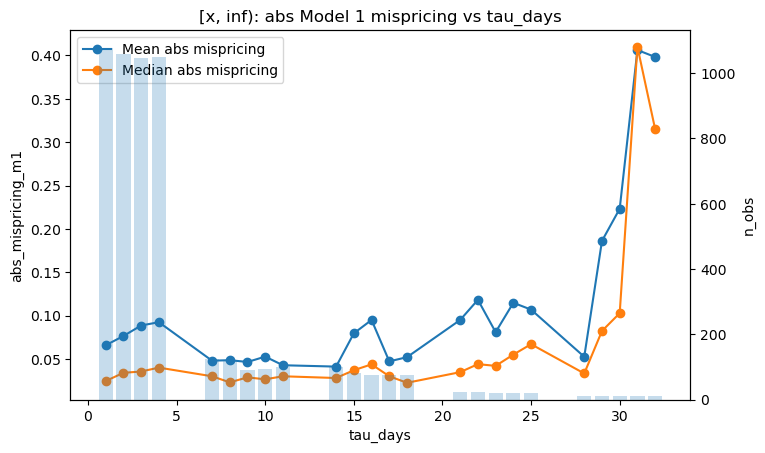

In [114]:
# --------------------------------------------------
# 1. Diagnostic: abs mispricing vs tau_days
# --------------------------------------------------

diag_tau_m1_x_inf = diagnostic_table_and_plot(
    df=diag_x_inf,
    x_col="tau_days",
    y_col="abs_mispricing_m1",
    use_quantile_bins=False,
    title="[x, inf): abs Model 1 mispricing vs tau_days"
)

,x_mean,y_mean,y_median,n_obs
0,2.0,0.088687,0.01950,8
1,3.0,0.101184,0.04500,953
2,4.0,0.098067,0.04000,943
3,5.0,0.078940,0.03500,945
4,6.0,0.067978,0.02450,962
5,7.0,0.065905,0.03500,21
6,10.0,0.060623,0.03100,53
7,11.0,0.054198,0.03000,48
8,12.0,0.076400,0.04000,50
9,13.0,0.086226,0.03900,53


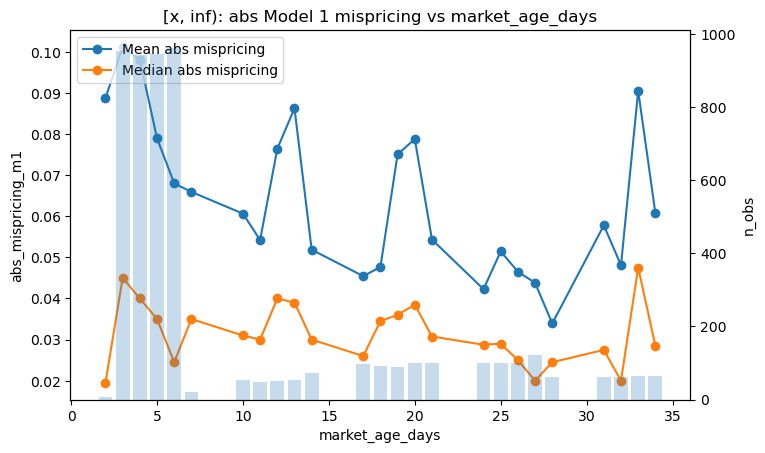

In [115]:
# --------------------------------------------------
# 2. Diagnostic: abs mispricing vs market_age_days
# --------------------------------------------------

diag_age_m1_x_inf = diagnostic_table_and_plot(
    df=diag_x_inf,
    x_col="market_age_days",
    y_col="abs_mispricing_m1",
    use_quantile_bins=False,
    title="[x, inf): abs Model 1 mispricing vs market_age_days"
)

,x_mean,y_mean,y_median,n_obs
0,-0.077319,0.027392,0.00800,278
1,0.010261,0.052223,0.02500,256
2,0.016164,0.054797,0.03475,266
3,0.022721,0.066672,0.04500,265
4,0.029625,0.056987,0.03500,267
5,0.038125,0.076922,0.03800,269
6,0.047955,0.065017,0.04000,263
7,0.059079,0.075968,0.04125,266
8,0.072023,0.072397,0.04300,267
9,0.087046,0.070045,0.03725,280


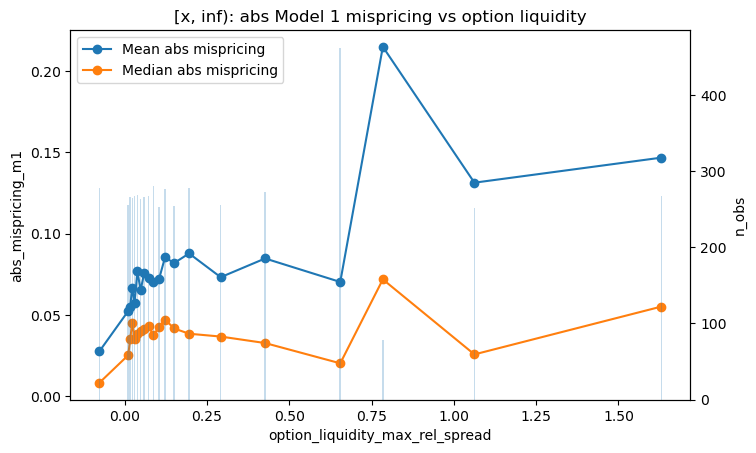

In [116]:
# --------------------------------------------------
# 3. Diagnostic: abs mispricing vs option liquidity
#    Use quantile bins because spread can be skewed
# --------------------------------------------------

diag_liq_m1_x_inf = diagnostic_table_and_plot(
    df=diag_x_inf,
    x_col="option_liquidity_max_rel_spread",
    y_col="abs_mispricing_m1",
    n_bins=20,
    use_quantile_bins=True,
    title="[x, inf): abs Model 1 mispricing vs option liquidity"
)

,x_mean,y_mean,y_median,n_obs
0,-0.505983,0.055650,0.02050,267
1,-0.223105,0.047249,0.01850,267
2,-0.131058,0.037353,0.01650,265
3,-0.103698,0.054908,0.02100,266
4,-0.086279,0.049182,0.02400,267
5,-0.072032,0.072036,0.02925,266
6,-0.059084,0.071837,0.02650,267
7,-0.046654,0.073145,0.03500,265
8,-0.034664,0.084164,0.03500,266
9,-0.022819,0.070755,0.03200,267


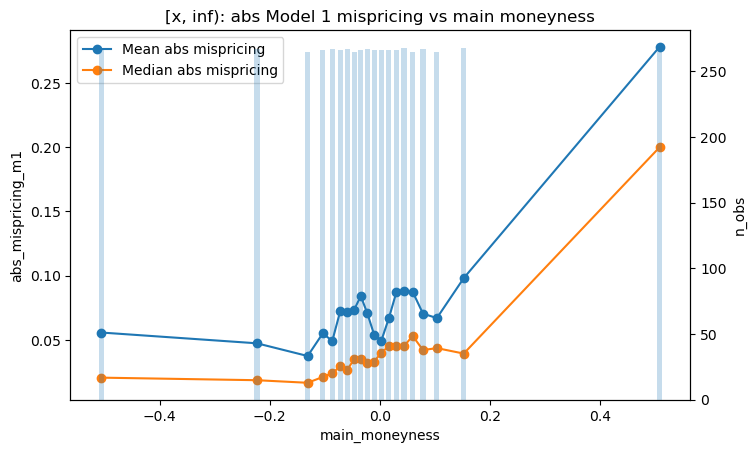

In [117]:
# --------------------------------------------------
# 4. Diagnostic: abs mispricing vs main moneyness
#    Use quantile bins
# --------------------------------------------------

diag_money_m1_x_inf = diagnostic_table_and_plot(
    df=diag_x_inf,
    x_col="main_moneyness",
    y_col="abs_mispricing_m1",
    n_bins=20,
    use_quantile_bins=True,
    title="[x, inf): abs Model 1 mispricing vs main moneyness"
)

,x_mean,y_mean,y_median,n_obs
0,0.008473,0.038737,0.01850,270
1,2.300377,0.080642,0.03175,328
2,3.003637,0.098483,0.03950,319
3,3.004300,0.082207,0.03425,270
4,3.004722,0.088774,0.03750,159
5,3.005135,0.085152,0.03500,306
6,3.005701,0.082867,0.03100,343
7,3.006111,0.101474,0.04750,174
8,3.006536,0.094783,0.04200,415
9,3.006944,0.086581,0.03400,154


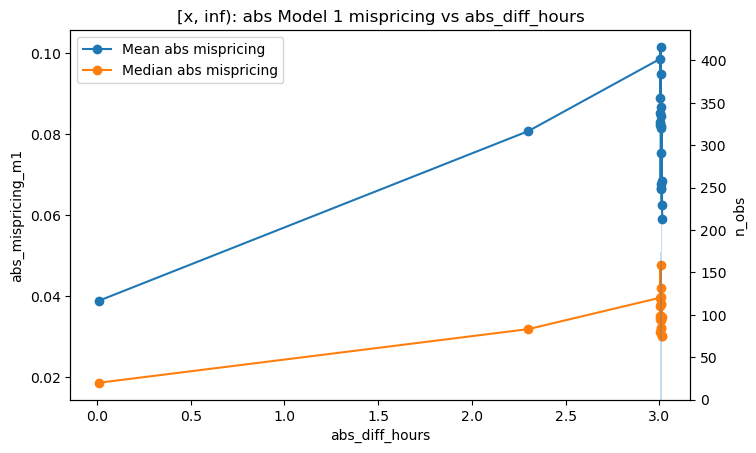

In [118]:
# --------------------------------------------------
# 5. Diagnostic: abs mispricing vs abs_diff_hours
# --------------------------------------------------

diag_tdiff_m1_x_inf = diagnostic_table_and_plot(
    df=diag_x_inf,
    x_col="abs_diff_hours",
    y_col="abs_mispricing_m1",
    n_bins=20,
    use_quantile_bins=True,
    title="[x, inf): abs Model 1 mispricing vs abs_diff_hours"
)

In [119]:
# --------------------------------------------------
# Next step: sanitize liquidity and compare simple candidate filters
# Main focus: [x, inf) loose sample
# --------------------------------------------------

diag_x_inf = market_analysis_ge1000.loc[
    (market_analysis_ge1000["interval_type"] == "[x, inf)") &
    (market_analysis_ge1000["keep_loose_sample"])
].copy()

diag_x_inf["abs_mispricing_m1"] = diag_x_inf["mispricing_m1_pm_minus_model1"].abs()

# Merge back boundary-level quote diagnostics so we can identify crossed quotes
xinf_boundary_flags = boundary_analysis_ge1000.loc[
    boundary_analysis_ge1000["interval_type"] == "[x, inf)",
    [
        "pm_market_id", "date",
        "lower_PX_BID", "lower_PX_ASK",
        "upper_PX_BID", "upper_PX_ASK",
        "lower_rel_spread", "upper_rel_spread",
        "boundary_max_rel_spread"
    ]
].copy()

diag_x_inf = diag_x_inf.merge(
    xinf_boundary_flags,
    on=["pm_market_id", "date"],
    how="left",
    validate="1:1",
    suffixes=("", "_boundary")
)

# Crossed-quote flags
diag_x_inf["lower_crossed_quote"] = diag_x_inf["lower_PX_ASK"] < diag_x_inf["lower_PX_BID"]
diag_x_inf["upper_crossed_quote"] = diag_x_inf["upper_PX_ASK"] < diag_x_inf["upper_PX_BID"]
diag_x_inf["any_crossed_quote"] = (
    diag_x_inf["lower_crossed_quote"].fillna(False) |
    diag_x_inf["upper_crossed_quote"].fillna(False)
)

# Clean liquidity measure:
# keep the same relative-spread concept, but treat negative spreads as invalid
diag_x_inf["lower_rel_spread_clean"] = diag_x_inf["lower_rel_spread"].where(
    diag_x_inf["lower_rel_spread"] >= 0
)
diag_x_inf["upper_rel_spread_clean"] = diag_x_inf["upper_rel_spread"].where(
    diag_x_inf["upper_rel_spread"] >= 0
)
diag_x_inf["option_liquidity_clean"] = diag_x_inf[
    ["lower_rel_spread_clean", "upper_rel_spread_clean"]
].max(axis=1, skipna=True)

# Quick sanity check
liquidity_sanity = pd.DataFrame({
    "metric": [
        "n_rows",
        "share_any_crossed_quote",
        "share_lower_crossed_quote",
        "share_upper_crossed_quote",
        "share_missing_option_liquidity_clean",
        "min_option_liquidity_raw",
        "min_option_liquidity_clean",
        "p50_option_liquidity_clean",
        "p90_option_liquidity_clean",
        "p95_option_liquidity_clean",
        "p99_option_liquidity_clean",
        "max_option_liquidity_clean",
    ],
    "value": [
        len(diag_x_inf),
        diag_x_inf["any_crossed_quote"].mean(),
        diag_x_inf["lower_crossed_quote"].mean(),
        diag_x_inf["upper_crossed_quote"].mean(),
        diag_x_inf["option_liquidity_clean"].isna().mean(),
        diag_x_inf["option_liquidity_max_rel_spread"].min(),
        diag_x_inf["option_liquidity_clean"].min(),
        diag_x_inf["option_liquidity_clean"].median(),
        diag_x_inf["option_liquidity_clean"].quantile(0.90),
        diag_x_inf["option_liquidity_clean"].quantile(0.95),
        diag_x_inf["option_liquidity_clean"].quantile(0.99),
        diag_x_inf["option_liquidity_clean"].max(),
    ]
})

display(liquidity_sanity)

# --------------------------------------------------
# Candidate filter table
# --------------------------------------------------

def summarize_candidate(df, label, mask):
    sub = df.loc[mask].copy()
    return {
        "filter_label": label,
        "n_obs": len(sub),
        "share_obs_kept": len(sub) / len(df),
        "n_markets": sub["pm_market_id"].nunique(),
        "n_events": sub["event_id"].nunique(),
        "mean_abs_mispricing_m1": sub["abs_mispricing_m1"].mean(),
        "median_abs_mispricing_m1": sub["abs_mispricing_m1"].median(),
        "mean_model2_range_width": sub["model2_range_width"].mean(),
        "share_pm_inside_model2_range": sub["pm_inside_model2_range"].mean(),
    }

candidate_rows = []

base = diag_x_inf["abs_mispricing_m1"].notna()
candidate_rows.append(summarize_candidate(diag_x_inf, "base_loose_sample", base))

no_cross = base & (~diag_x_inf["any_crossed_quote"])
candidate_rows.append(summarize_candidate(diag_x_inf, "drop_any_crossed_quote", no_cross))

for thr in [0.25, 0.50, 0.75, 1.00]:
    mask = no_cross & (diag_x_inf["option_liquidity_clean"] <= thr)
    candidate_rows.append(
        summarize_candidate(diag_x_inf, f"no_cross & liquidity<={thr:.2f}", mask)
    )

for thr in [0.10, 0.15, 0.20, 0.25]:
    mask = no_cross & (diag_x_inf["main_moneyness"].abs() <= thr)
    candidate_rows.append(
        summarize_candidate(diag_x_inf, f"no_cross & |moneyness|<={thr:.2f}", mask)
    )

mask_tight_time = no_cross & (diag_x_inf["abs_diff_hours"] <= 1.0)
candidate_rows.append(
    summarize_candidate(diag_x_inf, "no_cross & abs_diff_hours<=1", mask_tight_time)
)

candidate_filter_table = pd.DataFrame(candidate_rows)
display(candidate_filter_table)

,metric,value
0,n_rows,5325.000000
1,share_any_crossed_quote,0.042629
2,share_lower_crossed_quote,0.019155
3,share_upper_crossed_quote,0.028732
4,share_missing_option_liquidity_clean,0.005258
5,min_option_liquidity_raw,-1.694656
6,min_option_liquidity_clean,0.000000
7,p50_option_liquidity_clean,0.095238
8,p90_option_liquidity_clean,0.857143
9,p95_option_liquidity_clean,1.314694


,filter_label,n_obs,share_obs_kept,n_markets,n_events,mean_abs_mispricing_m1,median_abs_mispricing_m1,mean_model2_range_width,share_pm_inside_model2_range
0,base_loose_sample,5325,1.000000,1079,187,0.078033,0.0345,0.404688,0.466291
1,drop_any_crossed_quote,5098,0.957371,1055,183,0.079801,0.0350,0.423078,0.486465
2,no_cross & liquidity<=0.25,3643,0.684131,897,161,0.068931,0.0360,0.313540,0.518254
3,no_cross & liquidity<=0.50,4069,0.764131,988,172,0.070442,0.0360,0.319991,0.499631
4,no_cross & liquidity<=0.75,4546,0.853709,1030,179,0.071237,0.0350,0.321102,0.472943
5,no_cross & liquidity<=1.00,4734,0.889014,1036,181,0.073944,0.0350,0.340710,0.470638
6,no_cross & |moneyness|<=0.10,3584,0.673052,849,171,0.071268,0.0360,0.211991,0.445592
7,no_cross & |moneyness|<=0.15,4242,0.796620,937,181,0.068558,0.0350,0.248525,0.457096
8,no_cross & |moneyness|<=0.20,4468,0.839061,960,182,0.069498,0.0350,0.273444,0.465309
9,no_cross & |moneyness|<=0.25,4564,0.857089,977,182,0.070526,0.0350,0.284375,0.466477


In [120]:
# --------------------------------------------------
# Compare a few simple combined filter candidates
# Main sample: [x, inf), loose sample
# --------------------------------------------------

candidate_rows_2 = []

base = diag_x_inf["abs_mispricing_m1"].notna()
no_cross = base & (~diag_x_inf["any_crossed_quote"])

def summarize_candidate(df, label, mask):
    sub = df.loc[mask].copy()
    return {
        "filter_label": label,
        "n_obs": len(sub),
        "share_obs_kept": len(sub) / len(df),
        "n_markets": sub["pm_market_id"].nunique(),
        "n_events": sub["event_id"].nunique(),
        "mean_abs_mispricing_m1": sub["abs_mispricing_m1"].mean(),
        "median_abs_mispricing_m1": sub["abs_mispricing_m1"].median(),
        "mean_model2_range_width": sub["model2_range_width"].mean(),
        "median_model2_range_width": sub["model2_range_width"].median(),
        "share_pm_inside_model2_range": sub["pm_inside_model2_range"].mean(),
    }

filter_dict = {
    "base_loose_sample": base,
    "no_cross": no_cross,
    "no_cross & liq<=0.75": no_cross & (diag_x_inf["option_liquidity_clean"] <= 0.75),
    "no_cross & liq<=0.50": no_cross & (diag_x_inf["option_liquidity_clean"] <= 0.50),
    "no_cross & |money|<=0.15": no_cross & (diag_x_inf["main_moneyness"].abs() <= 0.15),
    "no_cross & liq<=0.75 & |money|<=0.15": (
        no_cross
        & (diag_x_inf["option_liquidity_clean"] <= 0.75)
        & (diag_x_inf["main_moneyness"].abs() <= 0.15)
    ),
    "no_cross & liq<=0.50 & |money|<=0.15": (
        no_cross
        & (diag_x_inf["option_liquidity_clean"] <= 0.50)
        & (diag_x_inf["main_moneyness"].abs() <= 0.15)
    ),
    "no_cross & liq<=0.75 & |money|<=0.20": (
        no_cross
        & (diag_x_inf["option_liquidity_clean"] <= 0.75)
        & (diag_x_inf["main_moneyness"].abs() <= 0.20)
    ),
}

for label, mask in filter_dict.items():
    candidate_rows_2.append(summarize_candidate(diag_x_inf, label, mask))

candidate_filter_table_2 = pd.DataFrame(candidate_rows_2)

display(
    candidate_filter_table_2.sort_values(
        ["mean_abs_mispricing_m1", "share_obs_kept"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

,filter_label,n_obs,share_obs_kept,n_markets,n_events,mean_abs_mispricing_m1,median_abs_mispricing_m1,mean_model2_range_width,median_model2_range_width,share_pm_inside_model2_range
0,no_cross & |money|<=0.15,4242,0.796620,937,181,0.068558,0.0350,0.248525,0.05,0.457096
1,no_cross & liq<=0.75 & |money|<=0.15,4013,0.753615,925,178,0.069139,0.0350,0.253783,0.05,0.464490
2,no_cross & liq<=0.75 & |money|<=0.20,4191,0.787042,945,179,0.069386,0.0350,0.274631,0.05,0.473157
3,no_cross & liq<=0.50 & |money|<=0.15,3695,0.693897,891,172,0.069787,0.0380,0.271320,0.06,0.493911
4,no_cross & liq<=0.50,4069,0.764131,988,172,0.070442,0.0360,0.319991,0.06,0.499631
5,no_cross & liq<=0.75,4546,0.853709,1030,179,0.071237,0.0350,0.321102,0.05,0.472943
6,base_loose_sample,5325,1.000000,1079,187,0.078033,0.0345,0.404688,0.05,0.466291
7,no_cross,5098,0.957371,1055,183,0.079801,0.0350,0.423078,0.05,0.486465


In [123]:
# --------------------------------------------------
# Build a separate clean-sample working DataFrame
# Do NOT modify market_analysis_ge1000
# --------------------------------------------------

# 1) Boundary-level quote-quality variables
boundary_quote_filters_ge1000 = boundary_analysis_ge1000.copy()

boundary_quote_filters_ge1000["lower_crossed_quote"] = (
    boundary_quote_filters_ge1000["lower_PX_BID"].notna() &
    boundary_quote_filters_ge1000["lower_PX_ASK"].notna() &
    (boundary_quote_filters_ge1000["lower_PX_BID"] > boundary_quote_filters_ge1000["lower_PX_ASK"])
)

boundary_quote_filters_ge1000["upper_crossed_quote"] = (
    boundary_quote_filters_ge1000["upper_PX_BID"].notna() &
    boundary_quote_filters_ge1000["upper_PX_ASK"].notna() &
    (boundary_quote_filters_ge1000["upper_PX_BID"] > boundary_quote_filters_ge1000["upper_PX_ASK"])
)

boundary_quote_filters_ge1000["boundary_any_crossed_quote"] = (
    boundary_quote_filters_ge1000["lower_crossed_quote"] |
    boundary_quote_filters_ge1000["upper_crossed_quote"]
)

# Relative option spread (renamed for clarity)
boundary_quote_filters_ge1000["lower_rel_opt_spread_raw"] = boundary_quote_filters_ge1000["lower_rel_spread"]
boundary_quote_filters_ge1000["upper_rel_opt_spread_raw"] = boundary_quote_filters_ge1000["upper_rel_spread"]

boundary_quote_filters_ge1000["lower_rel_opt_spread"] = (
    boundary_quote_filters_ge1000["lower_rel_opt_spread_raw"]
    .where(boundary_quote_filters_ge1000["lower_rel_opt_spread_raw"] >= 0)
)

boundary_quote_filters_ge1000["upper_rel_opt_spread"] = (
    boundary_quote_filters_ge1000["upper_rel_opt_spread_raw"]
    .where(boundary_quote_filters_ge1000["upper_rel_opt_spread_raw"] >= 0)
)

boundary_quote_filters_ge1000["boundary_max_rel_opt_spread"] = (
    boundary_quote_filters_ge1000[["lower_rel_opt_spread", "upper_rel_opt_spread"]]
    .max(axis=1, skipna=True)
)

# 2) Aggregate to market-date level
market_quote_filters_ge1000 = (
    boundary_quote_filters_ge1000.groupby(["pm_market_id", "date"])
    .agg(
        any_crossed_quote=("boundary_any_crossed_quote", "max"),
        max_rel_opt_spread=("boundary_max_rel_opt_spread", "max"),
    )
    .reset_index()
)

# 3) Create a separate working copy for the clean/final sample
market_analysis_clean_ge1000 = market_analysis_ge1000.copy()

market_analysis_clean_ge1000 = market_analysis_clean_ge1000.merge(
    market_quote_filters_ge1000,
    on=["pm_market_id", "date"],
    how="left",
    validate="1:1"
)

print("market_analysis_ge1000 unchanged shape      :", market_analysis_ge1000.shape)
print("market_analysis_clean_ge1000 shape          :", market_analysis_clean_ge1000.shape)

display(
    market_analysis_clean_ge1000[
        [
            "pm_market_id", "date", "interval_type",
            "any_crossed_quote", "max_rel_opt_spread"
        ]
    ].head(10)
)

market_analysis_ge1000 unchanged shape      : (11520, 52)
market_analysis_clean_ge1000 shape          : (11520, 54)


,pm_market_id,date,interval_type,any_crossed_quote,max_rel_opt_spread
0,974364,2025-12-22,"[x, inf)",False,0.113935
1,974365,2025-12-22,"[x, inf)",False,0.124481
2,974366,2025-12-22,"[x, inf)",False,0.124481
3,974367,2025-12-22,"[x, inf)",False,0.046243
4,974368,2025-12-22,"[x, inf)",False,0.046243
5,974369,2025-12-22,"[0, x]",False,0.124481
6,974370,2025-12-22,"[x, inf)",False,0.036810
7,974371,2025-12-22,"[x, y]",False,0.124481
8,974373,2025-12-22,"[x, y]",False,0.124481
9,974374,2025-12-22,"[x, y]",False,0.046243


In [124]:
# --------------------------------------------------
# Apply final common-sample filter on the copied DataFrame
# --------------------------------------------------

market_analysis_clean_ge1000["valid_all_3_models"] = (
    market_analysis_clean_ge1000["model1_price"].notna() &
    market_analysis_clean_ge1000["model2_low"].notna() &
    market_analysis_clean_ge1000["model2_high"].notna() &
    market_analysis_clean_ge1000["model3_price"].notna()
)

market_analysis_clean_ge1000["keep_final_common_sample"] = (
    market_analysis_clean_ge1000["keep_loose_sample"] &
    (~market_analysis_clean_ge1000["any_crossed_quote"].fillna(False)) &
    (market_analysis_clean_ge1000["max_rel_opt_spread"] <= 0.50) &
    market_analysis_clean_ge1000["valid_all_3_models"]
)

final_common_sample_ge1000 = market_analysis_clean_ge1000.loc[
    market_analysis_clean_ge1000["keep_final_common_sample"]
].copy()

final_filter_summary = pd.DataFrame({
    "metric": [
        "n_market_day_before",
        "n_market_day_after",
        "share_obs_kept",
        "n_markets_after",
        "n_events_after",
        "share_crossed_quote",
        "share_fail_rel_opt_spread",
        "share_valid_all_3_models",
        "mean_abs_mispricing_m1_after",
        "median_abs_mispricing_m1_after",
        "mean_abs_mispricing_m3_after",
        "median_abs_mispricing_m3_after",
    ],
    "value": [
        len(market_analysis_clean_ge1000),
        len(final_common_sample_ge1000),
        len(final_common_sample_ge1000) / len(market_analysis_clean_ge1000),
        final_common_sample_ge1000["pm_market_id"].nunique(),
        final_common_sample_ge1000["event_id"].nunique(),
        market_analysis_clean_ge1000["any_crossed_quote"].mean(),
        (market_analysis_clean_ge1000["max_rel_opt_spread"] > 0.50).mean(),
        market_analysis_clean_ge1000["valid_all_3_models"].mean(),
        final_common_sample_ge1000["mispricing_m1_pm_minus_model1"].abs().mean(),
        final_common_sample_ge1000["mispricing_m1_pm_minus_model1"].abs().median(),
        final_common_sample_ge1000["mispricing_m3_pm_minus_model3"].abs().mean(),
        final_common_sample_ge1000["mispricing_m3_pm_minus_model3"].abs().median(),
    ]
})

display(final_filter_summary)

display(
    final_common_sample_ge1000.groupby("interval_type")
    .agg(
        n_rows=("pm_market_id", "size"),
        n_markets=("pm_market_id", "nunique"),
        n_events=("event_id", "nunique"),
        mean_abs_mispricing_m1=("mispricing_m1_pm_minus_model1", lambda s: s.abs().mean()),
        mean_abs_mispricing_m3=("mispricing_m3_pm_minus_model3", lambda s: s.abs().mean()),
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

,metric,value
0,n_market_day_before,11520.000000
1,n_market_day_after,6136.000000
2,share_obs_kept,0.532639
3,n_markets_after,1635.000000
4,n_events_after,213.000000
5,share_crossed_quote,0.095139
6,share_fail_rel_opt_spread,0.182812
7,share_valid_all_3_models,0.867274
8,mean_abs_mispricing_m1_after,0.070027
9,median_abs_mispricing_m1_after,0.037500


,interval_type,n_rows,n_markets,n_events,mean_abs_mispricing_m1,mean_abs_mispricing_m3
1,"[x, inf)",4041,979,171,0.070691,0.072146
2,"[x, y]",1859,592,95,0.069771,0.058552
0,"[0, x]",236,64,64,0.060665,0.053570


In [126]:
# --------------------------------------------------
# Review columns before saving
# --------------------------------------------------

print("market_analysis_clean_ge1000 shape:", market_analysis_clean_ge1000.shape)
print("final_common_sample_ge1000 shape  :", final_common_sample_ge1000.shape)

print("\nColumns in final_common_sample_ge1000:")
print(final_common_sample_ge1000.columns.tolist())

display(final_common_sample_ge1000.head(3))

market_analysis_clean_ge1000 shape: (11520, 56)
final_common_sample_ge1000 shape  : (6136, 56)

Columns in final_common_sample_ge1000:
['pm_market_id', 'date', 'stock_ticker', 'event_id', 'event_slug', 'event_title', 'interval_type', 'option_expiry', 'pm_price_yes', 'stock_close_nocp', 'abs_diff_hours', 'fidelity_used', 'data_regime', 'boundary_no', 'pm_boundary_strike', 'model1_price', 'model2_low', 'model2_high', 'model3_price', 'digital_m1_mid_b1', 'digital_m1_mid_b2', 'digital_m2_high_b1', 'digital_m2_high_b2', 'digital_m2_low_b1', 'digital_m2_low_b2', 'digital_m3_iv_b1', 'digital_m3_iv_b2', 'pm_boundary_strike_b1', 'pm_boundary_strike_b2', 'mispricing_m1_pm_minus_model1', 'mispricing_m3_pm_minus_model3', 'pm_inside_model2_range', 'pm_minus_model2_low', 'pm_minus_model2_high', 'model2_range_width', 'stock_ticker_var', 'interval_type_var', 'event_id_var', 'option_expiry_var', 'tau_days', 'abs_diff_hours_var', 'market_age_days', 'is_expiry_day', 'keep_tau_ge1', 'keep_market_age_ge2',

,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,boundary_no,pm_boundary_strike,model1_price,model2_low,model2_high,model3_price,digital_m1_mid_b1,digital_m1_mid_b2,digital_m2_high_b1,digital_m2_high_b2,digital_m2_low_b1,digital_m2_low_b2,digital_m3_iv_b1,digital_m3_iv_b2,pm_boundary_strike_b1,pm_boundary_strike_b2,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,pm_inside_model2_range,pm_minus_model2_low,pm_minus_model2_high,model2_range_width,stock_ticker_var,interval_type_var,event_id_var,option_expiry_var,tau_days,abs_diff_hours_var,market_age_days,is_expiry_day,keep_tau_ge1,keep_market_age_ge2,keep_loose_sample,option_liquidity_max_rel_spread,n_boundaries_present,boundary_moneyness_b1,boundary_moneyness_b2,main_moneyness,keep_main_moneyness_sample,any_crossed_quote,max_rel_opt_spread,valid_all_3_models,keep_final_common_sample
0,974364,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1.0,245.0,1.095,0.59,1.60,0.995149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1205,-0.020649,True,0.3845,-0.6255,1.01,AAPL,"[x, inf)",112365,2025-12-26,4,3.006667,3,False,True,True,True,0.113935,1,0.100750,NaN,0.100750,True,False,0.113935,True,True
1,974365,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,1.0,250.0,0.995,0.59,1.40,0.996240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0250,-0.026240,True,0.3800,-0.4300,0.81,AAPL,"[x, inf)",112365,2025-12-26,4,3.005833,3,False,True,True,True,0.124481,1,0.080547,NaN,0.080547,True,False,0.124481,True,True
2,974366,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,1.0,255.0,0.895,0.61,1.18,1.030676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0660,-0.069676,True,0.3510,-0.2190,0.57,AAPL,"[x, inf)",112365,2025-12-26,4,3.002222,3,False,True,True,True,0.124481,1,0.060745,NaN,0.060745,True,False,0.124481,True,True


In [127]:
# --------------------------------------------------
# Count observations before and after Step 4 only
# Step 4 = require validity for all 3 models
# Base here = sample AFTER steps 1-3, BEFORE step 4
# --------------------------------------------------

# sample after steps 1-3 only
sample_after_step3 = market_analysis_clean_ge1000.loc[
    market_analysis_clean_ge1000["keep_loose_sample"] &
    (~market_analysis_clean_ge1000["any_crossed_quote"].fillna(False)) &
    (market_analysis_clean_ge1000["max_rel_opt_spread"] <= 0.50)
].copy()

# step 4 validity flag
sample_after_step3["valid_all_3_models"] = (
    sample_after_step3["model1_price"].notna() &
    sample_after_step3["model2_low"].notna() &
    sample_after_step3["model2_high"].notna() &
    sample_after_step3["model3_price"].notna()
)

# sample after step 4
sample_after_step4 = sample_after_step3.loc[
    sample_after_step3["valid_all_3_models"]
].copy()

step4_count_summary = pd.DataFrame({
    "metric": [
        "n_obs_after_step3_before_step4",
        "n_obs_after_step4",
        "n_obs_dropped_by_step4",
        "share_kept_in_step4",
        "share_dropped_in_step4",
        "n_markets_before_step4",
        "n_markets_after_step4",
        "n_events_before_step4",
        "n_events_after_step4",
    ],
    "value": [
        len(sample_after_step3),
        len(sample_after_step4),
        len(sample_after_step3) - len(sample_after_step4),
        len(sample_after_step4) / len(sample_after_step3) if len(sample_after_step3) > 0 else np.nan,
        1 - len(sample_after_step4) / len(sample_after_step3) if len(sample_after_step3) > 0 else np.nan,
        sample_after_step3["pm_market_id"].nunique(),
        sample_after_step4["pm_market_id"].nunique(),
        sample_after_step3["event_id"].nunique(),
        sample_after_step4["event_id"].nunique(),
    ]
})

display(step4_count_summary)

# Optional: by interval type
step4_by_interval = pd.concat([
    sample_after_step3.groupby("interval_type").size().rename("n_before_step4"),
    sample_after_step4.groupby("interval_type").size().rename("n_after_step4"),
], axis=1).fillna(0)

step4_by_interval["n_dropped_by_step4"] = (
    step4_by_interval["n_before_step4"] - step4_by_interval["n_after_step4"]
)
step4_by_interval["share_kept_in_step4"] = (
    step4_by_interval["n_after_step4"] / step4_by_interval["n_before_step4"]
)

display(step4_by_interval.reset_index())

,metric,value
0,n_obs_after_step3_before_step4,6187.000000
1,n_obs_after_step4,6136.000000
2,n_obs_dropped_by_step4,51.000000
3,share_kept_in_step4,0.991757
4,share_dropped_in_step4,0.008243
5,n_markets_before_step4,1654.000000
6,n_markets_after_step4,1635.000000
7,n_events_before_step4,214.000000
8,n_events_after_step4,213.000000


,interval_type,n_before_step4,n_after_step4,n_dropped_by_step4,share_kept_in_step4
0,"[0, x]",241,236,5,0.979253
1,"[x, inf)",4069,4041,28,0.993119
2,"[x, y]",1877,1859,18,0.990410


In [128]:
final_common_sample_ge1000.to_csv("final_common_sample_ge1000.csv", index=False)
print("Saved: final_common_sample_ge1000.csv")

Saved: final_common_sample_ge1000.csv


In [129]:
# --------------------------------------------------
# Final sample: add derived analysis variables
# --------------------------------------------------

final_sample = final_common_sample_ge1000.copy()

# Absolute mispricing for point models
final_sample["abs_mispricing_m1"] = final_sample["mispricing_m1_pm_minus_model1"].abs()
final_sample["abs_mispricing_m3"] = final_sample["mispricing_m3_pm_minus_model3"].abs()

# Model 2 range-position indicators
final_sample["pm_below_model2_range"] = final_sample["pm_price_yes"] < final_sample["model2_low"]
final_sample["pm_above_model2_range"] = final_sample["pm_price_yes"] > final_sample["model2_high"]

# Optional: refresh inside-range indicator for completeness / consistency
final_sample["pm_inside_model2_range"] = (
    (final_sample["pm_price_yes"] >= final_sample["model2_low"]) &
    (final_sample["pm_price_yes"] <= final_sample["model2_high"])
)

# Quick sanity check: below / inside / above should partition the sample
final_sample["model2_range_position_check"] = (
    final_sample["pm_below_model2_range"].astype(int) +
    final_sample["pm_inside_model2_range"].astype(int) +
    final_sample["pm_above_model2_range"].astype(int)
)

sanity_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "share_abs_mispricing_m1_missing",
        "share_abs_mispricing_m3_missing",
        "share_pm_below_model2_range",
        "share_pm_inside_model2_range",
        "share_pm_above_model2_range",
        "all_rows_have_exactly_one_model2_position_flag",
    ],
    "value": [
        len(final_sample),
        final_sample["abs_mispricing_m1"].isna().mean(),
        final_sample["abs_mispricing_m3"].isna().mean(),
        final_sample["pm_below_model2_range"].mean(),
        final_sample["pm_inside_model2_range"].mean(),
        final_sample["pm_above_model2_range"].mean(),
        final_sample["model2_range_position_check"].eq(1).all(),
    ]
})

display(sanity_summary)

# --------------------------------------------------
# Save final sample for use in a new notebook
# --------------------------------------------------

final_sample.to_csv("final_sample.csv", index=False)
print("Saved: final_sample.csv")
print("final_sample shape:", final_sample.shape)

,metric,value
0,n_rows,6136
1,share_abs_mispricing_m1_missing,0.0
2,share_abs_mispricing_m3_missing,0.0
3,share_pm_below_model2_range,0.139668
4,share_pm_inside_model2_range,0.562256
5,share_pm_above_model2_range,0.298077
6,all_rows_have_exactly_one_model2_position_flag,True


Saved: final_sample.csv
final_sample shape: (6136, 61)


In [130]:
# --------------------------------------------------
# Check where PLTR disappears
# --------------------------------------------------

def stock_counts(df, name):
    out = (
        df.groupby("stock_ticker")
        .agg(
            n_rows=("stock_ticker", "size")
        )
        .reset_index()
        .sort_values("stock_ticker")
    )
    out["stage"] = name
    return out

checks = []

# 1. Exact-expiry event sample -> markets_exact / pm_markets_static stage
checks.append(stock_counts(pm_markets_static, "pm_markets_static"))

# 2. Boundary-level universe before requiring all-valid boundaries
checks.append(stock_counts(pm_market_boundaries, "pm_market_boundaries"))

# 3. Market validity table
validity_by_stock = (
    market_boundary_validity.groupby("stock_ticker")
    .agg(
        n_markets_total=("pm_market_id", "size"),
        n_markets_priceable_static=("market_is_priceable_static", "sum")
    )
    .reset_index()
    .sort_values("stock_ticker")
)
display(validity_by_stock)

# 4. Final static priceable universe
checks.append(stock_counts(pm_markets_priceable_static, "pm_markets_priceable_static"))

stock_stage_check = pd.concat(checks, ignore_index=True)
display(stock_stage_check)

,stock_ticker,n_markets_total,n_markets_priceable_static
0,AAPL,364,317
1,AMZN,361,302
2,GOOGL,342,295
3,META,349,280
4,MSFT,356,276
5,NFLX,284,96
6,NVDA,378,309
7,OPEN,284,228
8,PLTR,241,0
9,TSLA,352,311


,stock_ticker,n_rows,stage
0,AAPL,364,pm_markets_static
1,AMZN,361,pm_markets_static
2,GOOGL,342,pm_markets_static
3,META,349,pm_markets_static
4,MSFT,356,pm_markets_static
5,NFLX,284,pm_markets_static
6,NVDA,378,pm_markets_static
7,OPEN,284,pm_markets_static
8,PLTR,241,pm_markets_static
9,TSLA,352,pm_markets_static


In [131]:
# --------------------------------------------------
# Why does PLTR fail the static priceable-universe step?
# --------------------------------------------------

# 1. Market-level validity for PLTR
pltr_validity = (
    market_boundary_validity.loc[market_boundary_validity["stock_ticker"] == "PLTR"]
    .copy()
)

print("PLTR market validity summary")
display(
    pltr_validity["market_is_priceable_static"]
    .value_counts(dropna=False)
    .rename_axis("market_is_priceable_static")
    .reset_index(name="n_markets")
)

display(pltr_validity.head(20))


# 2. Boundary-level failure reasons for PLTR
pltr_boundaries = pm_market_boundaries.loc[
    pm_market_boundaries["stock_ticker"] == "PLTR"
].copy()

pltr_boundaries["fail_missing_lower"] = ~pltr_boundaries["has_valid_lower"]
pltr_boundaries["fail_missing_upper"] = ~pltr_boundaries["has_valid_upper"]
pltr_boundaries["fail_pair"] = ~pltr_boundaries["has_valid_pair"]

print("PLTR boundary rows:", len(pltr_boundaries))

display(
    pd.DataFrame({
        "metric": [
            "n_boundary_rows",
            "share_has_valid_lower",
            "share_has_valid_upper",
            "share_has_valid_pair",
            "n_fail_lower",
            "n_fail_upper",
            "n_fail_pair",
        ],
        "value": [
            len(pltr_boundaries),
            pltr_boundaries["has_valid_lower"].mean(),
            pltr_boundaries["has_valid_upper"].mean(),
            pltr_boundaries["has_valid_pair"].mean(),
            (~pltr_boundaries["has_valid_lower"]).sum(),
            (~pltr_boundaries["has_valid_upper"]).sum(),
            (~pltr_boundaries["has_valid_pair"]).sum(),
        ]
    })
)


# 3. Gap diagnostics
display(
    pltr_boundaries[["lower_gap", "upper_gap"]].describe()
)

display(
    pltr_boundaries.groupby("interval_type")
    .agg(
        n_boundary_rows=("pm_market_id", "size"),
        share_has_valid_lower=("has_valid_lower", "mean"),
        share_has_valid_upper=("has_valid_upper", "mean"),
        share_has_valid_pair=("has_valid_pair", "mean"),
        avg_lower_gap=("lower_gap", "mean"),
        avg_upper_gap=("upper_gap", "mean"),
    )
    .reset_index()
)


# 4. Show failed examples
pltr_failed_examples = pltr_boundaries.loc[
    ~pltr_boundaries["has_valid_pair"],
    [
        "pm_market_id", "event_id", "interval_type", "boundary_no",
        "lower_bound", "upper_bound", "pm_boundary_strike",
        "lower_option_strike", "upper_option_strike",
        "lower_gap", "upper_gap",
        "has_valid_lower", "has_valid_upper", "has_valid_pair"
    ]
].copy()

display(
    pltr_failed_examples
    .sort_values(["interval_type", "pm_market_id", "boundary_no"])
    .head(50)
)

PLTR market validity summary


,market_is_priceable_static,n_markets
0,False,241


,pm_market_id,n_required_boundaries,n_valid_boundaries,stock_ticker,interval_type,event_id,market_is_priceable_static
192,974603,1,0,PLTR,"[0, x]",112391,False
193,974604,2,0,PLTR,"[x, y]",112391,False
194,974605,2,0,PLTR,"[x, y]",112391,False
195,974606,2,0,PLTR,"[x, y]",112391,False
196,974607,2,0,PLTR,"[x, y]",112391,False
197,974608,2,0,PLTR,"[x, y]",112391,False
198,974609,2,0,PLTR,"[x, y]",112391,False
199,974610,2,0,PLTR,"[x, y]",112391,False
200,974611,2,0,PLTR,"[x, y]",112391,False
201,974612,2,0,PLTR,"[x, y]",112391,False


PLTR boundary rows: 322


,metric,value
0,n_boundary_rows,322.000000
1,share_has_valid_lower,0.139752
2,share_has_valid_upper,0.177019
3,share_has_valid_pair,0.000000
4,n_fail_lower,277.000000
5,n_fail_upper,265.000000
6,n_fail_pair,322.000000


,lower_gap,upper_gap
count,224.000000,292.000000
mean,2.446429,4.397260
std,1.472250,5.310599
min,0.500000,0.500000
25%,1.500000,1.500000
50%,2.500000,2.500000
75%,3.500000,4.500000
max,9.500000,26.500000


,interval_type,n_boundary_rows,share_has_valid_lower,share_has_valid_upper,share_has_valid_pair,avg_lower_gap,avg_upper_gap
0,"[0, x]",9,0.000000,0.000000,0.0,NaN,6.833333
1,"[x, inf)",151,0.152318,0.178808,0.0,2.491379,4.088235
2,"[x, y]",162,0.135802,0.185185,0.0,2.398148,4.534014


,pm_market_id,event_id,interval_type,boundary_no,lower_bound,upper_bound,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_gap,upper_gap,has_valid_lower,has_valid_upper,has_valid_pair
264,974603,112391,"[0, x]",1,0.0,176.0,176.0,NaN,177.5,NaN,1.5,False,False,False
696,1031799,125823,"[0, x]",1,0.0,186.0,186.0,NaN,187.5,NaN,1.5,False,False,False
1018,1091023,139646,"[0, x]",1,0.0,168.0,168.0,NaN,172.5,NaN,4.5,False,False,False
1348,1146644,154138,"[0, x]",1,0.0,168.0,168.0,NaN,172.5,NaN,4.5,False,False,False
1665,1201354,168988,"[0, x]",1,0.0,168.0,168.0,NaN,172.5,NaN,4.5,False,False,False
1958,1253389,184390,"[0, x]",1,0.0,156.0,156.0,NaN,157.5,NaN,1.5,False,False,False
2479,1301863,193978,"[0, x]",1,0.0,142.0,142.0,NaN,152.5,NaN,10.5,False,False,False
3632,1404030,219958,"[0, x]",1,0.0,126.0,126.0,NaN,152.5,NaN,26.5,False,False,False
4182,1666159,290950,"[0, x]",1,0.0,146.0,146.0,NaN,152.5,NaN,6.5,False,False,False
283,974613,112391,"[x, inf)",1,194.0,inf,194.0,192.5,NaN,1.5,NaN,False,False,False


In [132]:
# --------------------------------------------------
# PLTR: distribution of max(lower_gap, upper_gap)
# --------------------------------------------------

pltr_boundaries = pm_market_boundaries.loc[
    pm_market_boundaries["stock_ticker"] == "PLTR"
].copy()

pltr_boundaries["max_gap"] = pltr_boundaries[["lower_gap", "upper_gap"]].max(axis=1, skipna=True)

# Summary stats
max_gap_summary = pd.DataFrame({
    "metric": [
        "n_boundary_rows",
        "n_nonmissing_max_gap",
        "share_nonmissing_max_gap",
        "min",
        "p10",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95",
        "p99",
        "max",
    ],
    "value": [
        len(pltr_boundaries),
        pltr_boundaries["max_gap"].notna().sum(),
        pltr_boundaries["max_gap"].notna().mean(),
        pltr_boundaries["max_gap"].min(),
        pltr_boundaries["max_gap"].quantile(0.10),
        pltr_boundaries["max_gap"].quantile(0.25),
        pltr_boundaries["max_gap"].quantile(0.50),
        pltr_boundaries["max_gap"].quantile(0.75),
        pltr_boundaries["max_gap"].quantile(0.90),
        pltr_boundaries["max_gap"].quantile(0.95),
        pltr_boundaries["max_gap"].quantile(0.99),
        pltr_boundaries["max_gap"].max(),
    ]
})

display(max_gap_summary)

# Frequency table by gap bucket
pltr_boundaries["max_gap_bucket"] = pd.cut(
    pltr_boundaries["max_gap"],
    bins=[-np.inf, 1, 2, 3, 4, 5, 10, np.inf],
    labels=["<=1", "(1,2]", "(2,3]", "(3,4]", "(4,5]", "(5,10]", ">10"]
)

max_gap_bucket_table = (
    pltr_boundaries.groupby("max_gap_bucket", observed=True)
    .agg(
        n_rows=("pm_market_id", "size")
    )
    .reset_index()
)

max_gap_bucket_table["share"] = max_gap_bucket_table["n_rows"] / max_gap_bucket_table["n_rows"].sum()

display(max_gap_bucket_table)

# Optional: see examples with the smallest max gaps
display(
    pltr_boundaries[
        [
            "pm_market_id", "event_id", "interval_type", "boundary_no",
            "pm_boundary_strike", "lower_option_strike", "upper_option_strike",
            "lower_gap", "upper_gap", "max_gap",
            "has_valid_lower", "has_valid_upper", "has_valid_pair"
        ]
    ]
    .sort_values("max_gap")
    .head(30)
)

,metric,value
0,n_boundary_rows,322.00
1,n_nonmissing_max_gap,322.00
2,share_nonmissing_max_gap,1.00
3,min,0.50
4,p10,1.50
5,p25,2.50
6,p50,3.50
7,p75,4.50
8,p90,10.50
9,p95,17.45


,max_gap_bucket,n_rows,share
0,<=1,22,0.068323
1,"(1,2]",25,0.077640
2,"(2,3]",56,0.173913
3,"(3,4]",79,0.245342
4,"(4,5]",91,0.282609
5,"(5,10]",15,0.046584
6,>10,34,0.105590


,pm_market_id,event_id,interval_type,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_gap,upper_gap,max_gap,has_valid_lower,has_valid_upper,has_valid_pair
2492,1301890,193978,"[x, y]",1,158.0,157.5,NaN,0.5,NaN,0.5,True,False,False
1352,1146648,154138,"[x, y]",2,172.0,NaN,172.5,NaN,0.5,0.5,False,True,False
1071,1091058,139649,"[x, inf)",1,172.0,NaN,172.5,NaN,0.5,0.5,False,True,False
2491,1301887,193978,"[x, y]",2,158.0,157.5,NaN,0.5,NaN,0.5,True,False,False
1413,1146695,154141,"[x, inf)",1,183.0,182.5,NaN,0.5,NaN,0.5,True,False,False
4204,1666172,290951,"[x, inf)",1,152.0,NaN,152.5,NaN,0.5,0.5,False,True,False
4188,1666162,290950,"[x, y]",2,152.0,NaN,152.5,NaN,0.5,0.5,False,True,False
4189,1666163,290950,"[x, y]",1,152.0,NaN,152.5,NaN,0.5,0.5,False,True,False
1082,1091069,139649,"[x, inf)",1,183.0,182.5,NaN,0.5,NaN,0.5,True,False,False
1402,1146684,154141,"[x, inf)",1,172.0,NaN,172.5,NaN,0.5,0.5,False,True,False


In [133]:
# --------------------------------------------------
# PLTR: check whether "almost okay" rows fail because
# one side is missing or because one side is too wide
# --------------------------------------------------

pltr_boundaries = pm_market_boundaries.loc[
    pm_market_boundaries["stock_ticker"] == "PLTR"
].copy()

pltr_boundaries["both_sides_present"] = (
    pltr_boundaries["lower_gap"].notna() &
    pltr_boundaries["upper_gap"].notna()
)

pltr_boundaries["both_sides_lt_1"] = (
    pltr_boundaries["both_sides_present"] &
    (pltr_boundaries["lower_gap"] < 1.0) &
    (pltr_boundaries["upper_gap"] < 1.0)
)

pltr_boundaries["both_sides_le_1"] = (
    pltr_boundaries["both_sides_present"] &
    (pltr_boundaries["lower_gap"] <= 1.0) &
    (pltr_boundaries["upper_gap"] <= 1.0)
)

pltr_boundaries["one_side_missing"] = (
    pltr_boundaries["lower_gap"].isna() |
    pltr_boundaries["upper_gap"].isna()
)

pltr_boundaries["max_gap"] = pltr_boundaries[["lower_gap", "upper_gap"]].max(axis=1, skipna=True)

summary_pltr_pair_check = pd.DataFrame({
    "metric": [
        "n_boundary_rows",
        "n_both_sides_present",
        "n_one_side_missing",
        "n_both_sides_lt_1",
        "n_both_sides_le_1",
        "n_has_valid_pair",
    ],
    "value": [
        len(pltr_boundaries),
        pltr_boundaries["both_sides_present"].sum(),
        pltr_boundaries["one_side_missing"].sum(),
        pltr_boundaries["both_sides_lt_1"].sum(),
        pltr_boundaries["both_sides_le_1"].sum(),
        pltr_boundaries["has_valid_pair"].sum(),
    ]
})

display(summary_pltr_pair_check)

# Show the closest PLTR rows to being valid
display(
    pltr_boundaries[
        [
            "pm_market_id", "event_id", "interval_type", "boundary_no",
            "pm_boundary_strike",
            "lower_option_strike", "upper_option_strike",
            "lower_gap", "upper_gap", "max_gap",
            "both_sides_present", "both_sides_lt_1", "both_sides_le_1",
            "has_valid_lower", "has_valid_upper", "has_valid_pair"
        ]
    ]
    .sort_values(["max_gap", "lower_gap", "upper_gap"])
    .head(50)
)

,metric,value
0,n_boundary_rows,322
1,n_both_sides_present,194
2,n_one_side_missing,128
3,n_both_sides_lt_1,0
4,n_both_sides_le_1,0
5,n_has_valid_pair,0


,pm_market_id,event_id,interval_type,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_gap,upper_gap,max_gap,both_sides_present,both_sides_lt_1,both_sides_le_1,has_valid_lower,has_valid_upper,has_valid_pair
1082,1091069,139649,"[x, inf)",1,183.0,182.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
1413,1146695,154141,"[x, inf)",1,183.0,182.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
1743,1201424,168992,"[x, inf)",1,183.0,182.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
2491,1301887,193978,"[x, y]",2,158.0,157.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
2492,1301890,193978,"[x, y]",1,158.0,157.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
2567,1301966,193990,"[x, inf)",1,158.0,157.5,NaN,0.5,NaN,0.5,False,False,False,True,False,False
1022,1091025,139646,"[x, y]",2,172.0,NaN,172.5,NaN,0.5,0.5,False,False,False,False,True,False
1023,1091026,139646,"[x, y]",1,172.0,NaN,172.5,NaN,0.5,0.5,False,False,False,False,True,False
1071,1091058,139649,"[x, inf)",1,172.0,NaN,172.5,NaN,0.5,0.5,False,False,False,False,True,False
1352,1146648,154138,"[x, y]",2,172.0,NaN,172.5,NaN,0.5,0.5,False,False,False,False,True,False


In [134]:
# --------------------------------------------------
# PLTR: among rows where BOTH sides exist,
# distribution of max(lower_gap, upper_gap)
# --------------------------------------------------

pltr_boundaries = pm_market_boundaries.loc[
    pm_market_boundaries["stock_ticker"] == "PLTR"
].copy()

# Keep only rows where both lower and upper option sides exist
pltr_both_sides = pltr_boundaries.loc[
    pltr_boundaries["lower_gap"].notna() &
    pltr_boundaries["upper_gap"].notna()
].copy()

pltr_both_sides["max_gap"] = pltr_both_sides[["lower_gap", "upper_gap"]].max(axis=1)

# Summary stats
max_gap_summary_both_sides = pd.DataFrame({
    "metric": [
        "n_boundary_rows_both_sides",
        "min",
        "p10",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95",
        "p99",
        "max",
    ],
    "value": [
        len(pltr_both_sides),
        pltr_both_sides["max_gap"].min(),
        pltr_both_sides["max_gap"].quantile(0.10),
        pltr_both_sides["max_gap"].quantile(0.25),
        pltr_both_sides["max_gap"].quantile(0.50),
        pltr_both_sides["max_gap"].quantile(0.75),
        pltr_both_sides["max_gap"].quantile(0.90),
        pltr_both_sides["max_gap"].quantile(0.95),
        pltr_both_sides["max_gap"].quantile(0.99),
        pltr_both_sides["max_gap"].max(),
    ]
})

display(max_gap_summary_both_sides)

# Bucket table
pltr_both_sides["max_gap_bucket"] = pd.cut(
    pltr_both_sides["max_gap"],
    bins=[-np.inf, 1, 2, 3, 4, 5, 10, np.inf],
    labels=["<=1", "(1,2]", "(2,3]", "(3,4]", "(4,5]", "(5,10]", ">10"]
)

max_gap_bucket_both_sides = (
    pltr_both_sides.groupby("max_gap_bucket", observed=True)
    .agg(n_rows=("pm_market_id", "size"))
    .reset_index()
)

max_gap_bucket_both_sides["share"] = (
    max_gap_bucket_both_sides["n_rows"] / max_gap_bucket_both_sides["n_rows"].sum()
)

display(max_gap_bucket_both_sides)

# Optional: inspect the closest rows to passing
display(
    pltr_both_sides[
        [
            "pm_market_id", "event_id", "interval_type", "boundary_no",
            "pm_boundary_strike",
            "lower_option_strike", "upper_option_strike",
            "lower_gap", "upper_gap", "max_gap",
            "has_valid_lower", "has_valid_upper", "has_valid_pair"
        ]
    ]
    .sort_values(["max_gap", "lower_gap", "upper_gap"])
    .head(50)
)

,metric,value
0,n_boundary_rows_both_sides,194.0
1,min,2.5
2,p10,2.5
3,p25,3.5
4,p50,3.5
5,p75,4.5
6,p90,4.5
7,p95,4.5
8,p99,8.5
9,max,9.5


,max_gap_bucket,n_rows,share
0,"(2,3]",41,0.211340
1,"(3,4]",71,0.365979
2,"(4,5]",79,0.407216
3,"(5,10]",3,0.015464


,pm_market_id,event_id,interval_type,boundary_no,pm_boundary_strike,lower_option_strike,upper_option_strike,lower_gap,upper_gap,max_gap,has_valid_lower,has_valid_upper,has_valid_pair
268,974605,112391,"[x, y]",2,180.0,177.5,182.5,2.5,2.5,2.5,False,False,False
269,974606,112391,"[x, y]",1,180.0,177.5,182.5,2.5,2.5,2.5,False,False,False
278,974610,112391,"[x, y]",2,190.0,187.5,192.5,2.5,2.5,2.5,False,False,False
279,974611,112391,"[x, y]",1,190.0,187.5,192.5,2.5,2.5,2.5,False,False,False
284,974614,112392,"[x, inf)",1,180.0,177.5,182.5,2.5,2.5,2.5,False,False,False
289,974619,112392,"[x, inf)",1,185.0,182.5,187.5,2.5,2.5,2.5,False,False,False
294,974624,112392,"[x, inf)",1,190.0,187.5,192.5,2.5,2.5,2.5,False,False,False
699,1031808,125823,"[x, y]",1,190.0,187.5,192.5,2.5,2.5,2.5,False,False,False
708,1031815,125823,"[x, y]",2,200.0,197.5,202.5,2.5,2.5,2.5,False,False,False
709,1031816,125823,"[x, y]",1,200.0,197.5,202.5,2.5,2.5,2.5,False,False,False
